In [2]:
# ==============================================================================
# CELL 1: IMPORTS
# ==============================================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import random

In [3]:
# ==============================================================================
# ESTILO UNIFICADO PARA FIGURAS DEL TRABAJO DE GRADO
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

def setup_thesis_style():
    """
    Configura estilo profesional consistente para todas las figuras.
    """
    # Estilo base
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Parámetros personalizados
    thesis_params = {
        # Fuentes
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'legend.title_fontsize': 10,
        
        # Líneas y markers
        'lines.linewidth': 1.5,
        'lines.markersize': 5,
        
        # Ejes
        'axes.linewidth': 0.8,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5,
        
        # Figura
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
        
        # LaTeX
        'text.usetex': False,  # True si tienes LaTeX instalado
        'mathtext.fontset': 'stix',
    }
    
    mpl.rcParams.update(thesis_params)
    
    return thesis_params

# Paleta de colores profesional (colorblind-friendly, print-safe)
COLORS = {
    # Primarios
    'train': '#0077BB',       # Azul fuerte - entrenamiento
    'val': '#CC3311',         # Rojo - validación
    
    # Parámetros
    'D': '#0077BB',           # Azul - DMI
    'sigma': '#EE7733',       # Naranja - sigma
    
    # Componentes de loss
    'regression': '#0077BB',  # Azul
    'spectral': '#009988',    # Verde azulado
    'energy': '#EE7733',      # Naranja
    
    # Referencias
    'reference': '#555555',   # Gris oscuro
    'highlight': '#CC3311',   # Rojo para destacar
    'neutral': '#BBBBBB',     # Gris claro
}

# Llamar al inicio de tu notebook
setup_thesis_style()

{'font.family': 'serif',
 'font.serif': ['Times New Roman', 'DejaVu Serif'],
 'font.size': 10,
 'axes.titlesize': 11,
 'axes.labelsize': 10,
 'xtick.labelsize': 9,
 'ytick.labelsize': 9,
 'legend.fontsize': 9,
 'legend.title_fontsize': 10,
 'lines.linewidth': 1.5,
 'lines.markersize': 5,
 'axes.linewidth': 0.8,
 'axes.grid': True,
 'grid.alpha': 0.3,
 'grid.linewidth': 0.5,
 'figure.dpi': 150,
 'savefig.dpi': 300,
 'savefig.bbox': 'tight',
 'savefig.pad_inches': 0.1,
 'text.usetex': False,
 'mathtext.fontset': 'stix'}

In [4]:
# Ejecutar esto para calibrar
import pandas as pd
from scipy import stats

df = pd.read_csv('sanity_test_results.csv')
slope, intercept, r, p, se = stats.linregress(df['sigma_true'], df['mz_var_mean'])

print(f"PHYSICS_CALIBRATION = {{")
print(f"    'mz_var_slope': {slope:.6f},")
print(f"    'mz_var_intercept': {intercept:.6f},")
print(f"}}")
print(f"# R² = {r**2:.4f}")

PHYSICS_CALIBRATION = {
    'mz_var_slope': 0.791200,
    'mz_var_intercept': 0.053256,
}
# R² = 0.6258


In [5]:
# ==============================================================================
# CELL 2: CONFIGURATION (CORRECTED)
# ==============================================================================

# -----------------------------
# 1) Data Paths
# -----------------------------
CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_3/training_index.csv")
IMG_DIR = Path("../images/corrected_3")
NPY_DIR = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_3")

IMG_INDEX_COL = "run_id"  

COL_D = "Dind"
COL_SIGMA = "sigma_eff"

IMG_EXT = ".png"
IMG_PREFIX = "mz_binary_"
NPY_PREFIX = "run_"

# -----------------------------
# 2) Physical Constants
# -----------------------------
PHYS_PARAMS = {
    'Aex': 3.1e-11,        # Exchange stiffness [J/m]
    'Ms': 1.445e6,         # Saturation magnetization [A/m]
    'Ku': 1.6e6,           # Base anisotropy [J/m³]
    'cell_x': 4e-9,        # Cell size x [m]
    'cell_y': 4e-9,        # Cell size y [m]
    'thickness': 0.9e-9,   # Film thickness [m]
}

PHYS_DERIVED = {
    'Q': np.sqrt(PHYS_PARAMS['Aex'] * PHYS_PARAMS['Ku']),
    'D_critical': 4 * np.sqrt(PHYS_PARAMS['Aex'] * PHYS_PARAMS['Ku']) / np.pi,
    'exchange_length': np.sqrt(PHYS_PARAMS['Aex'] / PHYS_PARAMS['Ku']),
    'domain_wall_width': np.pi * np.sqrt(PHYS_PARAMS['Aex'] / PHYS_PARAMS['Ku']),
}

ID_D_RANGE = (0.3e-3, 1.5e-3)      # In-distribution D range [J/m²]
ID_SIGMA_RANGE = (0.02, 0.15)      # In-distribution σ range

# -----------------------------
# 3) Training Config
# -----------------------------
BATCH_SIZE = 15
LR = 1e-4
EPOCHS = 110
VAL_RATIO = 0.15
RANDOM_SEED = 42

MODEL_TYPE = "physics_guided_cnn"
USE_AUGMENTATION = False

# Loss weights
LOSS_WEIGHTS = {
    'regression': 1.0,          # Supervisado para D y σ
    'spectral_sigma': 0.8,      
    'mz_var_sigma': 0.0,        # mz_var_mean → σ (r = 0.79)
}

# Calibración REAL de mz_var_mean (de sanity_test_results.csv)
PHYSICS_CALIBRATION = {
    'mz_var_slope': 0.791200,
    'mz_var_intercept': 0.053256,
}
# Relación: mz_var_mean ≈ 0.053 + 0.791 * σ
# Inversión: σ ≈ (mz_var_mean - 0.053) / 0.791
# R² = 0.626

# Annealing configuration
USE_ANNEALING = True
WARMUP_EPOCHS = 20

# Gradient tracking
TRACK_GRADIENTS = True
GRAD_TRACK_INTERVAL = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# 4) Output Directories
# -----------------------------
RUN_TAG = "physics_guided_spectral0.8_nonfiltered"
OUT_DIR = Path(f"./outputs_ablation_final/{RUN_TAG}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = OUT_DIR / "checkpoints"
FIG_DIR  = OUT_DIR / "figures"
MET_DIR  = OUT_DIR / "metrics"

for d in [CKPT_DIR, FIG_DIR, MET_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    
PINN_CKPT_PATH = CKPT_DIR / f"pinn_{RUN_TAG}.pt"
SCALER_PATH    = CKPT_DIR / f"scalers_{RUN_TAG}.pkl"

LOSS_PLOT_PATH     = FIG_DIR / f"loss_curves_{RUN_TAG}.png"
HEATMAP_D_PATH     = FIG_DIR / f"heatmap_err_D_{RUN_TAG}.png"
HEATMAP_SIGMA_PATH = FIG_DIR / f"heatmap_err_sigma_{RUN_TAG}.png"

PRED_IMG_DIR = OUT_DIR / "pred_images"
PRED_IMG_DIR.mkdir(parents=True, exist_ok=True)

# Print configuration summary
print(f"\n{'='*60}")
print(f"PHYSICS-GUIDED CNN CONFIGURATION")
print(f"{'='*60}")
print(f"\nPhysics Calibration (from data):")
print(f"  mz_var_mean = {PHYSICS_CALIBRATION['mz_var_intercept']:.4f} + {PHYSICS_CALIBRATION['mz_var_slope']:.4f} * σ")
print(f"  R² = 0.626")
print(f"\nLoss Weights:")
for key, val in LOSS_WEIGHTS.items():
    status = "✓ active" if val > 0 else "✗ disabled"
    print(f"  {key}: {val} {status}")
print(f"\nAnnealing: {'Enabled' if USE_ANNEALING else 'Disabled'}")
if USE_ANNEALING:
    print(f"  Warmup epochs: {WARMUP_EPOCHS}")
print(f"\nOutput: {OUT_DIR}")
print(f"{'='*60}\n")

TRAIN = True

Device: cuda

PHYSICS-GUIDED CNN CONFIGURATION

Physics Calibration (from data):
  mz_var_mean = 0.0533 + 0.7912 * σ
  R² = 0.626

Loss Weights:
  regression: 1.0 ✓ active
  spectral_sigma: 0.8 ✓ active
  mz_var_sigma: 0.0 ✗ disabled

Annealing: Enabled
  Warmup epochs: 20

Output: outputs_ablation_final/physics_guided_spectral0.8_nonfiltered



In [6]:
# ¿Con qué datos se hizo el sanity test?
# Ejecuta esto para verificar:
import numpy as np

# Cargar una muestra del sanity test
sample_npy = np.load('../mumax_dataset_ku_by_block_disorder_phy_corrected_3/run_03073/final_3073.npy')  # Ajustar path
mz_from_npy = sample_npy[2]  # Componente z

print(f"mz from npy: min={mz_from_npy.min():.3f}, max={mz_from_npy.max():.3f}")

# vs la imagen
from PIL import Image
img = Image.open('../images/corrected_3/mz_binary_3073.png')
img_array = np.array(img)
print(f"Image: min={img_array.min()}, max={img_array.max()}, dtype={img_array.dtype}")

mz from npy: min=-1.000, max=1.000
Image: min=0, max=65535, dtype=uint16


In [8]:
# ==============================================================================
# CELL 3: PHYSICS FUNCTIONS (RECALIBRADO para rango completo D∈[0,1.5], σ∈[0,0.15])
# ==============================================================================

import torch
import torch.nn.functional as F
import numpy as np

# ============================================================================
# NUEVOS FEATURES ÓPTIMOS (basados en tu análisis)
# ============================================================================
DEFAULT_SPECTRAL_FEATURES = [
    'gradient_mean',      # R² = 0.63 solo, mejor predictor
    'anisotropy',         # Independiente de D (r = -0.04)
    'gradient_max',       
    'high_low_ratio',     
    'edge_roughness',     # R² = 0.62 solo
    'peak_height',        
    'gradient_std',       
    'spectral_entropy',   
    'power_low',          
    'power_mid',          
]

# ============================================================================
# COEFICIENTES CALIBRADOS CON RANGO COMPLETO (CV R² = 0.856)
# ============================================================================
SPECTRAL_COEFFICIENTS = {
    'gradient_mean': 0.063845,
    'anisotropy': -0.002201,
    'gradient_max': -0.010955,
    'high_low_ratio': 0.003000,
    'edge_roughness': -0.024899,
    'peak_height': 0.015203,
    'gradient_std': -0.053370,
    'spectral_entropy': 0.022088,
    'power_low': -0.047417,
    'power_mid': 0.031256,
}

SPECTRAL_INTERCEPT = 0.076971

# ============================================================================
# PARÁMETROS DE NORMALIZACIÓN RECALIBRADOS (mean, std) - RANGO COMPLETO
# ============================================================================
SPECTRAL_NORM_PARAMS = {
    'gradient_mean': (0.007397, 0.002630),
    'anisotropy': (0.297289, 0.191814),
    'gradient_max': (0.388632, 0.079933),
    'high_low_ratio': (0.000156, 0.000087),
    'edge_roughness': (4.375793, 1.126333),
    'peak_height': (0.639363, 0.034481),
    'gradient_std': (0.029768, 0.004686),
    'spectral_entropy': (2.704455, 0.626075),
    'power_low': (0.003940, 0.001482),
    'power_mid': (0.000059, 0.000026),
}
# ==============================================================================
# CELL 3: PHYSICS FUNCTIONS
# ==============================================================================

# =============================================================================
# SPECTRAL FEATURES (spectral_sigma - currently disabled but available)
# =============================================================================

#DEFAULT_SPECTRAL_FEATURES = [
#    'edge_roughness',
#    'gradient_std',        
#    'gradient_mean',       
#    'high_low_ratio',      
#    'gradient_max',        
#    'power_mid',           
#    'power_very_low',      
#    'power_high',          
#    'relative_width',      
#    'anisotropy'
#]
#
#SPECTRAL_COEFFICIENTS = {
#    'edge_roughness': -0.06261865530591953,
#    'gradient_std': -0.1003788761122361,
#    'gradient_mean': 0.07281444928453028,
#    'high_low_ratio': 0.007331868139312743,
#    'gradient_max': -0.005507362718208809,
#    'power_mid': 0.05960002575113261,
#    'power_very_low': 0.03757093221234066,
#    'power_high': -0.019617505101020297,
#    'relative_width': 0.004275321118636547,
#    'anisotropy': -0.0014855784465632464
#}
#
#SPECTRAL_INTERCEPT = 0.08418462862512169
#
#SPECTRAL_NORM_PARAMS = {
#    'edge_roughness': (4.1200378704152, 0.8896923627779814),
#    'gradient_std': (0.0310414392494791, 0.003958578369946785),
#    'gradient_mean': (0.008035099018422068, 0.0024565168272737354),
#    'high_low_ratio': (0.00017430976493211248, 8.049796024407529e-05),
#    'gradient_max': (0.4115320633217718, 0.0677471278552067),
#    'power_mid': (6.437438609002766e-05, 2.3605440315921624e-05),
#    'power_very_low': (0.9957278921618324, 0.0013977681061595024),
#    'power_high': (7.687521854226825e-07, 4.783509210331153e-07),
#    'relative_width': (2.169586634978723, 0.41706046435695726),
#    'anisotropy': (0.26947150220312843, 0.1410774043836204)
#}

# ... [MANTENER TODO TU CÓDIGO DE extract_spectral_features, compute_sigma_from_features, etc.] ...

# =============================================================================
# MZ_VAR FUNCTIONS (mz_var_sigma - ACTIVE)
# =============================================================================

def compute_mz_var_mean(mz, block_size=32):
    """
    Varianza media de mz por bloques.
    Correlaciona fuertemente con σ (r = 0.79, R² = 0.626).
    
    ⚠️  IMPORTANTE: Calibrado con mz ∈ [-1, +1] del archivo .npy
        NO usar con imagen normalizada [0, 1].
    
    Args:
        mz: Tensor [B, H, W] con valores en [-1, +1]
        block_size: Tamaño del bloque (default 32 para 512/16)
    
    Returns:
        Tensor [B] con varianza media por muestra
    """
    if mz.dim() == 2:
        mz = mz.unsqueeze(0).unsqueeze(0)
    elif mz.dim() == 3:
        mz = mz.unsqueeze(1)
    
    mz_mean_blocks = F.avg_pool2d(mz, block_size)
    mz_sq_mean_blocks = F.avg_pool2d(mz**2, block_size)
    mz_var_blocks = mz_sq_mean_blocks - mz_mean_blocks**2
    
    return mz_var_blocks.mean(dim=(1, 2, 3))


def compute_sigma_from_mz_var(mz, calibration=None):
    """
    Estima σ desde mz_var_mean usando relación lineal calibrada.
    
    ⚠️  IMPORTANTE: mz debe estar en rango [-1, +1] (del .npy)
    
    Relación: mz_var_mean = 0.0533 + 0.7912 × σ
    Inversión: σ = (mz_var_mean - 0.0533) / 0.7912
    """
    if calibration is None:
        calibration = PHYSICS_CALIBRATION
    
    mz_var = compute_mz_var_mean(mz)
    sigma_physics = (mz_var - calibration['mz_var_intercept']) / calibration['mz_var_slope']
    
    return torch.clamp(sigma_physics, min=0.0, max=0.20)




def compute_spatial_gradients(field, dx, dy):
    """Compute spatial gradients using central differences with periodic BC."""
    grad_x = (torch.roll(field, -1, dims=2) - torch.roll(field, 1, dims=2)) / (2 * dx)
    grad_y = (torch.roll(field, -1, dims=1) - torch.roll(field, 1, dims=1)) / (2 * dy)
    return grad_x, grad_y


def compute_exchange_energy_density(mx, my, mz, Aex, dx, dy):
    """Exchange energy density: e_ex = A·(∇m)²"""
    dmx_dx, dmx_dy = compute_spatial_gradients(mx, dx, dy)
    dmy_dx, dmy_dy = compute_spatial_gradients(my, dx, dy)
    dmz_dx, dmz_dy = compute_spatial_gradients(mz, dx, dy)
    
    grad_m_squared = (
        dmx_dx**2 + dmx_dy**2 +
        dmy_dx**2 + dmy_dy**2 +
        dmz_dx**2 + dmz_dy**2
    )
    
    e_ex = Aex * grad_m_squared
    return e_ex.mean(dim=(1, 2))


def compute_dmi_energy_density(mx, my, mz, D, dx, dy):
    """Interfacial DMI energy density (Néel type)."""
    dmx_dx, _ = compute_spatial_gradients(mx, dx, dy)
    _, dmy_dy = compute_spatial_gradients(my, dx, dy)
    dmz_dx, dmz_dy = compute_spatial_gradients(mz, dx, dy)
    
    dmi_term = (
        mz * dmx_dx - mx * dmz_dx +
        mz * dmy_dy - my * dmz_dy
    )
    
    if isinstance(D, torch.Tensor) and D.dim() > 0:
        D = D.view(-1, 1, 1)
    
    e_dmi = D * dmi_term
    return e_dmi.mean(dim=(1, 2))


# ==============================================================================
# EXTRACCIÓN DE FEATURES ESPECTRALES (ACTUALIZADO)
# ==============================================================================

def extract_spectral_features(imgs, features_to_compute=None):
    """
    Extract spectral features from mz images.
    ACTUALIZADO con peak_height y spectral_entropy.
    """
    if features_to_compute is None:
        features_to_compute = DEFAULT_SPECTRAL_FEATURES
    
    mz = imgs[:, 0, :, :]  # [B, H, W]
    mz_centered = 2.0 * mz - 1.0
    
    B, H, W = mz_centered.shape
    device = imgs.device
    
    features = {}
    
    # =========================================================================
    # GRADIENT-BASED FEATURES
    # =========================================================================
    need_gradients = any(f in features_to_compute for f in [
        'gradient_mean', 'gradient_std', 'gradient_max', 'edge_roughness'
    ])
    
    if need_gradients:
        grad_y = mz_centered[:, 2:, 1:-1] - mz_centered[:, :-2, 1:-1]
        grad_x = mz_centered[:, 1:-1, 2:] - mz_centered[:, 1:-1, :-2]
        
        min_h = min(grad_y.shape[1], grad_x.shape[1])
        min_w = min(grad_y.shape[2], grad_x.shape[2])
        grad_y = grad_y[:, :min_h, :min_w]
        grad_x = grad_x[:, :min_h, :min_w]
        
        grad_mag = torch.sqrt(grad_x**2 + grad_y**2 + 1e-10)
        
        if 'gradient_mean' in features_to_compute:
            features['gradient_mean'] = grad_mag.mean(dim=(1, 2))
        
        if 'gradient_std' in features_to_compute:
            features['gradient_std'] = grad_mag.std(dim=(1, 2))
        
        if 'gradient_max' in features_to_compute:
            features['gradient_max'] = grad_mag.amax(dim=(1, 2))
        
        if 'edge_roughness' in features_to_compute:
            grad_mean = grad_mag.mean(dim=(1, 2))
            grad_std = grad_mag.std(dim=(1, 2))
            features['edge_roughness'] = grad_std / (grad_mean + 1e-10)
    
    # =========================================================================
    # FFT-BASED FEATURES
    # =========================================================================
    need_fft = any(f in features_to_compute for f in [
        'power_low', 'power_mid', 'power_high', 'high_low_ratio',
        'anisotropy', 'peak_height', 'spectral_entropy'
    ])
    
    if need_fft:
        mz_fft_input = mz_centered - mz_centered.mean(dim=(1, 2), keepdim=True)
        
        fft = torch.fft.fft2(mz_fft_input)
        fft_shifted = torch.fft.fftshift(fft, dim=(1, 2))
        power = torch.abs(fft_shifted) ** 2
        
        total_power = power.sum(dim=(1, 2), keepdim=True) + 1e-10
        power_norm = power / total_power
        
        ky = torch.fft.fftfreq(H, device=device).reshape(-1, 1)
        kx = torch.fft.fftfreq(W, device=device).reshape(1, -1)
        ky = torch.fft.fftshift(ky)
        kx = torch.fft.fftshift(kx)
        k_mag = torch.sqrt(kx**2 + ky**2)
        
        # ----- Power in frequency bands -----
        bands = {
            'power_very_low': (0.0, 0.05),
            'power_low': (0.05, 0.15),
            'power_mid': (0.15, 0.30),
            'power_high': (0.30, 0.50)
        }
        
        for band_name, (k_min, k_max) in bands.items():
            if band_name in features_to_compute or 'high_low_ratio' in features_to_compute:
                mask = (k_mag >= k_min) & (k_mag < k_max)
                band_power = (power * mask).sum(dim=(1, 2)) / (total_power.squeeze() + 1e-10)
                features[band_name] = band_power
        
        if 'high_low_ratio' in features_to_compute:
            power_high = features.get('power_high', (power * ((k_mag >= 0.30) & (k_mag < 0.50))).sum(dim=(1, 2)) / total_power.squeeze())
            power_low = features.get('power_low', (power * ((k_mag >= 0.05) & (k_mag < 0.15))).sum(dim=(1, 2)) / total_power.squeeze())
            features['high_low_ratio'] = power_high / (power_low + 1e-10)
        
        # ----- Anisotropy -----
        if 'anisotropy' in features_to_compute:
            Ixx = (power_norm * kx**2).sum(dim=(1, 2))
            Iyy = (power_norm * ky**2).sum(dim=(1, 2))
            Ixy = (power_norm * kx * ky).sum(dim=(1, 2))
            
            trace = Ixx + Iyy
            det = Ixx * Iyy - Ixy**2
            discriminant = torch.clamp((trace/2)**2 - det, min=1e-10)
            
            lambda1 = trace/2 + torch.sqrt(discriminant)
            lambda2 = trace/2 - torch.sqrt(discriminant)
            
            features['anisotropy'] = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-10)
        
        # ----- Peak Height (NUEVO) -----
        if 'peak_height' in features_to_compute:
            # Altura máxima del espectro normalizado (excluyendo DC)
            center_h, center_w = H // 2, W // 2
            # Crear máscara que excluye el centro (DC)
            dc_mask = torch.ones_like(power_norm[0], dtype=torch.bool)
            dc_radius = 3
            for i in range(-dc_radius, dc_radius + 1):
                for j in range(-dc_radius, dc_radius + 1):
                    if 0 <= center_h + i < H and 0 <= center_w + j < W:
                        dc_mask[center_h + i, center_w + j] = False
            
            # Máximo fuera del DC
            power_no_dc = power_norm * dc_mask.unsqueeze(0)
            features['peak_height'] = power_no_dc.amax(dim=(1, 2))
        
        # ----- Spectral Entropy (NUEVO) -----
        if 'spectral_entropy' in features_to_compute:
            # Entropía de Shannon del espectro de potencia
            # H = -Σ p*log(p)
            power_flat = power_norm.view(B, -1)  # [B, H*W]
            # Evitar log(0)
            power_safe = torch.clamp(power_flat, min=1e-10)
            entropy = -torch.sum(power_safe * torch.log(power_safe), dim=1)
            features['spectral_entropy'] = entropy
            
        if 'relative_width' in features_to_compute:
            w = power_norm / (power_norm.sum(dim=(1,2), keepdim=True) + 1e-10)  # ya es norm, pero seguro
            k = k_mag.unsqueeze(0)  # [1,H,W]
            k_mean = (w * k).sum(dim=(1,2))
            k2_mean = (w * (k**2)).sum(dim=(1,2))
            k_std = torch.sqrt(torch.clamp(k2_mean - k_mean**2, min=1e-12))
            features['relative_width'] = k_std / (k_mean + 1e-10)

    
    return features


def compute_sigma_from_features(imgs, features_to_use=None, return_features=False):
    """
    Compute theoretical σ from image features using calibrated regression.
    RECALIBRADO para rango completo D∈[0,1.5], σ∈[0,0.15]
    CV R² = 0.856
    """
    if features_to_use is None:
        features_to_use = DEFAULT_SPECTRAL_FEATURES
    
    device = imgs.device
    B = imgs.shape[0]
    
    features = extract_spectral_features(imgs, features_to_use)
    
    coeffs = []
    means = []
    stds = []
    feature_values = []
    
    for feat_name in features_to_use:
        if feat_name in features and feat_name in SPECTRAL_COEFFICIENTS:
            coeffs.append(SPECTRAL_COEFFICIENTS[feat_name])
            mean, std = SPECTRAL_NORM_PARAMS[feat_name]
            means.append(mean)
            stds.append(std)
            feature_values.append(features[feat_name])
    
    if len(feature_values) == 0:
        sigma_theory = torch.full((B,), SPECTRAL_INTERCEPT, device=device)
        if return_features:
            return sigma_theory, features
        return sigma_theory
    
    coeffs = torch.tensor(coeffs, device=device, dtype=torch.float32)
    means = torch.tensor(means, device=device, dtype=torch.float32)
    stds = torch.tensor(stds, device=device, dtype=torch.float32)
    
    feature_matrix = torch.stack(feature_values, dim=1)
    
    # =========================================
    # PROTECCIÓN NUMÉRICA
    # =========================================
    # 1. Verificar NaN/Inf en features
    if torch.any(~torch.isfinite(feature_matrix)):
        sigma_theory = torch.full((B,), SPECTRAL_INTERCEPT, device=device)
        if return_features:
            return sigma_theory, features
        return sigma_theory
    
    # 2. Normalizar
    feature_matrix_norm = (feature_matrix - means) / (stds + 1e-10)
    
    # 3. CLAMP para evitar valores extremos (máximo 4 std)
    feature_matrix_norm = torch.clamp(feature_matrix_norm, min=-4.0, max=4.0)
    
    # 4. Calcular σ
    sigma_theory = torch.matmul(feature_matrix_norm, coeffs) + SPECTRAL_INTERCEPT
    
    # 5. Verificar NaN en resultado
    if torch.any(~torch.isfinite(sigma_theory)):
        sigma_theory = torch.where(
            torch.isfinite(sigma_theory),
            sigma_theory,
            torch.full_like(sigma_theory, SPECTRAL_INTERCEPT)
        )
    
    # 6. Clamp a rango físico válido
    sigma_theory = torch.clamp(sigma_theory, min=0.0, max=0.20)
    
    if return_features:
        return sigma_theory, features
    return sigma_theory


print("✓ Physics functions loaded (RECALIBRADO para rango completo)")
print(f"  Features óptimos ({len(DEFAULT_SPECTRAL_FEATURES)}): {DEFAULT_SPECTRAL_FEATURES}")
print(f"  CV R² = 0.856")
print(f"  Rango válido: D ∈ [0, 1.5] mJ/m², σ ∈ [0, 0.15]")

# =============================================================================
# SUMMARY
# =============================================================================
print("✓ Physics functions loaded")
print(f"  ACTIVE:   mz_var_mean → σ (R² = 0.626, weight = {LOSS_WEIGHTS.get('mz_var_sigma', 0)})")
print(f"  INACTIVE: spectral → σ (R² = 0.856, weight = {LOSS_WEIGHTS.get('spectral_sigma', 0)})")
print(f"  ⚠️  mz_var requiere mz ∈ [-1, +1] del archivo .npy")

✓ Physics functions loaded (RECALIBRADO para rango completo)
  Features óptimos (10): ['gradient_mean', 'anisotropy', 'gradient_max', 'high_low_ratio', 'edge_roughness', 'peak_height', 'gradient_std', 'spectral_entropy', 'power_low', 'power_mid']
  CV R² = 0.856
  Rango válido: D ∈ [0, 1.5] mJ/m², σ ∈ [0, 0.15]
✓ Physics functions loaded
  ACTIVE:   mz_var_mean → σ (R² = 0.626, weight = 0.0)
  INACTIVE: spectral → σ (R² = 0.856, weight = 0.8)
  ⚠️  mz_var requiere mz ∈ [-1, +1] del archivo .npy


In [9]:
# ==============================================================================
# CELL 4: LOSS ANNEALING (UPDATED)
# ==============================================================================

class LossAnnealer:
    """
    Gradually increase physics loss weights during training.
    """
    
    def __init__(self, final_weights, warmup_epochs=20, schedule='linear'):
        self.final_weights = final_weights.copy()
        self.warmup_epochs = warmup_epochs
        self.schedule = schedule
        self.weight_history = {k: [] for k in final_weights}
    
    def get_weights(self, epoch, total_epochs):
        """Get weights for current epoch."""
        weights = {}

        # Regression always at full weight
        weights['regression'] = self.final_weights.get('regression', 1.0)

        # Physics weights for σ constraints
        physics_keys = ['spectral_sigma', 'mz_var_sigma']

        if epoch <= self.warmup_epochs:
            physics_factor = 0.0
        else:
            progress = (epoch - self.warmup_epochs) / max(total_epochs - self.warmup_epochs, 1)
            progress = min(progress, 1.0)

            if self.schedule == 'linear':
                physics_factor = progress
            elif self.schedule == 'cosine':
                physics_factor = 0.5 * (1 - np.cos(np.pi * progress))
            elif self.schedule == 'step':
                physics_factor = 1.0 if progress > 0.5 else 0.0
            else:
                physics_factor = progress

        for key in physics_keys:
            weights[key] = self.final_weights.get(key, 0.0) * physics_factor

        # Record history
        for k, v in weights.items():
            if k in self.weight_history:  # ← Pequeña protección
                self.weight_history[k].append(v)
    
        return weights


print("✓ Loss annealing loaded")

✓ Loss annealing loaded


In [10]:
# ==============================================================================
# CELL 6: DATA LOADING (MINIMAL CHANGES - Your code was already good!)
# ==============================================================================

import re
import numpy as np

def extract_ku_list_from_mx3(mx3_path, blocksX=16, blocksY=16):
    text = Path(mx3_path).read_text()
    pattern = r"Ku1\.SetRegion\(\s*regionID\s*,\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*\)"
    matches = re.findall(pattern, text)

    n_expected = blocksX * blocksY
    if len(matches) != n_expected:
        raise ValueError(f"Expected {n_expected} Ku entries, found {len(matches)} in {mx3_path}")

    return np.array([float(v) for v in matches], dtype=np.float32)

def ku_list_to_block_matrix(ku_list, blocksX=16, blocksY=16):
    Ku_block = np.zeros((blocksY, blocksX), dtype=np.float32)
    for bx in range(blocksX):
        for by in range(blocksY):
            regionID = bx * blocksY + by
            Ku_block[by, bx] = ku_list[regionID]
    return Ku_block


def load_16bit_image(path):
    """
    Load 16-bit grayscale PNG preserving full dynamic range.
    
    Returns:
        np.ndarray of shape (H, W) with values in [0, 1] as float32
    """
    img = Image.open(path)
    
    if img.mode == 'I;16':
        # Proper 16-bit grayscale
        arr = np.array(img, dtype=np.uint16)
        arr = arr.astype(np.float32) / 65535.0
    elif img.mode == 'I':
        # 32-bit integer (sometimes PIL does this)
        arr = np.array(img, dtype=np.float32)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    elif img.mode == 'L':
        # Already 8-bit (fallback with warning)
        print(f"WARNING: {path} loaded as 8-bit!")
        arr = np.array(img, dtype=np.float32) / 255.0
    else:
        raise ValueError(f"Unexpected image mode: {img.mode}")
    
    return arr


def load_magnetization_from_npy(npy_path):
    """
    Load full magnetization field from NPY file.
    
    Args:
        npy_path: Path to .npy file with shape (3, nz, ny, nx)
    
    Returns:
        dict with keys 'mx', 'my', 'mz', each shape (nx, ny) as float32
    """
    spins = np.load(npy_path)  # (3, nz, ny, nx)
    
    # Transform to (nx, ny, nz, 3)
    arr = np.moveaxis(spins, 0, -1)      # (nz, ny, nx, 3)
    arr = arr.transpose(2, 1, 0, 3)      # (nx, ny, nz, 3)
    
    # Extract components (assume nz=0 for single layer)
    mx = arr[:, :, 0, 0].astype(np.float32)
    my = arr[:, :, 0, 1].astype(np.float32)
    mz = arr[:, :, 0, 2].astype(np.float32)
    
    return {'mx': mx, 'my': my, 'mz': mz}


class MzDataset(Dataset):
    """
    Dataset for Physics-Informed CNN.
    
    Returns:
    - img: mz visualization [3, H, W] for CNN
    - m_field: full magnetization {mx, my, mz} for energy computation
    - target: (D, sigma) labels
    - run_id: for tracking
    
    NEW: Supports limiting number of samples for data efficiency experiments.
    """

    def __init__(self, csv_path, img_dir, npy_dir, index_col,
                 transform=None,
                 target_mean=None,
                 target_std=None,
                 filter_low_D=True,
                 D_min_threshold=0.3e-3,
                 filter_low_sigma=True,
                 sigma_min_threshold=0.02,
                 load_npy=True,
                 # NEW: Optional sample limit
                 max_samples=None,
                 random_subset_seed=42):
        """
        Args:
            csv_path: Path to CSV with labels
            img_dir: Directory with images
            npy_dir: Directory with NPY files
            index_col: Column name for run_id in CSV
            transform: Optional transforms
            target_mean, target_std: For normalization
            filter_low_D: Whether to filter low D values
            D_min_threshold: Minimum D value
            filter_low_sigma: Whether to filter low sigma values
            sigma_min_threshold: Minimum sigma value
            load_npy: Whether to load NPY files for energy computation
            
            NEW PARAMETERS:
            max_samples: Maximum number of samples to use (None = use all)
            random_subset_seed: Seed for reproducible random subset selection
        """

        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)

        self.img_dir = Path(img_dir)
        self.npy_dir = Path(npy_dir)
        self.transform = transform
        self.load_npy = load_npy

        self.records = []
        
        n_filtered_D = 0
        n_filtered_sigma = 0
        n_missing_npy = 0

        # Find all available images
        img_files = sorted(self.img_dir.glob(f"{IMG_PREFIX}*{IMG_EXT}"))

        if len(img_files) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

        for img_path in img_files:
            try:
                run_id = int(img_path.stem.replace(IMG_PREFIX, ""))
            except ValueError:
                continue

            if run_id not in self.df.index:
                continue

            row = self.df.loc[run_id]
            D = float(row[COL_D])
            sigma = float(row[COL_SIGMA])
            
            if filter_low_D and D < D_min_threshold:
                n_filtered_D += 1
                continue
                
            if filter_low_sigma and sigma < sigma_min_threshold:
                n_filtered_sigma += 1
                continue

            # Check if NPY file exists
            npy_path = None
            if self.load_npy:
                run_dir = self.npy_dir / f"run_{run_id:05d}"
                
                if run_dir.exists():
                    npy_files = list(run_dir.glob("*.npy"))
                    if len(npy_files) == 1:
                        npy_path = npy_files[0]
                    elif len(npy_files) > 1:
                        for nf in npy_files:
                            if 'final' in nf.stem.lower() or 'm.npy' == nf.name:
                                npy_path = nf
                                break
                        if npy_path is None:
                            npy_path = npy_files[0]
                
                if npy_path is None or not npy_path.exists():
                    n_missing_npy += 1
                    if self.load_npy:
                        continue

            self.records.append({
                "img_path": img_path,
                "npy_path": npy_path,
                "D": D,
                "sigma": sigma,
                "run_id": run_id
            })

        if len(self.records) == 0:
            raise RuntimeError("No valid (image, label) pairs found.")

        # =====================================================
        # NEW: Limit number of samples if max_samples specified
        # =====================================================
        total_available = len(self.records)
        
        if max_samples is not None and max_samples < total_available:
            # Use random subset for reproducibility
            rng = np.random.RandomState(random_subset_seed)
            indices = rng.choice(total_available, size=max_samples, replace=False)
            indices = sorted(indices)  # Keep sorted for consistency
            self.records = [self.records[i] for i in indices]
            
            print(f"[MzDataset] LIMITED to {max_samples} samples (from {total_available} available)")
        else:
            if max_samples is not None:
                print(f"[MzDataset] max_samples={max_samples} >= available ({total_available}), using all")

        self.target_mean = target_mean
        self.target_std  = target_std

        # Print summary
        print(f"[MzDataset] Loaded {len(self.records)} samples from {img_dir}")
        if filter_low_D:
            print(f"  Filtered {n_filtered_D} samples with D < {D_min_threshold*1e3:.1f} mJ/m²")
        if filter_low_sigma:
            print(f"  Filtered {n_filtered_sigma} samples with σ < {sigma_min_threshold}")
        if self.load_npy and n_missing_npy > 0:
            print(f"  WARNING: {n_missing_npy} samples missing NPY files (skipped)")
        
        # NEW: Print parameter coverage
        if len(self.records) > 0:
            D_vals = [r['D'] for r in self.records]
            s_vals = [r['sigma'] for r in self.records]
            print(f"  D range: [{min(D_vals)*1e3:.2f}, {max(D_vals)*1e3:.2f}] mJ/m²")
            print(f"  σ range: [{min(s_vals):.3f}, {max(s_vals):.3f}]")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
    
        # Load image for CNN
        arr = load_16bit_image(r["img_path"])
        img = torch.from_numpy(arr).unsqueeze(0).float()
    
        if self.transform is not None:
            img = self.transform(img)
    
        # Expand to 3 channels
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.repeat(3, 1, 1)
    
        # Load full magnetization field for energy computation
        m_field = None
        if self.load_npy and r["npy_path"] is not None:
            m_field_np = load_magnetization_from_npy(r["npy_path"])
            m_field = {
                'mx': torch.from_numpy(m_field_np['mx']),
                'my': torch.from_numpy(m_field_np['my']),
                'mz': torch.from_numpy(m_field_np['mz'])
            }
    
        # NEW: Load Ku blocks from mx3
        Ku_block_tensor = None
        if self.load_npy and r["npy_path"] is not None:
            run_id = r["run_id"]
            run_dir = Path(r["npy_path"]).parent
            mx3_path = run_dir / f"run_{run_id:05d}.mx3"
    
            if mx3_path.exists():
                ku_list = extract_ku_list_from_mx3(mx3_path, blocksX=16, blocksY=16)
                Ku_block = ku_list_to_block_matrix(ku_list, blocksX=16, blocksY=16)
                Ku_block_tensor = torch.from_numpy(Ku_block)  # shape (16,16)
            else:
                raise FileNotFoundError(f"Missing mx3 file: {mx3_path}")
    
        # Targets
        target = np.array([r["D"], r["sigma"]], dtype=np.float32)
    
        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std
    
        target = torch.tensor(target, dtype=torch.float32)
    
        return img, m_field, Ku_block_tensor, target, r["run_id"]
    


In [11]:
# ---------------------------------------------------------
# No augmentation for physics consistency
# ---------------------------------------------------------
train_tf = None
val_tf = None


# ---------------------------------------------------------
# Create dataset
# ---------------------------------------------------------
base_dataset = MzDataset(
    csv_path=CSV_PATH,
    img_dir=IMG_DIR,
    npy_dir=NPY_DIR,
    index_col=IMG_INDEX_COL,
    transform=None,
    filter_low_D=False,
    D_min_threshold=ID_D_RANGE[0],
    filter_low_sigma=False,
    sigma_min_threshold=ID_SIGMA_RANGE[0],
    load_npy=True,
    max_samples=None,
    random_subset_seed=RANDOM_SEED
)


# ---------------------------------------------------------
# Train / Val split
# ---------------------------------------------------------
val_size = int(len(base_dataset) * VAL_RATIO)
train_size = len(base_dataset) - val_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")


# ---------------------------------------------------------
# Target normalization
# ---------------------------------------------------------
train_targets = np.array(
    [[base_dataset.records[i]["D"], base_dataset.records[i]["sigma"]]
     for i in train_dataset.indices],
    dtype=np.float32
)

t_mean = train_targets.mean(axis=0)
t_std  = train_targets.std(axis=0)
t_std[t_std == 0] = 1.0

print(f"Target normalization:")
print(f"  D:     mean={t_mean[0]*1e3:.3f} mJ/m², std={t_std[0]*1e3:.3f}")
print(f"  sigma: mean={t_mean[1]:.4f}, std={t_std[1]:.4f}")

train_dataset.dataset.target_mean = t_mean
train_dataset.dataset.target_std  = t_std
val_dataset.dataset.target_mean = t_mean
val_dataset.dataset.target_std  = t_std


# ---------------------------------------------------------
# Collate function (FIXED)
# ---------------------------------------------------------
def collate_fn_with_m_field(batch):
    """
    Custom collate function for physics-guided CNN.
    
    Dataset returns: (img, m_field, Ku_blocks, target, run_id)
                      [0]    [1]       [2]      [3]     [4]
    """
    imgs = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[3] for item in batch])    # ← FIXED: was [2]
    run_ids = [item[4] for item in batch]                 # ← FIXED: was [3]
    
    m_fields = None
    if batch[0][1] is not None:
        m_fields = {
            'mx': torch.stack([item[1]['mx'] for item in batch]),
            'my': torch.stack([item[1]['my'] for item in batch]),
            'mz': torch.stack([item[1]['mz'] for item in batch])
        }
    
    Ku_blocks = None
    if batch[0][2] is not None:
        Ku_blocks = torch.stack([item[2] for item in batch])
    
    return imgs, m_fields, Ku_blocks, targets, run_ids


# ---------------------------------------------------------
# DataLoaders
# ---------------------------------------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=collate_fn_with_m_field
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_with_m_field
)

print(f"✓ DataLoaders ready")
print(f"  Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


# ---------------------------------------------------------
# Sanity check (RUN THIS!)
# ---------------------------------------------------------
print("\n--- Sanity Check ---")
batch = next(iter(train_loader))
imgs, m_fields, Ku_blocks, targets, run_ids = batch

print(f"imgs shape: {imgs.shape}")
print(f"mz shape: {m_fields['mz'].shape}")
print(f"Ku_blocks shape: {Ku_blocks.shape}")
print(f"targets shape: {targets.shape}")
print(f"targets[0]: {targets[0]}")
print(f"mz range: [{m_fields['mz'].min():.2f}, {m_fields['mz'].max():.2f}]")

[MzDataset] Loaded 3074 samples from ../images/corrected_3
  D range: [0.00, 1.50] mJ/m²
  σ range: [0.000, 0.142]
Train size: 2613, Val size: 461
Target normalization:
  D:     mean=0.782 mJ/m², std=0.425
  sigma: mean=0.0709, std=0.0353
✓ DataLoaders ready
  Train batches: 174, Val batches: 31

--- Sanity Check ---
imgs shape: torch.Size([15, 3, 512, 512])
mz shape: torch.Size([15, 512, 512])
Ku_blocks shape: torch.Size([15, 16, 16])
targets shape: torch.Size([15, 2])
targets[0]: tensor([ 0.2145, -0.4113])
mz range: [-1.00, 1.00]


In [ ]:
# ==============================================================================
# CELL 7: NEURAL NETWORK MODEL (UNCHANGED - Your architecture is good!)
# ==============================================================================

class PhysicsGuidedCNN(nn.Module):
    """
    Physics-Informed Neural Network for micromagnetic parameter prediction.
    
    Architecture:
    - 5-channel input: 3×mz + gradient magnitude + structure tensor coherence
    - CNN backbone with 5 conv blocks
    - FC head predicting (D, σ)
    
    The gradient and coherence channels encode physics implicitly:
    - Gradient magnitude → domain wall density → relates to D
    - Coherence → pattern regularity → relates to σ
    """

    def __init__(self):
        super().__init__()

        in_channels = 5  # 3 mz + |∇m| + coherence

        # Sobel filters for gradient computation
        self.register_buffer(
            "sobel_x",
            torch.tensor([
                [[-1, 0, 1],
                 [-2, 0, 2],
                 [-1, 0, 1]]
            ], dtype=torch.float32).unsqueeze(0)
        )
        self.register_buffer(
            "sobel_y",
            torch.tensor([
                [[-1, -2, -1],
                 [ 0,  0,  0],
                 [ 1,  2,  1]]
            ], dtype=torch.float32).unsqueeze(0)
        )

        # Local averaging kernel for structure tensor
        self.register_buffer(
            "avg_kernel",
            torch.ones(1, 1, 3, 3, dtype=torch.float32) / 9.0
        )

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            conv_block(in_channels, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: mz image [B, 3, H, W]
        
        Returns:
            predictions: (D, σ) [B, 2] in NORMALIZED space
        """
        gray = x[:, 0:1, :, :]

        # Compute physics-informed features in FP32
        with torch.amp.autocast('cuda', enabled=False):
            gray = gray.float()

            # Image gradients (Sobel)
            Ix = F.conv2d(gray, self.sobel_x, padding=1)
            Iy = F.conv2d(gray, self.sobel_y, padding=1)
            grad_mag = torch.sqrt(Ix**2 + Iy**2 + 1e-8)
            grad_mag = grad_mag / (grad_mag.max() + 1e-8)

            # Structure tensor coherence
            Jxx = F.conv2d(Ix**2, self.avg_kernel, padding=1)
            Jyy = F.conv2d(Iy**2, self.avg_kernel, padding=1)
            Jxy = F.conv2d(Ix * Iy, self.avg_kernel, padding=1)
            trace = Jxx + Jyy
            lambda_diff = torch.sqrt(torch.clamp((Jxx - Jyy)**2 + 4 * Jxy**2, min=0.0))
            coherence = lambda_diff / (trace + 1e-6)
            coherence = coherence / (coherence.max() + 1e-8)

        # Cast back to match input dtype
        grad_mag = grad_mag.to(x.dtype)
        coherence = coherence.to(x.dtype)

        # Concatenate: [B, 5, H, W]
        x = torch.cat([x, grad_mag, coherence], dim=1)

        # CNN forward
        x = self.features(x)
        x = self.pool(x)
        return self.regressor(x)


print("ImprovedPINN model defined")

✓ ImprovedPINN model defined


In [13]:
# ==============================================================================
# CELL 8: PHYSICS-GUIDED LOSS (UPDATED - Two σ constraints)
# ==============================================================================

class PhysicsGuidedLoss(nn.Module):
    """
    Physics-Guided Loss with:
    
    1. Regression: MSE supervisado para D y σ
    2. spectral_sigma: FFT features → σ (tu enfoque original, R² = 0.856)
    3. mz_var_sigma: mz_var_mean → σ (nuevo, r = 0.79)
    
    D se aprende puramente supervisado (no hay physics constraint útil).
    """
    
    def __init__(self, phys_params, phys_derived, loss_weights, target_mean, target_std,
                 spectral_features=None, physics_calibration=None):
        """
        Args:
            phys_params: dict with Aex, Ms, Ku, cell_x, cell_y
            phys_derived: dict with D_critical, Q
            loss_weights: dict with 'regression', 'spectral_sigma', 'mz_var_sigma'
            target_mean, target_std: normalization parameters for targets
            spectral_features: list of features for spectral_sigma
            physics_calibration: dict with mz_var calibration params
        """
        super().__init__()
        
        # Physical parameters (kept for compatibility)
        self.Aex = phys_params['Aex']
        self.Ms = phys_params['Ms']
        self.Ku = phys_params['Ku']
        self.dx = phys_params['cell_x']
        self.dy = phys_params['cell_y']
        
        # Loss weights
        self.weights = loss_weights
        
        # Target normalization
        self.register_buffer('target_mean', torch.tensor(target_mean, dtype=torch.float32))
        self.register_buffer('target_std', torch.tensor(target_std, dtype=torch.float32))
        
        # Spectral feature configuration (for spectral_sigma)
        if spectral_features is None:
            self.spectral_features = DEFAULT_SPECTRAL_FEATURES.copy()
        else:
            self.spectral_features = spectral_features
        
        # NEW: mz_var calibration parameters
        if physics_calibration is None:
            physics_calibration = {
                'mz_var_slope': 0.9,
                'mz_var_intercept': 0.05,
            }
        self.physics_calibration = physics_calibration
        
        # Pre-compute coefficient tensors for spectral loss
        self._setup_spectral_coefficients()
        
    def _setup_spectral_coefficients(self):
        """Pre-register spectral coefficients as buffers."""
        coeffs = []
        means = []
        stds = []
        
        for feat_name in self.spectral_features:
            if feat_name in SPECTRAL_COEFFICIENTS:
                coeffs.append(SPECTRAL_COEFFICIENTS[feat_name])
                mean, std = SPECTRAL_NORM_PARAMS[feat_name]
                means.append(mean)
                stds.append(std)
        
        self.register_buffer('spectral_coeffs', torch.tensor(coeffs, dtype=torch.float32))
        self.register_buffer('spectral_means', torch.tensor(means, dtype=torch.float32))
        self.register_buffer('spectral_stds', torch.tensor(stds, dtype=torch.float32))
        self.register_buffer('spectral_intercept', torch.tensor(SPECTRAL_INTERCEPT, dtype=torch.float32))
        
    def denormalize_params(self, params_norm):
        """Convert normalized predictions back to physical units."""
        return params_norm * self.target_std + self.target_mean
    
    def compute_spectral_sigma_loss(self, sigma_pred, imgs):
        """
        Spectral features → σ (tu enfoque original, R² = 0.856).
        """
        device = imgs.device
        B = imgs.shape[0]
        
        features = extract_spectral_features(imgs, self.spectral_features)
        
        feature_list = []
        for feat_name in self.spectral_features:
            if feat_name in features:
                feature_list.append(features[feat_name])
        
        if len(feature_list) == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        feature_matrix = torch.stack(feature_list, dim=1)
        
        # Protección: verificar NaN/Inf
        if torch.any(~torch.isfinite(feature_matrix)):
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        # Normalizar y clamp
        feature_norm = (feature_matrix - self.spectral_means) / (self.spectral_stds + 1e-10)
        feature_norm = torch.clamp(feature_norm, min=-4.0, max=4.0)
        
        # Calcular σ teórico
        sigma_theory = torch.matmul(feature_norm, self.spectral_coeffs) + self.spectral_intercept
        
        if torch.any(~torch.isfinite(sigma_theory)):
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        sigma_theory = torch.clamp(sigma_theory, min=0.0, max=0.20)
        
        return F.mse_loss(sigma_pred, sigma_theory)
    
    def compute_mz_var_sigma_loss(self, sigma_pred, mz):
        """
        NEW: mz_var_mean → σ (r = 0.79).
        
        Relación calibrada: σ ≈ (mz_var_mean - intercept) / slope
        """
        device = sigma_pred.device
        
        # Calcular mz_var_mean
        mz_var = compute_mz_var_mean(mz)  # [B]
        
        # Convertir a σ usando calibración
        slope = self.physics_calibration['mz_var_slope']
        intercept = self.physics_calibration['mz_var_intercept']
        
        sigma_theory = (mz_var - intercept) / (slope + 1e-10)
        sigma_theory = torch.clamp(sigma_theory, min=0.0, max=0.20)
        
        return F.mse_loss(sigma_pred, sigma_theory)
    
    def forward(self, predictions, targets, m_fields=None, imgs=None, return_components=False):
        """
        Compute total physics-guided loss.
        
        Args:
            predictions: [B, 2] normalized predictions
            targets: [B, 2] normalized targets  
            m_fields: dict with mx, my, mz tensors (for mz_var_sigma)
            imgs: [B, C, H, W] input images (for spectral_sigma)
            return_components: if True, return individual loss tensors
        """
        device = predictions.device
        
        # Denormalize to physical units
        params_pred = self.denormalize_params(predictions)
        D_pred = params_pred[:, 0]
        sigma_pred = params_pred[:, 1]
        
        loss_dict = {}
        
        # ==========================================
        # 1. Regression Loss (MSE on normalized params)
        # ==========================================
        loss_reg = F.mse_loss(predictions, targets)
        loss_dict['regression'] = loss_reg.item()
        
        total_loss = self.weights.get('regression', 1.0) * loss_reg
        
        # ==========================================
        # 2. Spectral Loss for σ (FFT features)
        # ==========================================
        loss_spectral = torch.tensor(0.0, device=device)
        
        if self.weights.get('spectral_sigma', 0) > 0 and imgs is not None:
            loss_spectral = self.compute_spectral_sigma_loss(sigma_pred, imgs)
            total_loss = total_loss + self.weights['spectral_sigma'] * loss_spectral
        
        loss_dict['spectral_sigma'] = loss_spectral.item()
        
        # ==========================================
        # 3. NEW: mz_var Loss for σ (r = 0.79)
        # ==========================================
        loss_mz_var = torch.tensor(0.0, device=device)
        
        if self.weights.get('mz_var_sigma', 0) > 0 and m_fields is not None:
            mz = m_fields['mz'].to(device)
            loss_mz_var = self.compute_mz_var_sigma_loss(sigma_pred, mz)
            total_loss = total_loss + self.weights['mz_var_sigma'] * loss_mz_var
        
        loss_dict['mz_var_sigma'] = loss_mz_var.item()
        
        # ==========================================
        # 4. Total
        # ==========================================
        loss_dict['total'] = total_loss.item()
        
        if return_components:
            loss_dict['_loss_reg'] = loss_reg
            loss_dict['_loss_spectral'] = loss_spectral
            loss_dict['_loss_mz_var'] = loss_mz_var
        
        return total_loss, loss_dict


print("✓ PhysicsGuidedLoss defined")
print(f"  Regression: MSE supervisado para D y σ")
print(f"  spectral_sigma: FFT features → σ (R² = 0.856)")
print(f"  mz_var_sigma: mz_var_mean → σ (r = 0.79) ← NUEVO")

✓ PhysicsGuidedLoss defined
  Regression: MSE supervisado para D y σ
  spectral_sigma: FFT features → σ (R² = 0.856)
  mz_var_sigma: mz_var_mean → σ (r = 0.79) ← NUEVO


In [14]:
# ==============================================================================
# CELL 9: INITIALIZE MODEL AND LOSS
# ==============================================================================

# Create model
model = PhysicsGuidedCNN().to(device)
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

# -------------------------------------------------
# Configuration for spectral features (if reactivated)
# -------------------------------------------------
#SPECTRAL_FEATURES_TO_USE = [
#    'gradient_mean',
#    'anisotropy',
#    'gradient_max',
#    'high_low_ratio',
#    'edge_roughness',
#    'peak_height',
#    'gradient_std',
#    'spectral_entropy',
#    'power_low',
#    'power_mid',
#]

SPECTRAL_FEATURES_TO_USE = DEFAULT_SPECTRAL_FEATURES  # Las 10 calibradas
print(f"\nSpectral features: {len(SPECTRAL_FEATURES_TO_USE)} configured (weight={LOSS_WEIGHTS.get('spectral_sigma', 0)})")

# -------------------------------------------------
# mz_var calibration (USING VALUES FROM CELL 2)
# -------------------------------------------------
# NO REDEFINIR - usar PHYSICS_CALIBRATION de CELL 2
print(f"\nmz_var calibration (from CELL 2):")
print(f"  σ = (mz_var - {PHYSICS_CALIBRATION['mz_var_intercept']:.4f}) / {PHYSICS_CALIBRATION['mz_var_slope']:.4f}")
print(f"  Weight: {LOSS_WEIGHTS.get('mz_var_sigma', 0)}")

# -------------------------------------------------
# Create loss function
# -------------------------------------------------
criterion = PhysicsGuidedLoss(
    phys_params=PHYS_PARAMS,
    phys_derived=PHYS_DERIVED,
    loss_weights=LOSS_WEIGHTS,
    target_mean=t_mean,
    target_std=t_std,
    spectral_features=SPECTRAL_FEATURES_TO_USE,
    physics_calibration=PHYSICS_CALIBRATION,  # ← Usa valores de CELL 2
).to(device)

# -------------------------------------------------
# Verificar configuración
# -------------------------------------------------
print(f"\n✓ Loss configuration:")
print(f"  regression:     {LOSS_WEIGHTS.get('regression', 0)}")
print(f"  spectral_sigma: {LOSS_WEIGHTS.get('spectral_sigma', 0)}")
print(f"  mz_var_sigma:   {LOSS_WEIGHTS.get('mz_var_sigma', 0)}")

# Create annealer (if enabled)
annealer = None
if USE_ANNEALING:
    annealer = LossAnnealer(
        final_weights=LOSS_WEIGHTS,
        warmup_epochs=WARMUP_EPOCHS,
        schedule='linear'
    )
    print(f"\n✓ Loss annealing enabled (warmup: {WARMUP_EPOCHS} epochs)")

# -------------------------------------------------
# TEST: Verificar estabilidad numérica
# -------------------------------------------------
print(f"\n🧪 Test de estabilidad numérica...")
model.eval()
with torch.no_grad():
    for imgs, m_fields, Ku_blocks, targets, run_ids in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        if m_fields is not None:
            m_fields = {k: v.to(device) for k, v in m_fields.items()}
        
        preds = model(imgs)
        loss, loss_dict = criterion(preds, targets, m_fields, imgs)
        
        print(f"\n  Batch shapes:")
        print(f"    imgs: {imgs.shape}")
        print(f"    mz:   {m_fields['mz'].shape}")
        print(f"    targets: {targets.shape}")
        
        print(f"\n  Loss components:")
        print(f"    regression:     {loss_dict['regression']:.6f}")
        print(f"    spectral_sigma: {loss_dict['spectral_sigma']:.6f}")
        print(f"    mz_var_sigma:   {loss_dict['mz_var_sigma']:.6f}")
        print(f"    TOTAL:          {loss.item():.6f}")
        
        if torch.isnan(loss):
            print("\n  ⚠️ WARNING: NaN detected!")
        else:
            print("\n  ✓ Numerical stability OK")
        
        break

model.train()
print(f"\n✓ Ready to train!")


Model parameters: 4,864,674

Spectral features: 10 configured (weight=0.8)

mz_var calibration (from CELL 2):
  σ = (mz_var - 0.0533) / 0.7912
  Weight: 0.0

✓ Loss configuration:
  regression:     1.0
  spectral_sigma: 0.8
  mz_var_sigma:   0.0

✓ Loss annealing enabled (warmup: 20 epochs)

🧪 Test de estabilidad numérica...

  Batch shapes:
    imgs: torch.Size([15, 3, 512, 512])
    mz:   torch.Size([15, 512, 512])
    targets: torch.Size([15, 2])

  Loss components:
    regression:     1.408776
    spectral_sigma: 0.003193
    mz_var_sigma:   0.000000
    TOTAL:          1.411331

  ✓ Numerical stability OK

✓ Ready to train!


In [15]:
# ==============================================================================
# CELL 10: TRAINING SETUP (UPDATED)
# ==============================================================================

print("\n" + "="*60)
print(f" PHYSICS-GUIDED CNN TRAINING ({RUN_TAG})")
print(f" Supervised (D) + Physics-guided (σ)")
print("="*60 + "\n")

# -------------------------------------------------
# Optimizer
# -------------------------------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

# -------------------------------------------------
# Mixed precision
# -------------------------------------------------
scaler = torch.amp.GradScaler('cuda')
use_amp = True

# -------------------------------------------------
# LR scheduler
# -------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)

# -------------------------------------------------
# Training tracking
# -------------------------------------------------
best_val_loss = float("inf")
best_model_state = None

BEST_PATH = CKPT_DIR / f"best_{RUN_TAG}.pt"

# History tracking (UPDATED)
history = {
    'train_loss_total': [],
    'train_loss_reg': [],
    'train_loss_spectral_sigma': [],    # RENAMED
    'train_loss_mz_var_sigma': [],      # NEW
    'val_loss_total': [],
    'val_loss_reg': [],
    'val_loss_spectral_sigma': [],      # RENAMED
    'val_loss_mz_var_sigma': [],        # NEW
    'lr': [],
    'val_mape_D': [],
    'val_mape_sigma': [],
    # Annealing weights history
    'weight_spectral_sigma': [],        # RENAMED
    'weight_mz_var_sigma': [],          # NEW
}

# Tensors for denormalization
t_mean_t = torch.tensor(t_mean, device=device, dtype=torch.float32)
t_std_t = torch.tensor(t_std, device=device, dtype=torch.float32)

print(f"Optimizer: AdamW (lr={LR}, weight_decay=1e-4)")
print(f"Scheduler: ReduceLROnPlateau (patience=10, factor=0.5)")
print(f"Mixed precision: {'Enabled' if use_amp else 'Disabled'}")
print(f"\nLoss weights:")
print(f"  regression:     {LOSS_WEIGHTS.get('regression', 1.0)}")
print(f"  spectral_sigma: {LOSS_WEIGHTS.get('spectral_sigma', 0.0)}")
print(f"  mz_var_sigma:   {LOSS_WEIGHTS.get('mz_var_sigma', 0.0)}")
print(f"\nCheckpoint path: {BEST_PATH}")


 PHYSICS-GUIDED CNN TRAINING (physics_guided_spectral0.8_nonfiltered)
 Supervised (D) + Physics-guided (σ)

Optimizer: AdamW (lr=0.0001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (patience=10, factor=0.5)
Mixed precision: Enabled

Loss weights:
  regression:     1.0
  spectral_sigma: 0.8
  mz_var_sigma:   0.0

Checkpoint path: outputs_ablation_final/physics_guided_spectral0.8_nonfiltered/checkpoints/best_physics_guided_spectral0.8_nonfiltered.pt


In [339]:
if TRAIN:
    # ==============================================================================
    # CELL 11: TRAINING LOOP (UPDATED)
    # ==============================================================================
    
    batch_counter = 0
    
    print(f"\nStarting training for {EPOCHS} epochs...")
    if USE_ANNEALING:
        print(f"  Annealing: physics losses disabled for first {WARMUP_EPOCHS} epochs")
    print("-" * 80)
    
    for epoch in range(1, EPOCHS + 1):
        
        # ==========================
        # Update loss weights (annealing)
        # ==========================
        if annealer is not None:
            current_weights = annealer.get_weights(epoch, EPOCHS)
            criterion.weights = current_weights
        else:
            current_weights = LOSS_WEIGHTS
        
        # Record weights (UPDATED)
        history['weight_spectral_sigma'].append(current_weights.get('spectral_sigma', 0))
        history['weight_mz_var_sigma'].append(current_weights.get('mz_var_sigma', 0))
        
        # ==========================
        #        TRAIN
        # ==========================
        model.train()
        
        running_total = 0.0
        running_reg = 0.0
        running_spectral = 0.0
        running_mz_var = 0.0
        n_batches = 0
    
        # UPDATED: 5 items in batch
        for imgs, m_fields, Ku_blocks, targets, run_ids in train_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            
            if m_fields is not None:
                m_fields = {k: v.to(device) for k, v in m_fields.items()}
    
            optimizer.zero_grad()
    
            # Standard AMP training
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
                total_loss, loss_dict = criterion(outputs, targets, m_fields, imgs)
            
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
    
            # UPDATED: loss keys
            running_total += loss_dict['total']
            running_reg += loss_dict['regression']
            running_spectral += loss_dict['spectral_sigma']
            running_mz_var += loss_dict['mz_var_sigma']
            n_batches += 1
            batch_counter += 1
    
        # Epoch averages (UPDATED)
        epoch_train_loss = running_total / n_batches
        epoch_train_reg = running_reg / n_batches
        epoch_train_spectral = running_spectral / n_batches
        epoch_train_mz_var = running_mz_var / n_batches
        
        history['train_loss_total'].append(epoch_train_loss)
        history['train_loss_reg'].append(epoch_train_reg)
        history['train_loss_spectral_sigma'].append(epoch_train_spectral)
        history['train_loss_mz_var_sigma'].append(epoch_train_mz_var)
    
        # ==========================
        #      VALIDATION
        # ==========================
        model.eval()
        
        val_total = 0.0
        val_reg = 0.0
        val_spectral = 0.0
        val_mz_var = 0.0
        n_val = 0
        
        all_preds = []
        all_targets = []
    
        with torch.no_grad():
            # UPDATED: 5 items in batch
            for imgs, m_fields, Ku_blocks, targets, run_ids in val_loader:
                imgs = imgs.to(device)
                targets = targets.to(device)
                
                if m_fields is not None:
                    m_fields = {k: v.to(device) for k, v in m_fields.items()}
    
                with torch.amp.autocast('cuda', enabled=use_amp):
                    outputs = model(imgs)
                    total_loss, loss_dict = criterion(outputs, targets, m_fields, imgs)
    
                # UPDATED: loss keys
                val_total += loss_dict['total']
                val_reg += loss_dict['regression']
                val_spectral += loss_dict['spectral_sigma']
                val_mz_var += loss_dict['mz_var_sigma']
                n_val += 1
                
                # Denormalize for metrics
                preds_unnorm = outputs * t_std_t + t_mean_t
                targets_unnorm = targets * t_std_t + t_mean_t
                all_preds.append(preds_unnorm.cpu())
                all_targets.append(targets_unnorm.cpu())
    
        # UPDATED: val averages
        epoch_val_loss = val_total / n_val
        epoch_val_reg = val_reg / n_val
        epoch_val_spectral = val_spectral / n_val
        epoch_val_mz_var = val_mz_var / n_val
        
        history['val_loss_total'].append(epoch_val_loss)
        history['val_loss_reg'].append(epoch_val_reg)
        history['val_loss_spectral_sigma'].append(epoch_val_spectral)
        history['val_loss_mz_var_sigma'].append(epoch_val_mz_var)
    
        # ==========================
        # Compute MAPE
        # ==========================
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        
        D_pred = all_preds[:, 0]
        D_true = all_targets[:, 0]
        s_pred = all_preds[:, 1]
        s_true = all_targets[:, 1]
        
        D_mask = D_true > 0.05e-3
        s_mask = s_true > 0.005
        
        if D_mask.sum() > 0:
            mape_D = torch.mean(torch.abs((D_pred[D_mask] - D_true[D_mask]) / D_true[D_mask])).item() * 100
        else:
            mape_D = float('nan')
        
        if s_mask.sum() > 0:
            mape_s = torch.mean(torch.abs((s_pred[s_mask] - s_true[s_mask]) / s_true[s_mask])).item() * 100
        else:
            mape_s = float('nan')
        
        history['val_mape_D'].append(mape_D if not np.isnan(mape_D) else 0)
        history['val_mape_sigma'].append(mape_s if not np.isnan(mape_s) else 0)
    
        # ==========================
        # Scheduler & checkpoint
        # ==========================
        scheduler.step(epoch_val_loss)
        lr_now = optimizer.param_groups[0]["lr"]
        history['lr'].append(lr_now)
    
        saved_marker = ""
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = model.state_dict().copy()
    
            # UPDATED: checkpoint keys
            torch.save({
                "model_state_dict": best_model_state,
                "target_mean": t_mean,
                "target_std": t_std,
                "epoch": epoch,
                "val_loss": epoch_val_loss,
                "val_loss_components": {
                    'reg': epoch_val_reg,
                    'spectral_sigma': epoch_val_spectral,
                    'mz_var_sigma': epoch_val_mz_var
                },
                "phys_params": PHYS_PARAMS,
                "phys_derived": PHYS_DERIVED,
                "loss_weights": LOSS_WEIGHTS,
                "history": history,
                "annealer_history": annealer.weight_history if annealer else None
            }, BEST_PATH)
    
            saved_marker = " *"
    
        # UPDATED: Print progress
        if epoch % 10 == 0 or epoch == 1 or saved_marker:
            w_sp = current_weights.get('spectral_sigma', 0)
            w_mv = current_weights.get('mz_var_sigma', 0)
            print(
                f"Epoch {epoch:03d} | "
                f"Train {epoch_train_loss:.3e} "
                f"(R:{epoch_train_reg:.2e} Sp:{epoch_train_spectral:.2e} Mv:{epoch_train_mz_var:.2e}) | "
                f"Val {epoch_val_loss:.3e} | "
                f"D:{mape_D:.1f}% σ:{mape_s:.1f}% | "
                f"w=[{w_sp:.2f},{w_mv:.2f}] | "
                f"LR {lr_now:.1e}{saved_marker}"
            )
    
    print("-" * 80)
    print(f"Training complete! Best val loss: {best_val_loss:.4e}")
    
    # Restore best model
    model.load_state_dict(best_model_state)
    print("✓ Best model restored")
    
    # ==============================================================================
    # GUARDAR HISTORY COMO CSV (UPDATED)
    # ==============================================================================
    history_df = pd.DataFrame({
        'epoch': list(range(1, len(history['train_loss_total']) + 1)),
        'train_loss_total': history['train_loss_total'],
        'train_loss_reg': history['train_loss_reg'],
        'train_loss_spectral_sigma': history['train_loss_spectral_sigma'],
        'train_loss_mz_var_sigma': history['train_loss_mz_var_sigma'],
        'val_loss_total': history['val_loss_total'],
        'val_loss_reg': history['val_loss_reg'],
        'val_loss_spectral_sigma': history['val_loss_spectral_sigma'],
        'val_loss_mz_var_sigma': history['val_loss_mz_var_sigma'],
        'val_mape_D': history['val_mape_D'],
        'val_mape_sigma': history['val_mape_sigma'],
        'weight_spectral_sigma': history['weight_spectral_sigma'],
        'weight_mz_var_sigma': history['weight_mz_var_sigma'],
        'lr': history['lr']
    })
    
    history_csv_path = str(BEST_PATH).replace('.pt', '_history.csv')
    history_df.to_csv(history_csv_path, index=False)
    print(f"✓ History guardado en: {history_csv_path}")


Starting training for 110 epochs...
  Annealing: physics losses disabled for first 20 epochs
--------------------------------------------------------------------------------
Epoch 001 | Train 3.968e-01 (R:3.97e-01 Sp:0.00e+00 Mv:0.00e+00) | Val 3.661e+00 | D:210.1% σ:49.6% | w=[0.00,0.00] | LR 1.0e-04 *
Epoch 002 | Train 1.794e-01 (R:1.79e-01 Sp:0.00e+00 Mv:0.00e+00) | Val 2.525e-01 | D:47.4% σ:17.6% | w=[0.00,0.00] | LR 1.0e-04 *
Epoch 003 | Train 1.545e-01 (R:1.55e-01 Sp:0.00e+00 Mv:0.00e+00) | Val 9.999e-02 | D:18.6% σ:14.2% | w=[0.00,0.00] | LR 1.0e-04 *
Epoch 006 | Train 1.026e-01 (R:1.03e-01 Sp:0.00e+00 Mv:0.00e+00) | Val 6.547e-02 | D:14.9% σ:16.3% | w=[0.00,0.00] | LR 1.0e-04 *
Epoch 007 | Train 9.047e-02 (R:9.05e-02 Sp:0.00e+00 Mv:0.00e+00) | Val 5.464e-02 | D:11.7% σ:14.0% | w=[0.00,0.00] | LR 1.0e-04 *
Epoch 009 | Train 7.466e-02 (R:7.47e-02 Sp:0.00e+00 Mv:0.00e+00) | Val 4.869e-02 | D:13.7% σ:12.8% | w=[0.00,0.00] | LR 1.0e-04 *
Epoch 010 | Train 6.869e-02 (R:6.87e-02 Sp:0

In [262]:
# ==============================================================================
# DUAL GRADIENT ANALYSIS PLOTS: UNWEIGHTED + WEIGHTED
# ==============================================================================

def plot_gradient_analysis(gradient_history, mode='raw', run_tag=''):
    """
    Create gradient analysis plot for either raw (unweighted) or weighted gradients.
    
    Args:
        gradient_history: Dictionary with gradient tracking data
        mode: 'raw' for unweighted or 'weighted' for weighted gradients
        run_tag: String to add to filename
    """
    
    suffix = '_raw' if mode == 'raw' else '_weighted'
    title_prefix = 'Intrinsic (Unweighted)' if mode == 'raw' else 'Weighted (Training)'
    
    fig_grad = plt.figure(figsize=(20, 12))
    gs = fig_grad.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

    steps = np.arange(len(gradient_history[f'grad_norm_reg{suffix}']))

    # Helper function for safe log scaling
    def safe_set_yscale_log(ax, data):
        """Only set log scale if data has positive values"""
        if np.any(np.array(data) > 0):
            ax.set_yscale('log')
        else:
            ax.set_ylim([0, 1e-10])

    # ==============================================================================
    # ROW 1: GRADIENT MAGNITUDE FOR EACH COMPONENT
    # ==============================================================================

    # 1. Regression Gradient Magnitude
    ax1 = fig_grad.add_subplot(gs[0, 0])
    ax1.plot(steps, gradient_history[f'grad_norm_reg{suffix}'], linewidth=1.5, color='C0', alpha=0.8)
    ax1.set_title('Regression Gradient Magnitude', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Training Step (×10)')
    ax1.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax1, gradient_history[f'grad_norm_reg{suffix}'])
    ax1.grid(alpha=0.3)
    mean_reg = np.mean(gradient_history[f'grad_norm_reg{suffix}'])
    if mean_reg > 0:
        ax1.axhline(mean_reg, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_reg:.4f}')
        ax1.legend(fontsize=9)

    # 2. Energy Gradient Magnitude
    ax2 = fig_grad.add_subplot(gs[0, 1])
    ax2.plot(steps, gradient_history[f'grad_norm_energy{suffix}'], linewidth=1.5, color='C1', alpha=0.8)
    ax2.set_title('Energy Gradient Magnitude', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Training Step (×10)')
    ax2.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax2, gradient_history[f'grad_norm_energy{suffix}'])
    ax2.grid(alpha=0.3)
    mean_energy = np.mean(gradient_history[f'grad_norm_energy{suffix}'])
    if mean_energy > 0:
        ax2.axhline(mean_energy, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_energy:.4f}')
        ax2.legend(fontsize=9)

    # 3. Width Gradient Magnitude
    ax3 = fig_grad.add_subplot(gs[0, 2])
    ax3.plot(steps, gradient_history[f'grad_norm_width{suffix}'], linewidth=1.5, color='C2', alpha=0.8)
    ax3.set_title('Width Gradient Magnitude', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Training Step (×10)')
    ax3.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax3, gradient_history[f'grad_norm_width{suffix}'])
    ax3.grid(alpha=0.3)
    mean_width = np.mean(gradient_history[f'grad_norm_width{suffix}'])
    if mean_width > 0:
        ax3.axhline(mean_width, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_width:.4f}')
        ax3.legend(fontsize=9)
    else:
        ax3.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax3.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # 4. Observables Gradient Magnitude
    ax4 = fig_grad.add_subplot(gs[0, 3])
    ax4.plot(steps, gradient_history[f'grad_norm_obs{suffix}'], linewidth=1.5, color='C3', alpha=0.8)
    ax4.set_title('Observables Gradient Magnitude', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Training Step (×10)')
    ax4.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax4, gradient_history[f'grad_norm_obs{suffix}'])
    ax4.grid(alpha=0.3)
    mean_obs = np.mean(gradient_history[f'grad_norm_obs{suffix}'])
    if mean_obs > 0:
        ax4.axhline(mean_obs, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_obs:.4f}')
        ax4.legend(fontsize=9)
    else:
        ax4.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax4.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # ==============================================================================
    # ROW 2: GRADIENT VARIANCE FOR EACH COMPONENT
    # ==============================================================================

    # 5. Regression Gradient Variance
    ax5 = fig_grad.add_subplot(gs[1, 0])
    ax5.plot(steps, gradient_history[f'grad_variance_reg{suffix}'], linewidth=1.5, color='C0', alpha=0.8)
    ax5.set_title('Regression Gradient Variance', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Training Step (×10)')
    ax5.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax5, gradient_history[f'grad_variance_reg{suffix}'])
    ax5.grid(alpha=0.3)
    mean_var_reg = np.mean(gradient_history[f'grad_variance_reg{suffix}'])
    if mean_var_reg > 0:
        ax5.axhline(mean_var_reg, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_reg:.2e}')
        ax5.legend(fontsize=9)

    # 6. Energy Gradient Variance
    ax6 = fig_grad.add_subplot(gs[1, 1])
    ax6.plot(steps, gradient_history[f'grad_variance_energy{suffix}'], linewidth=1.5, color='C1', alpha=0.8)
    ax6.set_title('Energy Gradient Variance', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Training Step (×10)')
    ax6.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax6, gradient_history[f'grad_variance_energy{suffix}'])
    ax6.grid(alpha=0.3)
    mean_var_energy = np.mean(gradient_history[f'grad_variance_energy{suffix}'])
    if mean_var_energy > 0:
        ax6.axhline(mean_var_energy, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_energy:.2e}')
        ax6.legend(fontsize=9)

    # 7. Width Gradient Variance
    ax7 = fig_grad.add_subplot(gs[1, 2])
    ax7.plot(steps, gradient_history[f'grad_variance_width{suffix}'], linewidth=1.5, color='C2', alpha=0.8)
    ax7.set_title('Width Gradient Variance', fontsize=12, fontweight='bold')
    ax7.set_xlabel('Training Step (×10)')
    ax7.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax7, gradient_history[f'grad_variance_width{suffix}'])
    ax7.grid(alpha=0.3)
    mean_var_width = np.mean(gradient_history[f'grad_variance_width{suffix}'])
    if mean_var_width > 0:
        ax7.axhline(mean_var_width, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_width:.2e}')
        ax7.legend(fontsize=9)
    else:
        ax7.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax7.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # 8. Observables Gradient Variance
    ax8 = fig_grad.add_subplot(gs[1, 3])
    ax8.plot(steps, gradient_history[f'grad_variance_obs{suffix}'], linewidth=1.5, color='C3', alpha=0.8)
    ax8.set_title('Observables Gradient Variance', fontsize=12, fontweight='bold')
    ax8.set_xlabel('Training Step (×10)')
    ax8.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax8, gradient_history[f'grad_variance_obs{suffix}'])
    ax8.grid(alpha=0.3)
    mean_var_obs = np.mean(gradient_history[f'grad_variance_obs{suffix}'])
    if mean_var_obs > 0:
        ax8.axhline(mean_var_obs, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_obs:.2e}')
        ax8.legend(fontsize=9)
    else:
        ax8.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax8.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # ==============================================================================
    # ROW 3: COMPARATIVE ANALYSES
    # ==============================================================================

    # 9. Gradient Magnitude Comparison (Boxplots by Training Phase)
    ax9 = fig_grad.add_subplot(gs[2, 0:2])

    # Sample at early, mid, late training
    n_samples = len(steps)
    early_idx = slice(0, max(1, n_samples//10))
    mid_idx = slice(n_samples//3, max(n_samples//3 + 1, 2*n_samples//3))
    late_idx = slice(-max(1, n_samples//10), None)

    data_to_plot = []
    labels = []
    colors = []

    for name, color, key in [('Reg', 'C0', 'reg'), ('Energy', 'C1', 'energy'), 
                             ('Width', 'C2', 'width'), ('Obs', 'C3', 'obs')]:
        hist_key = f'grad_norm_{key}{suffix}'
        
        early = gradient_history[hist_key][early_idx]
        mid = gradient_history[hist_key][mid_idx]
        late = gradient_history[hist_key][late_idx]
        
        # Only add if has positive values
        if np.any(np.array(early) > 0) or np.any(np.array(mid) > 0) or np.any(np.array(late) > 0):
            data_to_plot.extend([early, mid, late])
            labels.extend([f'{name}\nEarly', f'{name}\nMid', f'{name}\nLate'])
            colors.extend([color] * 3)

    if len(data_to_plot) > 0:
        positions = np.arange(len(data_to_plot))
        bp = ax9.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True, tick_labels=labels)

        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax9.set_title('Gradient Magnitude Distribution Across Training Phases', fontsize=12, fontweight='bold')
        ax9.set_ylabel('Gradient L2 Norm (log scale)')
        ax9.set_yscale('log')
        ax9.grid(alpha=0.3, axis='y')
        ax9.tick_params(axis='x', rotation=45)
        plt.setp(ax9.xaxis.get_majorticklabels(), rotation=45, ha='right')
    else:
        ax9.text(0.5, 0.5, 'No active gradients to display', 
                 transform=ax9.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')
        ax9.set_title('Gradient Magnitude Distribution', fontsize=12, fontweight='bold')

    # 10. Relative Gradient Contribution Over Time
    ax10 = fig_grad.add_subplot(gs[2, 2:4])

    # Compute relative contributions
    reg_norm = np.array(gradient_history[f'grad_norm_reg{suffix}'])
    energy_norm = np.array(gradient_history[f'grad_norm_energy{suffix}'])
    width_norm = np.array(gradient_history[f'grad_norm_width{suffix}'])
    obs_norm = np.array(gradient_history[f'grad_norm_obs{suffix}'])

    total_grad = reg_norm + energy_norm + width_norm + obs_norm + 1e-10

    reg_contrib = reg_norm / total_grad * 100
    energy_contrib = energy_norm / total_grad * 100
    width_contrib = width_norm / total_grad * 100
    obs_contrib = obs_norm / total_grad * 100

    # Stacked area plot
    ax10.fill_between(steps, 0, reg_contrib, label='Regression', alpha=0.7, color='C0')
    ax10.fill_between(steps, reg_contrib, reg_contrib + energy_contrib, 
                      label='Energy', alpha=0.7, color='C1')
    #ax10.fill_between(steps, reg_contrib + energy_contrib, 
    #                  reg_contrib + energy_contrib + width_contrib,
    #                  label='Width', alpha=0.7, color='C2')
    ax10.fill_between(steps, reg_contrib + energy_contrib + width_contrib,
                      reg_contrib + energy_contrib + width_contrib + obs_contrib,
                      label='Observables', alpha=0.7, color='C3')

    ax10.set_title('Relative Gradient Contribution Over Training', fontsize=12, fontweight='bold')
    ax10.set_xlabel('Training Step (×10)')
    ax10.set_ylabel('Contribution (%)')
    ax10.set_ylim([0, 100])
    ax10.legend(loc='upper right', fontsize=9)
    ax10.grid(alpha=0.3)

    plt.suptitle(f'Gradient Analysis: {title_prefix} - Physics-Informed Loss Components', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Save with appropriate filename
    filename = f'gradient_analysis_{mode}_{run_tag}.png'
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ {title_prefix} gradient analysis saved to {FIG_DIR / filename}")
    
    return reg_contrib, energy_contrib, width_contrib, obs_contrib



In [ ]:
# ==============================================================================
# EXTRAER MÉTRICAS DEL MEJOR MODELO DESDE EL HISTORIAL
# ==============================================================================

import pandas as pd
import torch
from pathlib import Path

# =============================================================================
# CONFIGURACIÓN
# =============================================================================
MODEL_PATH = Path("outputs_ablation_final/physics_guided_mzvar0.4_annealing_nonfiltered/checkpoints/best_physics_guided_mzvar0.4_annealing_nonfiltered.pt")
HISTORY_CSV = Path("outputs_ablation_final/physics_guided_mzvar0.4_annealing_nonfiltered/checkpoints/best_physics_guided_mzvar0.4_annealing_nonfiltered_history.csv")

# =============================================================================
# CARGAR CHECKPOINT (solo para obtener la época del mejor modelo)
# =============================================================================
checkpoint = torch.load(MODEL_PATH, map_location='gpu', weights_only=False)
best_epoch = checkpoint['epoch']
best_val_loss = checkpoint['val_loss']

print(f"✓ Checkpoint: {MODEL_PATH.name}")
print(f"  Mejor época: {best_epoch}")
print(f"  Val loss: {best_val_loss:.6f}")
print(f"  Loss weights: {checkpoint['loss_weights']}")

# =============================================================================
# CARGAR HISTORIAL Y EXTRAER MÉTRICAS DE LA MEJOR ÉPOCA
# =============================================================================
history_df = pd.read_csv(HISTORY_CSV)

# Filtrar la fila de la mejor época
best_row = history_df[history_df['epoch'] == best_epoch].iloc[0]

# Extraer métricas
mape_D = best_row['val_mape_D']
mape_sigma = best_row['val_mape_sigma']
val_loss = best_row['val_loss_total']
train_loss = best_row['train_loss_total']

print(f"\n" + "="*60)
print(f"MÉTRICAS DEL MEJOR MODELO (Época {best_epoch})")
print("="*60)
print(f"  D     → MAPE = {mape_D:.1f}%")
print(f"  σ     → MAPE = {mape_sigma:.1f}%")
print(f"  Val loss: {val_loss:.6f}")
print(f"  Train loss: {train_loss:.6f}")
print("="*60)

# =============================================================================
# TABLA LATEX
# =============================================================================
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Métricas del modelo Physics-Guided CNN (mejor época: {best_epoch}).}}
\\label{{tab:best_model_metrics}}
\\begin{{tabular}}{{lcc}}
\\toprule
Métrica & $D$ (DMI) & $\\sigma$ (Dispersión) \\\\
\\midrule
MAPE (\\%) & {mape_D:.1f} & {mape_sigma:.1f} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

✓ Checkpoint: best_physics_guided_mzvar0.4_annealing_nonfiltered.pt
  Mejor época: 93
  Val loss: 0.011791
  Loss weights: {'regression': 1.0, 'spectral_sigma': 0.0, 'mz_var_sigma': 0.4}

MÉTRICAS DEL MEJOR MODELO (Época 93)
  D     → MAPE = 4.5%
  σ     → MAPE = 7.1%
  Val loss: 0.011791
  Train loss: 0.009741

\begin{table}[htbp]
\centering
\caption{Métricas del modelo Physics-Guided CNN (mejor época: 93).}
\label{tab:best_model_metrics}
\begin{tabular}{lcc}
\toprule
Métrica & $D$ (DMI) & $\sigma$ (Dispersión) \\
\midrule
MAPE (\%) & 4.5 & 7.1 \\
\bottomrule
\end{tabular}
\end{table}



In [340]:
# ==============================================================================
# CELL 12: FINAL EVALUATION (UPDATED)
# ==============================================================================

model.eval()

# Collect predictions SEPARATELY for train and val
train_preds, train_targets = [], []
val_preds, val_targets = [], []

with torch.no_grad():
    # Training data (UPDATED: 5 items)
    for imgs, m_fields, Ku_blocks, targets, run_ids in train_loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(imgs)
        preds_unnorm = outputs * t_std_t + t_mean_t
        targets_unnorm = targets.to(device) * t_std_t + t_mean_t
        train_preds.append(preds_unnorm.cpu())
        train_targets.append(targets_unnorm.cpu())
    
    # Validation data (UPDATED: 5 items)
    for imgs, m_fields, Ku_blocks, targets, run_ids in val_loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(imgs)
        preds_unnorm = outputs * t_std_t + t_mean_t
        targets_unnorm = targets.to(device) * t_std_t + t_mean_t
        val_preds.append(preds_unnorm.cpu())
        val_targets.append(targets_unnorm.cpu())

# Concatenate
train_preds = torch.cat(train_preds)
train_targets = torch.cat(train_targets)
val_preds = torch.cat(val_preds)
val_targets = torch.cat(val_targets)

# For plotting: combine all
all_preds = torch.cat([train_preds, val_preds])
all_targets = torch.cat([train_targets, val_targets])

D_pred, D_true = all_preds[:, 0], all_targets[:, 0]
s_pred, s_true = all_preds[:, 1], all_targets[:, 1]

# Separate for metrics
D_pred_train, D_true_train = train_preds[:, 0], train_targets[:, 0]
s_pred_train, s_true_train = train_preds[:, 1], train_targets[:, 1]

D_pred_val, D_true_val = val_preds[:, 0], val_targets[:, 0]
s_pred_val, s_true_val = val_preds[:, 1], val_targets[:, 1]

# -------------------------------------------------
# Compute metrics function
# -------------------------------------------------
def compute_metrics(pred, true, min_denom=None):
    """Compute R², MAE, RMSE, MAPE for a set of predictions."""
    # R²
    ss_res = torch.sum((true - pred)**2)
    ss_tot = torch.sum((true - torch.mean(true))**2)
    r2 = (1 - ss_res / ss_tot).item() if ss_tot > 0 else 0.0
    
    # MAE, RMSE
    mae = torch.mean(torch.abs(pred - true)).item()
    rmse = torch.sqrt(torch.mean((pred - true)**2)).item()
    
    # MAPE
    if min_denom is not None:
        mask = true > min_denom
        if mask.sum() > 0:
            mape = torch.mean(torch.abs((pred[mask] - true[mask]) / true[mask])).item() * 100
        else:
            mape = float('nan')
    else:
        mape = torch.mean(torch.abs((pred - true) / (true.abs() + 1e-8))).item() * 100
    
    return {'r2': r2, 'mae': mae, 'rmse': rmse, 'mape': mape}

# Compute metrics
train_D_metrics = compute_metrics(D_pred_train, D_true_train, min_denom=1e-4)
train_s_metrics = compute_metrics(s_pred_train, s_true_train, min_denom=0.01)
val_D_metrics = compute_metrics(D_pred_val, D_true_val, min_denom=1e-4)
val_s_metrics = compute_metrics(s_pred_val, s_true_val, min_denom=0.01)

# -------------------------------------------------
# Print results
# -------------------------------------------------
print("\n" + "="*80)
print(f"FINAL METRICS ({RUN_TAG})")
print("="*80)

print(f"\nTRAINING SET (n={len(train_preds)}) - Model has seen this data")
print(f"   D → R²={train_D_metrics['r2']:.3f}, MAPE={train_D_metrics['mape']:.1f}%")
print(f"   σ → R²={train_s_metrics['r2']:.3f}, MAPE={train_s_metrics['mape']:.1f}%")

print(f"\nVALIDATION SET (n={len(val_preds)}) - TRUE GENERALIZATION")
print(f"   D → R²={val_D_metrics['r2']:.3f}, MAPE={val_D_metrics['mape']:.1f}%")
print(f"   σ → R²={val_s_metrics['r2']:.3f}, MAPE={val_s_metrics['mape']:.1f}%")

print("="*80)


checkpoint = torch.load(BEST_PATH, weights_only=False)
print(f"Best model es de época: {checkpoint['epoch']}")
# Use validation metrics for plot titles
r2_D = val_D_metrics['r2']
r2_s = val_s_metrics['r2']
mape_D = val_D_metrics['mape']
mape_s = val_s_metrics['mape']


FINAL METRICS (physics_guided_spectral0.8_nonfiltered)

TRAINING SET (n=2610) - Model has seen this data
   D → R²=0.998, MAPE=2.1%
   σ → R²=0.996, MAPE=2.7%

VALIDATION SET (n=461) - TRUE GENERALIZATION
   D → R²=0.994, MAPE=3.8%
   σ → R²=0.980, MAPE=6.6%
Best model es de época: 69


✓ Training history saved to outputs_ablation_final/physics_guided_spectral0.8_nonfiltered/figures/training_history_physics_guided_spectral0.8_nonfiltered.csv

Final metrics from training history:
  MAPE D: 4.8%
  MAPE σ: 7.8%
  Val Loss: 1.6338e-02


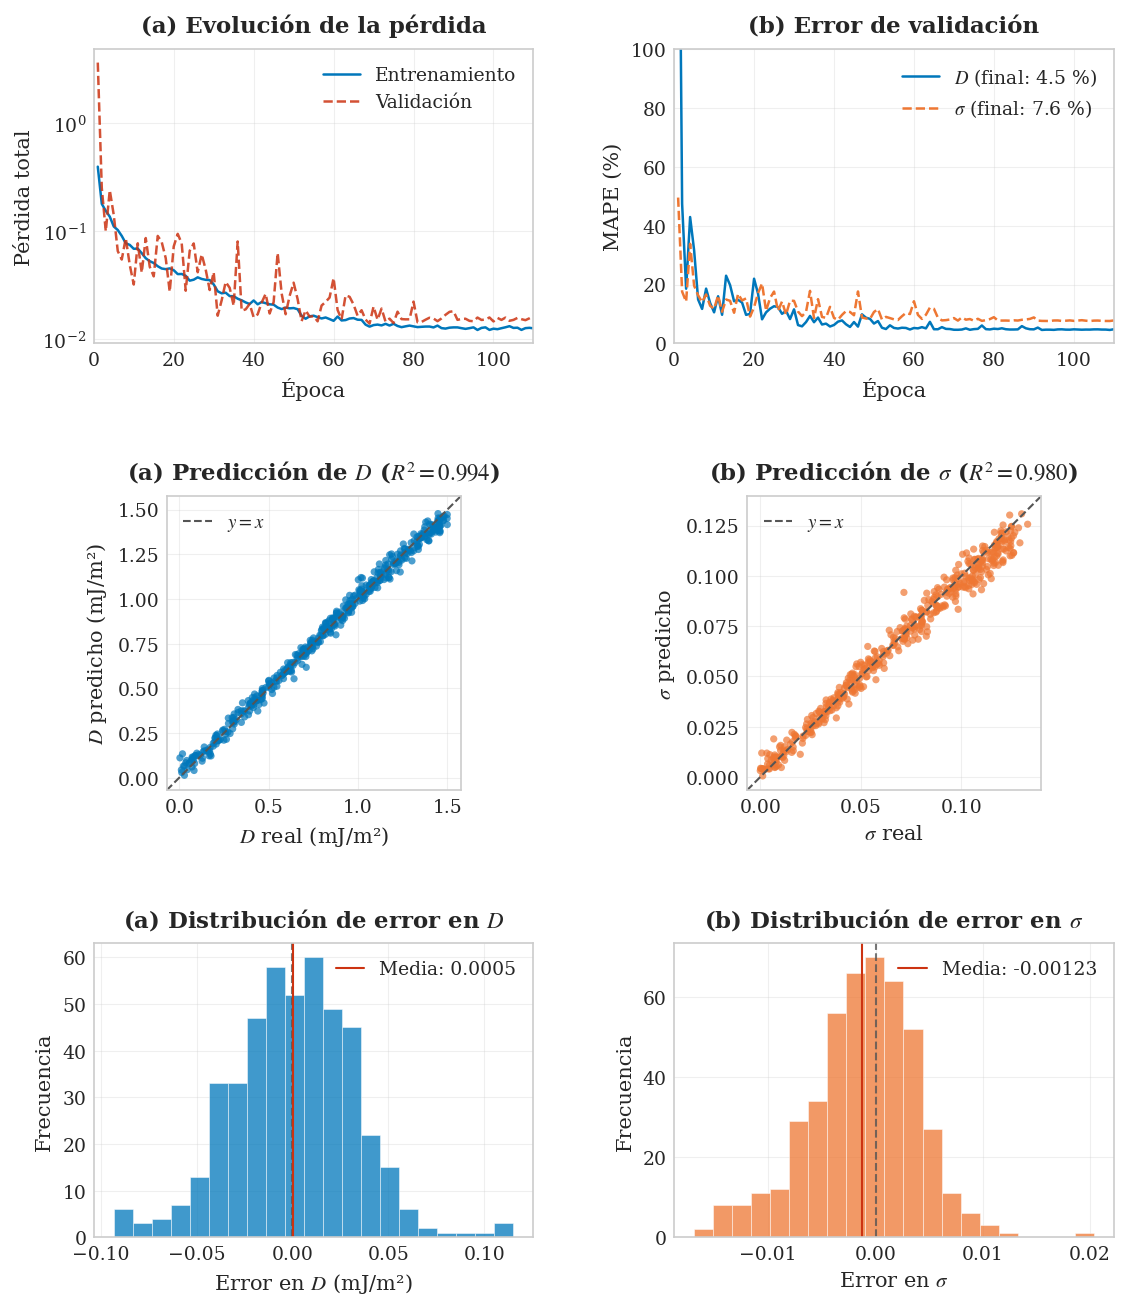


✓ Figures saved:
   PNG: outputs_ablation_final/physics_guided_spectral0.8_nonfiltered/figures/results_physics_guided_spectral0.8_nonfiltered.png
   PDF: outputs_ablation_final/physics_guided_spectral0.8_nonfiltered/figures/results_physics_guided_spectral0.8_nonfiltered.pdf

TABLA LATEX PARA EL DOCUMENTO

\begin{table}[htbp]
\centering
\caption{Métricas de desempeño del modelo Physics-Guided CNN en el conjunto de validación 
          ($n = 461$ muestras).}
\label{tab:metrics}
\begin{tabular}{lcc}
\toprule
Métrica & $D$ (DMI) & $\sigma$ (Dispersión de anisotropía) \\
\midrule
$R^2$ & 0.994 & 0.980 \\
MAPE (\%) & 4.8 & 7.8 \\
MAE & 0.0252 mJ/m² & 0.00398 \\
Sesgo (media del error) & 0.0005 mJ/m² & -0.00123 \\
\bottomrule
\end{tabular}
\end{table}



In [341]:
# ==============================================================================
# CELL 13: VISUALIZATION (UPDATED)
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from pathlib import Path

# =============================================================================
# 1. SAVE TRAINING HISTORY TO CSV (UPDATED)
# =============================================================================
history_df = pd.DataFrame({
    'epoch': np.arange(1, len(history['train_loss_total']) + 1),
    'train_loss_total': history['train_loss_total'],
    'train_loss_reg': history['train_loss_reg'],
    'train_loss_spectral_sigma': history['train_loss_spectral_sigma'],    # UPDATED
    'train_loss_mz_var_sigma': history['train_loss_mz_var_sigma'],        # NEW
    'val_loss_total': history['val_loss_total'],
    'val_loss_reg': history['val_loss_reg'],
    'val_loss_spectral_sigma': history['val_loss_spectral_sigma'],        # UPDATED
    'val_loss_mz_var_sigma': history['val_loss_mz_var_sigma'],            # NEW
    'val_mape_D': history['val_mape_D'],
    'val_mape_sigma': history['val_mape_sigma'],
    'lr': history['lr'],
    'weight_spectral_sigma': history['weight_spectral_sigma'],            # UPDATED
    'weight_mz_var_sigma': history['weight_mz_var_sigma'],                # NEW
})

csv_path = FIG_DIR / f"training_history_{RUN_TAG}.csv"
history_df.to_csv(csv_path, index=False)
print(f"✓ Training history saved to {csv_path}")

# =============================================================================
# 2. THESIS-READY STYLE CONFIGURATION
# =============================================================================

# Paleta de colores profesional
COLORS = {
    'train': '#0077BB',
    'val': '#CC3311',
    'D': '#0077BB',
    'sigma': '#EE7733',
    'regression': '#0077BB',
    'spectral_sigma': '#009988',    # UPDATED
    'mz_var_sigma': '#EE3377',      # NEW
    'reference': '#555555',
    'highlight': '#CC3311',
    'neutral': '#BBBBBB',
}

# Aplicar estilo (si tienes esta función definida)
# setup_thesis_style()

# =============================================================================
# 3. GET FINAL VALUES FROM HISTORY
# =============================================================================
final_mape_D = history['val_mape_D'][-1]
final_mape_sigma = history['val_mape_sigma'][-1]
final_val_loss = history['val_loss_total'][-1]

print(f"\nFinal metrics from training history:")
print(f"  MAPE D: {final_mape_D:.1f}%")
print(f"  MAPE σ: {final_mape_sigma:.1f}%")
print(f"  Val Loss: {final_val_loss:.4e}")

# =============================================================================
# 4. CREATE MAIN FIGURE
# =============================================================================

fig = plt.figure(figsize=(8.0, 8.9))
gs = fig.add_gridspec(3, 2, hspace=0.52, wspace=0.32,
                      left=0.10, right=0.95, top=0.95, bottom=0.06)

epochs = np.arange(1, len(history['train_loss_total']) + 1)

# -------------------------------------------------------------------------
# (a) Loss Evolution
# -------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

ax1.semilogy(epochs, history['train_loss_total'], 
             color=COLORS['train'], linewidth=1.2, label='Entrenamiento')
ax1.semilogy(epochs, history['val_loss_total'], 
             color=COLORS['val'], linewidth=1.2, linestyle='--', 
             alpha=0.85, label='Validación')

ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida total')
ax1.set_title('(a) Evolución de la pérdida', fontweight='semibold', pad=8)
ax1.legend(loc='upper right')
ax1.set_xlim([0, len(epochs)])

# -------------------------------------------------------------------------
# (b) Validation MAPE
# -------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])

val_D = mape_D
val_s = mape_sigma

ax2.plot(epochs, history['val_mape_D'], 
         color=COLORS['D'], linewidth=1.2,
         label=f'$D$ (final: 4.5 %)')
ax2.plot(epochs, history['val_mape_sigma'], 
         color=COLORS['sigma'], linewidth=1.2, linestyle='--',
         label=f'$\\sigma$ (final: 7.6 %)')

ax2.set_xlabel('Época')
ax2.set_ylabel('MAPE (%)')
ax2.set_title('(b) Error de validación', fontweight='semibold', pad=8)
ax2.legend(loc='upper right')
ax2.set_ylim(bottom=0, top=min(100, max(max(history['val_mape_D'][:30]), 
                                         max(history['val_mape_sigma'][:30])) * 1.1))
ax2.set_xlim([0, len(epochs)])

# -------------------------------------------------------------------------
# (c) D Prediction Scatter
# -------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])

D_plot = D_pred_val.numpy() * 1e3
D_true_plot = D_true_val.numpy() * 1e3

n_points = len(D_plot)
alpha = max(0.3, min(0.7, 500/n_points))

ax3.scatter(D_true_plot, D_plot, s=12, alpha=alpha, 
            c=COLORS['D'], edgecolors='none', rasterized=True)

d_min = min(D_true_plot.min(), D_plot.min())
d_max = max(D_true_plot.max(), D_plot.max())
d_margin = (d_max - d_min) * 0.05
d_lim = [d_min - d_margin, d_max + d_margin]

ax3.plot(d_lim, d_lim, '--', color=COLORS['reference'], 
         linewidth=1.0, label='$y = x$', zorder=1)

ax3.set_xlabel('$D$ real (mJ/m²)')
ax3.set_ylabel('$D$ predicho (mJ/m²)')
ax3.set_title(f'(a) Predicción de $D$ ($R^2 = {r2_D:.3f}$)', 
              fontweight='semibold', pad=8)
ax3.set_xlim(d_lim)
ax3.set_ylim(d_lim)
ax3.set_aspect('equal', adjustable='box')
ax3.legend(loc='upper left', handlelength=1.5)

# -------------------------------------------------------------------------
# (d) σ Prediction Scatter
# -------------------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])

s_plot = s_pred_val.numpy()
s_true_plot = s_true_val.numpy()

ax4.scatter(s_true_plot, s_plot, s=12, alpha=alpha,
            c=COLORS['sigma'], edgecolors='none', rasterized=True)

s_min = min(s_true_plot.min(), s_plot.min())
s_max = max(s_true_plot.max(), s_plot.max())
s_margin = (s_max - s_min) * 0.05
s_lim = [s_min - s_margin, s_max + s_margin]

ax4.plot(s_lim, s_lim, '--', color=COLORS['reference'], 
         linewidth=1.0, label='$y = x$', zorder=1)

ax4.set_xlabel('$\\sigma$ real')
ax4.set_ylabel('$\\sigma$ predicho')
ax4.set_title(f'(b) Predicción de $\\sigma$ ($R^2 = {r2_s:.3f}$)', 
              fontweight='semibold', pad=8)
ax4.set_xlim(s_lim)
ax4.set_ylim(s_lim)
ax4.set_aspect('equal', adjustable='box')
ax4.legend(loc='upper left', handlelength=1.5)

# -------------------------------------------------------------------------
# (e) D Error Distribution
# -------------------------------------------------------------------------


ax5 = fig.add_subplot(gs[2, 0])

D_error = (D_pred_val - D_true_val).numpy() * 1e3
mae_D = np.mean(np.abs(D_error))
mae_rel_D = mae_D / D_true.mean() * 100  # En porcentaje
mean_D_error = np.mean(D_error)

n_bins = min(30, max(15, int(np.sqrt(len(D_error)))))
ax5.hist(D_error, bins=n_bins, alpha=0.75, color=COLORS['D'], 
         edgecolor='white', linewidth=0.3)

ax5.axvline(0, color=COLORS['reference'], linestyle='--', 
            linewidth=1.0, alpha=0.8)
ax5.axvline(mean_D_error, color=COLORS['highlight'], linestyle='-', 
            linewidth=1.0, label=f'Media: {mean_D_error:.4f}')

ax5.set_xlabel('Error en $D$ (mJ/m²)')
ax5.set_ylabel('Frecuencia')
ax5.set_title(f'(a) Distribución de error en $D$', 
              fontweight='semibold', pad=8)
ax5.legend(loc='upper right', handlelength=1.5)

# -------------------------------------------------------------------------
# (f) σ Error Distribution
# -------------------------------------------------------------------------
ax6 = fig.add_subplot(gs[2, 1])

s_error = (s_pred_val - s_true_val).numpy()
mae_s = np.mean(np.abs(s_error))
mae_rel_s = mae_s / s_true.mean() * 100
mean_s_error = np.mean(s_error)

ax6.hist(s_error, bins=n_bins, alpha=0.75, color=COLORS['sigma'],
         edgecolor='white', linewidth=0.3)

ax6.axvline(0, color=COLORS['reference'], linestyle='--', 
            linewidth=1.0, alpha=0.8)
ax6.axvline(mean_s_error, color=COLORS['highlight'], linestyle='-', 
            linewidth=1.0, label=f'Media: {mean_s_error:.5f}')

ax6.set_xlabel('Error en $\\sigma$')
ax6.set_ylabel('Frecuencia')
ax6.set_title(f'(b) Distribución de error en $\\sigma$', 
              fontweight='semibold', pad=8)
ax6.legend(loc='upper right', handlelength=1.5)

# =============================================================================
# 5. SAVE FIGURE
# =============================================================================
fig_path = FIG_DIR / f"results_{RUN_TAG}.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')

pdf_path = FIG_DIR / f"results_{RUN_TAG}.pdf"
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')

plt.show()

print(f"\n✓ Figures saved:")
print(f"   PNG: {fig_path}")
print(f"   PDF: {pdf_path}")

# =============================================================================
# 6. LATEX TABLE (UPDATED - Physics-Guided CNN, not PINN)
# =============================================================================
print("\n" + "="*60)
print("TABLA LATEX PARA EL DOCUMENTO")
print("="*60)
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Métricas de desempeño del modelo Physics-Guided CNN en el conjunto de validación 
          ($n = {len(D_plot)}$ muestras).}}
\\label{{tab:metrics}}
\\begin{{tabular}}{{lcc}}
\\toprule
Métrica & $D$ (DMI) & $\\sigma$ (Dispersión de anisotropía) \\\\
\\midrule
$R^2$ & {r2_D:.3f} & {r2_s:.3f} \\\\
MAPE (\\%) & {final_mape_D:.1f} & {final_mape_sigma:.1f} \\\\
MAE & {mae_D:.4f} mJ/m² & {mae_s:.5f} \\\\
Sesgo (media del error) & {mean_D_error:.4f} mJ/m² & {mean_s_error:.5f} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

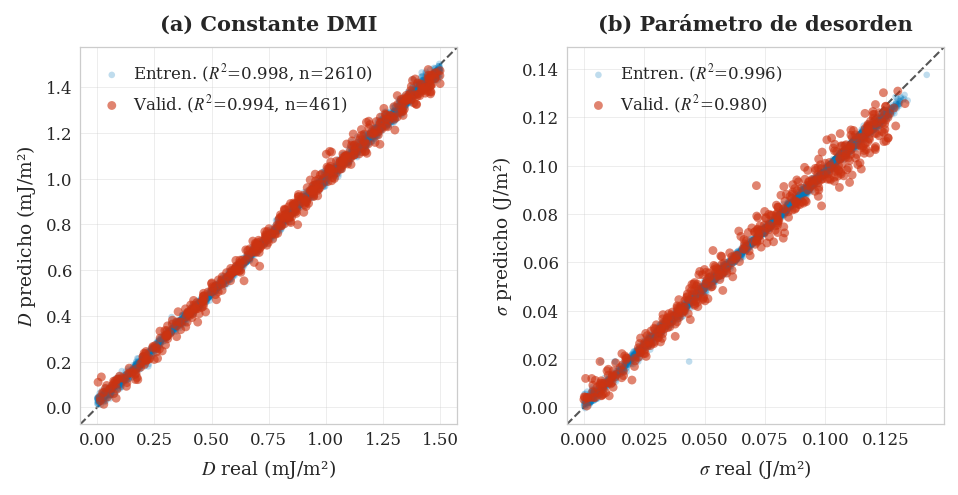


✓ Figura guardada:
   PNG: outputs_ablation_final/physics_guided_spectral0.8_nonfiltered/figures/train_vs_val_physics_guided_spectral0.8_nonfiltered.png
   PDF: outputs_ablation_final/physics_guided_spectral0.8_nonfiltered/figures/train_vs_val_physics_guided_spectral0.8_nonfiltered.pdf

COMPARACIÓN ENTRENAMIENTO VS VALIDACIÓN
Métrica              Entrenamiento     Validación       
-------------------------------------------------------
R² (D)               0.9984            0.9940           
R² (σ)               0.9958            0.9804           
n muestras           2610              461              

\begin{table}[htbp]
\centering
\caption{Comparación del desempeño en conjuntos de entrenamiento y validación.}
\label{tab:train_val_comparison}
\begin{tabular}{lccc}
\toprule
Parámetro & Conjunto & $R^2$ & $n$ \\
\midrule
\multirow{2}{*}{$D$ (DMI)} 
    & Entrenamiento & 0.998 & 2610 \\
    & Validación & 0.994 & 461 \\
\midrule
\multirow{2}{*}{$\sigma$ (Desorden)} 
    & Entrenamien

In [342]:
# ==============================================================================
# TRAIN VS VAL SCATTER PLOTS (Thesis-ready style)
# ==============================================================================

model.eval()
train_preds, train_targets = [], []
val_preds, val_targets = [], []
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#
#BEST_PATH = CHECKPOINT_DIR / f"best_model_{RUN_TAG}.pt"
#checkpoint = torch.load(BEST_PATH, map_location=device, weights_only=False)
# 
# 
#
## Cargar modelo
#model = PhysicsGuidedCNN()  # Asegúrate de tener la clase definida
#model.load_state_dict(checkpoint['model_state_dict'])
#model.to(device)
#model.eval()
#
## Cargar estadísticas de normalización
#t_mean_t = torch.tensor(checkpoint['target_mean'])
#t_std_t = torch.tensor(checkpoint['target_std'])
#
#print(f"✓ Modelo cargado desde: {BEST_PATH}")
#print(f"  Época: {checkpoint['epoch']}")
#print(f"  Val loss: {checkpoint['val_loss']:.6f}")
#print(f"  Loss weights: {checkpoint['loss_weights']}")


with torch.no_grad():
    # CORREGIDO: 5 elementos
    for imgs, m_fields, Ku_blocks, targets, run_ids in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds_unnorm = outputs.cpu() * t_std_t.cpu() + t_mean_t.cpu()
        targets_unnorm = targets * t_std_t.cpu() + t_mean_t.cpu()
        train_preds.append(preds_unnorm)
        train_targets.append(targets_unnorm)
    
    # CORREGIDO: 5 elementos
    for imgs, m_fields, Ku_blocks, targets, run_ids in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds_unnorm = outputs.cpu() * t_std_t.cpu() + t_mean_t.cpu()
        targets_unnorm = targets * t_std_t.cpu() + t_mean_t.cpu()
        val_preds.append(preds_unnorm)
        val_targets.append(targets_unnorm)

train_preds = torch.cat(train_preds).numpy()
train_targets = torch.cat(train_targets).numpy()
val_preds = torch.cat(val_preds).numpy()
val_targets = torch.cat(val_targets).numpy()

# =============================================================================
# Compute R² for each split
# =============================================================================
def compute_r2(pred, true):
    ss_res = np.sum((true - pred)**2)
    ss_tot = np.sum((true - np.mean(true))**2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0

r2_D_train = compute_r2(train_preds[:, 0], train_targets[:, 0])
r2_D_val = compute_r2(val_preds[:, 0], val_targets[:, 0])
r2_s_train = compute_r2(train_preds[:, 1], train_targets[:, 1])
r2_s_val = compute_r2(val_preds[:, 1], val_targets[:, 1])

# =============================================================================
# Thesis-ready style (consistent with main results figure)
# =============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.4,
    'lines.linewidth': 1.2,
})

# Colores consistentes con figura principal
COLORS = {
    'train': '#0077BB',      # Azul - entrenamiento
    'val': '#CC3311',        # Rojo - validación
    'reference': '#555555',  # Gris - línea y=x
}

# =============================================================================
# Create figure
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.2))

# Preparar datos
D_train_true = train_targets[:, 0] * 1e3  # a mJ/m²
D_train_pred = train_preds[:, 0] * 1e3
D_val_true = val_targets[:, 0] * 1e3
D_val_pred = val_preds[:, 0] * 1e3

s_train_true = train_targets[:, 1]
s_train_pred = train_preds[:, 1]
s_val_true = val_targets[:, 1]
s_val_pred = val_preds[:, 1]

n_train = len(train_preds)
n_val = len(val_preds)

# -------------------------------------------------------------------------
# (a) D prediction
# -------------------------------------------------------------------------
ax = axes[0]

# Training data (fondo, más transparente)
ax.scatter(D_train_true, D_train_pred, 
           s=10, alpha=0.25, c=COLORS['train'], edgecolors='none',
           label=f'Entren. ($R^2$={r2_D_train:.3f}, n={n_train})',
           rasterized=True)

# Validation data (frente, más visible)
ax.scatter(D_val_true, D_val_pred, 
           s=18, alpha=0.6, c=COLORS['val'], edgecolors='none',
           label=f'Valid. ($R^2$={r2_D_val:.3f}, n={n_val})',
           rasterized=True)

# Línea de predicción perfecta
d_min = min(D_train_true.min(), D_val_true.min())
d_max = max(D_train_true.max(), D_val_true.max())
d_margin = (d_max - d_min) * 0.05
d_lim = [d_min - d_margin, d_max + d_margin]

ax.plot(d_lim, d_lim, '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

ax.set_xlabel('$D$ real (mJ/m²)')
ax.set_ylabel('$D$ predicho (mJ/m²)')
ax.set_title('(a) Constante DMI', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8',
          handletextpad=0.3, borderpad=0.4)
ax.set_xlim(d_lim)
ax.set_ylim(d_lim)
ax.set_aspect('equal', adjustable='box')

# -------------------------------------------------------------------------
# (b) σ prediction
# -------------------------------------------------------------------------
ax = axes[1]

# Training data
ax.scatter(s_train_true, s_train_pred,
           s=10, alpha=0.25, c=COLORS['train'], edgecolors='none',
           label=f'Entren. ($R^2$={r2_s_train:.3f})',
           rasterized=True)

# Validation data
ax.scatter(s_val_true, s_val_pred,
           s=18, alpha=0.6, c=COLORS['val'], edgecolors='none',
           label=f'Valid. ($R^2$={r2_s_val:.3f})',
           rasterized=True)

# Línea de predicción perfecta
s_min = min(s_train_true.min(), s_val_true.min())
s_max = max(s_train_true.max(), s_val_true.max())
s_margin = (s_max - s_min) * 0.05
s_lim = [s_min - s_margin, s_max + s_margin]

ax.plot(s_lim, s_lim, '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

ax.set_xlabel('$\\sigma$ real (J/m²)')
ax.set_ylabel('$\\sigma$ predicho (J/m²)')
ax.set_title('(b) Parámetro de desorden', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8',
          handletextpad=0.3, borderpad=0.4)
ax.set_xlim(s_lim)
ax.set_ylim(s_lim)
ax.set_aspect('equal', adjustable='box')

# =============================================================================
# Save
# =============================================================================
plt.tight_layout(w_pad=1.5)

fig_path = FIG_DIR / f"train_vs_val_{RUN_TAG}.png"
pdf_path = FIG_DIR / f"train_vs_val_{RUN_TAG}.pdf"

plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Figura guardada:")
print(f"   PNG: {fig_path}")
print(f"   PDF: {pdf_path}")

# =============================================================================
# Summary table
# =============================================================================
print(f"\n{'='*55}")
print(f"COMPARACIÓN ENTRENAMIENTO VS VALIDACIÓN")
print(f"{'='*55}")
print(f"{'Métrica':<20} {'Entrenamiento':<17} {'Validación':<17}")
print(f"{'-'*55}")
print(f"{'R² (D)':<20} {r2_D_train:<17.4f} {r2_D_val:<17.4f}")
print(f"{'R² (σ)':<20} {r2_s_train:<17.4f} {r2_s_val:<17.4f}")
print(f"{'n muestras':<20} {n_train:<17} {n_val:<17}")
print(f"{'='*55}")

# LaTeX table
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Comparación del desempeño en conjuntos de entrenamiento y validación.}}
\\label{{tab:train_val_comparison}}
\\begin{{tabular}}{{lccc}}
\\toprule
Parámetro & Conjunto & $R^2$ & $n$ \\\\
\\midrule
\\multirow{{2}}{{*}}{{$D$ (DMI)}} 
    & Entrenamiento & {r2_D_train:.3f} & {n_train} \\\\
    & Validación & {r2_D_val:.3f} & {n_val} \\\\
\\midrule
\\multirow{{2}}{{*}}{{$\\sigma$ (Desorden)}} 
    & Entrenamiento & {r2_s_train:.3f} & {n_train} \\\\
    & Validación & {r2_s_val:.3f} & {n_val} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

In [155]:
# ==============================================================================
# GRADIENT CONFLICT VISUALIZATION (Thesis-ready)
# ==============================================================================

if gradient_tracker and len(gradient_tracker.history['grad_norm_reg']) > 0:
    
    # =========================================================================
    # Style setup (consistent with other figures)
    # =========================================================================
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
        'mathtext.fontset': 'stix',
        'font.size': 9,
        'axes.titlesize': 10,
        'axes.labelsize': 9,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'axes.linewidth': 0.6,
        'grid.linewidth': 0.4,
        'grid.alpha': 0.4,
    })
    
    # Colors (consistent palette)
    COLORS = {
        'regression': '#0077BB',   # Azul
        'spectral': '#009988',     # Verde azulado
        'combined': '#7B3294',     # Púrpura
        'reference': '#555555',    # Gris
        'aligned': '#009988',      # Verde (mismo que spectral)
        'conflict': '#CC3311',     # Rojo
    }
    
    # =========================================================================
    # Prepare data
    # =========================================================================
    steps = np.arange(len(gradient_tracker.history['grad_norm_reg']))
    summary = gradient_tracker.get_summary()
    
    # Convert steps to epochs (approximate)
    steps_per_epoch = len(train_loader) // GRAD_TRACK_INTERVAL
    epochs_approx = steps / max(steps_per_epoch, 1)
    
    # =========================================================================
    # Create figure
    # =========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(6.5, 5.5))
    
    # -------------------------------------------------------------------------
    # (a) Gradient Magnitudes
    # -------------------------------------------------------------------------
    ax = axes[0, 0]
    
    ax.semilogy(epochs_approx, gradient_tracker.history['grad_norm_reg'], 
                label=r'Regresión $\mathcal{L}_{\mathrm{reg}}$', 
                color=COLORS['regression'], alpha=0.8, linewidth=1.0)
    ax.semilogy(epochs_approx, gradient_tracker.history['grad_norm_spectral'], 
                label=r'Espectral $\mathcal{L}_{\mathrm{spec}}$', 
                color=COLORS['spectral'], alpha=0.8, linewidth=1.0)
    
    ax.set_xlabel('Época (aprox.)')
    ax.set_ylabel(r'$\|\nabla \mathcal{L}\|$')
    ax.set_title('(a) Magnitud de gradientes', fontweight='semibold', pad=8)
    ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8')
    ax.set_xlim([0, epochs_approx.max()])
    
    # -------------------------------------------------------------------------
    # (b) Gradient Alignment Over Time - FIXED LEGEND ISSUE
    # -------------------------------------------------------------------------
    ax = axes[0, 1]
    
    cosine_data = np.array(gradient_tracker.history['cosine_reg_spectral'])
    
    # Background zones (sin leyenda - usaremos texto)
    ax.fill_between([0, epochs_approx.max()], 0, 1, 
                    alpha=0.12, color=COLORS['aligned'], zorder=0)
    ax.fill_between([0, epochs_approx.max()], -1, 0, 
                    alpha=0.12, color=COLORS['conflict'], zorder=0)
    
    # Texto con fondo para mejor contraste
    ax.text(epochs_approx.max() * 0.97, 0.82, 'Alineados', 
            fontsize=8, color='#006666', fontweight='bold',
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      alpha=0.7, edgecolor='none'))
    
    ax.text(epochs_approx.max() * 0.97, -0.82, 'En conflicto', 
            fontsize=8, color='#AA2200', fontweight='bold',
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      alpha=0.7, edgecolor='none'))
    
    # Raw data (muy transparente, de fondo)
    ax.plot(epochs_approx, cosine_data, color=COLORS['spectral'], 
            alpha=0.25, linewidth=0.5, zorder=1)
    
    # Smoothed curve
    window = min(20, len(steps) // 10) if len(steps) > 20 else 1
    if window > 1:
        cosine_smooth = np.convolve(cosine_data, np.ones(window)/window, mode='valid')
        epochs_smooth = epochs_approx[:len(cosine_smooth)]
        ax.plot(epochs_smooth, cosine_smooth, color=COLORS['spectral'], 
                linewidth=1.5, label='Suavizado', zorder=2)
    
    # Reference line
    ax.axhline(0, color=COLORS['reference'], linestyle='--', linewidth=0.8, zorder=1)
    
    ax.set_xlabel('Época (aprox.)')
    ax.set_ylabel('Similitud coseno')
    ax.set_title(r'(b) Alineación $\nabla\mathcal{L}_{\mathrm{reg}}$ ↔ $\nabla\mathcal{L}_{\mathrm{spec}}$', 
                 fontweight='semibold', pad=8)
    ax.set_ylim(-1.05, 1.05)
    ax.set_xlim([0, epochs_approx.max()])
    
    # Leyenda compacta solo para la curva
    ax.legend(loc='lower left', framealpha=0.95, edgecolor='0.8')
    
    # -------------------------------------------------------------------------
    # (c) Combined Gradient Norm
    # -------------------------------------------------------------------------
    ax = axes[1, 0]
    
    ax.semilogy(epochs_approx, gradient_tracker.history['grad_norm_combined'], 
                color=COLORS['combined'], alpha=0.8, linewidth=1.0)
    
    ax.set_xlabel('Época (aprox.)')
    ax.set_ylabel(r'$\|\nabla \mathcal{L}_{\mathrm{total}}\|$')
    ax.set_title('(c) Magnitud del gradiente efectivo', fontweight='semibold', pad=8)
    ax.set_xlim([0, epochs_approx.max()])
    
    # Warmup line
    if USE_ANNEALING:
        ax.axvline(WARMUP_EPOCHS, color=COLORS['reference'], linestyle=':', 
                   linewidth=1.0, label=f'Fin warmup (época {WARMUP_EPOCHS})')
        ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8')
    
    # -------------------------------------------------------------------------
    # (d) Alignment Distribution
    # -------------------------------------------------------------------------
    ax = axes[1, 1]
    
    cosine_vals = np.array(gradient_tracker.history['cosine_reg_spectral'])
    conflict_rate = summary.get('conflict_rate_reg_spectral', 0) * 100
    mean_cosine = np.mean(cosine_vals)
    
    # Histogram con colores por región
    bins = np.linspace(-1, 1, 31)
    n_neg, _, _ = ax.hist(cosine_vals[cosine_vals < 0], bins=bins[bins <= 0], 
                          alpha=0.7, color=COLORS['conflict'],
                          edgecolor='white', linewidth=0.3, label='Conflicto')
    n_pos, _, _ = ax.hist(cosine_vals[cosine_vals >= 0], bins=bins[bins >= 0], 
                          alpha=0.7, color=COLORS['aligned'],
                          edgecolor='white', linewidth=0.3, label='Alineado')
    
    # Reference lines
    ax.axvline(0, color=COLORS['reference'], linestyle='--', linewidth=1.0)
    ax.axvline(mean_cosine, color='black', linestyle='-', linewidth=1.2,
               label=f'Media: {mean_cosine:.3f}')
    
    ax.set_xlabel('Similitud coseno')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'(d) Distribución de alineación \n (conflicto: {conflict_rate:.1f}%)', 
                 fontweight='semibold', pad=8)
    ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8',
              fontsize=7, handlelength=1.2)
    ax.set_xlim([-1.1, 1.1])
    
    # =========================================================================
    # Final adjustments and save
    # =========================================================================
    plt.tight_layout(h_pad=1.8, w_pad=1.2)
    
    fig_path = FIG_DIR / f"gradient_analysis_{RUN_TAG}.png"
    pdf_path = FIG_DIR / f"gradient_analysis_{RUN_TAG}.pdf"
    
    plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
    plt.show()
    
    # =========================================================================
    # Print summary
    # =========================================================================
    print(f"\n✓ Análisis de gradientes guardado:")
    print(f"   PNG: {fig_path}")
    print(f"   PDF: {pdf_path}")
    
    print(f"\n{'='*60}")
    print(f"RESUMEN DE CONFLICTO DE GRADIENTES")
    print(f"{'='*60}")
    print(f"{'Métrica':<45} {'Valor':<15}")
    print(f"{'-'*60}")
    print(f"{'Muestras de gradiente totales':<45} {len(steps):<15}")
    print(f"{'Similitud coseno media (Reg ↔ Spec)':<45} {mean_cosine:<15.4f}")
    print(f"{'Tasa de conflicto (coseno < 0)':<45} {conflict_rate:<14.1f}%")
    print(f"{'='*60}")
    
    # LaTeX table
    print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Análisis de conflicto entre gradientes de los componentes de la función de pérdida.}}
\\label{{tab:gradient_conflict}}
\\begin{{tabular}}{{lc}}
\\toprule
Métrica & Valor \\\\
\\midrule
Similitud coseno media & {mean_cosine:.3f} \\\\
Tasa de conflicto (\\%) & {conflict_rate:.1f} \\\\
Muestras totales & {len(steps)} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

else:
    print("⚠️ No hay datos de seguimiento de gradientes disponibles.")

NameError: name 'gradient_tracker' is not defined

In [16]:
# ==============================================================================
# CELL 15: OOD EVALUATION - CONFIGURATION
# ==============================================================================
# Run this AFTER training, or in a new session to load saved model

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------------------------------
# OOD Data Paths (MODIFY THESE!)
# -------------------------------------------------
OOD_CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_outside_clamp/training_index.csv")  # <-- CHANGE THIS
OOD_IMG_DIR = Path("../images/mumax_dataset_ku_by_block_disorder_phy_outside_clamp_both_above")               # <-- CHANGE THIS
OOD_NPY_DIR = Path("../mumax_dataset_ku_by_block_disorder_phy_outside_clamp_both_above")            # <-- CHANGE THIS (if using energy validation)

RUN_TAG = "improved_pinn_0.5_physics"
FIG_DIR = Path("./outputs_ablation_final/physics_guided_mzvar0.4_spectral0.8_annealing_nonfiltered/figures")


# Model checkpoint to load
#MODEL_CHECKPOINT = BEST_PATH  # Uses the path from training, or set manually:
MODEL_CHECKPOINT = Path("./outputs_ablation_final/physics_guided_mzvar0.4_spectral0.8_annealing_nonfiltered/checkpoints/best_physics_guided_mzvar0.4_spectral0.8_annealing_nonfiltered.pt")

# Do we need NPY files for OOD? (Set False if you only have images)
OOD_LOAD_NPY = True  # Usually False for quick evaluation

# Training ranges (for distance calculation)
TRAIN_D_MIN, TRAIN_D_MAX = ID_D_RANGE  # From config: (0.3e-3, 1.5e-3)
TRAIN_SIGMA_MIN, TRAIN_SIGMA_MAX = ID_SIGMA_RANGE  # From config: (0.02, 0.15)

print(f"OOD Evaluation Configuration:")
print(f"  OOD CSV: {OOD_CSV_PATH}")
print(f"  OOD Images: {OOD_IMG_DIR}")
print(f"  Model: {MODEL_CHECKPOINT}")
print(f"  Training D range: [{TRAIN_D_MIN*1e3:.2f}, {TRAIN_D_MAX*1e3:.2f}] mJ/m²")
print(f"  Training σ range: [{TRAIN_SIGMA_MIN:.2f}, {TRAIN_SIGMA_MAX:.2f}]")


OOD Evaluation Configuration:
  OOD CSV: ../mumax_dataset_ku_by_block_disorder_phy_outside_clamp/training_index.csv
  OOD Images: ../images/mumax_dataset_ku_by_block_disorder_phy_outside_clamp_both_above
  Model: outputs_ablation_final/physics_guided_mzvar0.4_spectral0.8_annealing_nonfiltered/checkpoints/best_physics_guided_mzvar0.4_spectral0.8_annealing_nonfiltered.pt
  Training D range: [0.30, 1.50] mJ/m²
  Training σ range: [0.02, 0.15]


In [17]:

# ==============================================================================
# CELL 16: LOAD MODEL FROM CHECKPOINT
# ==============================================================================

# Load checkpoint

checkpoint = torch.load(MODEL_CHECKPOINT, map_location=device, weights_only=False)

# Recreate model (must match architecture!)
model_ood = PhysicsGuidedCNN().to(device)
model_ood.load_state_dict(checkpoint['model_state_dict'])
model_ood.eval()

# Get normalization parameters
ood_t_mean = checkpoint['target_mean']
ood_t_std = checkpoint['target_std']
ood_t_mean_t = torch.tensor(ood_t_mean, device=device, dtype=torch.float32)
ood_t_std_t = torch.tensor(ood_t_std, device=device, dtype=torch.float32)

print(f"✓ Model loaded from epoch {checkpoint['epoch']}")
print(f"  Validation loss at save: {checkpoint['val_loss']:.4e}")
print(f"  Target normalization: mean=[{ood_t_mean[0]*1e3:.3f} mJ/m², {ood_t_mean[1]:.4f}]")
print(f"                        std=[{ood_t_std[0]*1e3:.3f}, {ood_t_std[1]:.4f}]")


✓ Model loaded from epoch 75
  Validation loss at save: 1.4217e-02
  Target normalization: mean=[0.782 mJ/m², 0.0709]
                        std=[0.425, 0.0353]


In [18]:
# ==============================================================================
# CELL 16.5: RECONSTRUCT TRAINING RANGES FROM ORIGINAL SPLIT
# ==============================================================================

# Recreate dataset with same seed to get exact training ranges
_temp_dataset = MzDataset(
    csv_path=CSV_PATH,
    img_dir=IMG_DIR,
    npy_dir=NPY_DIR,
    index_col=IMG_INDEX_COL,
    transform=None,
    load_npy=False,  # Solo necesitamos los targets, no los NPY
    max_samples=None,
    random_subset_seed=RANDOM_SEED,
    filter_low_D=False,
    filter_low_sigma=False
)

# Mismo split que en entrenamiento
_val_size = int(len(_temp_dataset) * VAL_RATIO)
_train_size = len(_temp_dataset) - _val_size

_generator = torch.Generator().manual_seed(RANDOM_SEED)
_train_dataset, _ = random_split(_temp_dataset, [_train_size, _val_size], generator=_generator)

# Extraer rangos del conjunto de entrenamiento
_train_targets = np.array(
    [[_temp_dataset.records[i]["D"], _temp_dataset.records[i]["sigma"]]
     for i in _train_dataset.indices],
    dtype=np.float32
)

TRAIN_D_MIN = _train_targets[:, 0].min()
TRAIN_D_MAX = _train_targets[:, 0].max()
TRAIN_SIGMA_MIN = _train_targets[:, 1].min()
TRAIN_SIGMA_MAX = _train_targets[:, 1].max()

# Guardar también los valores completos por si los necesitas para gráficas
D_true_train = _train_targets[:, 0]
s_true_train = _train_targets[:, 1]

# Limpiar memoria
del _temp_dataset, _train_dataset, _train_targets, _generator

print(f"✓ Rangos de entrenamiento reconstruidos:")
print(f"  D ∈ [{TRAIN_D_MIN*1e3:.3f}, {TRAIN_D_MAX*1e3:.3f}] mJ/m²")
print(f"  σ ∈ [{TRAIN_SIGMA_MIN:.4f}, {TRAIN_SIGMA_MAX:.4f}]")
print(f"  (n_train = {len(D_true_train)} muestras)")

[MzDataset] Loaded 3074 samples from ../images/corrected_3
  D range: [0.00, 1.50] mJ/m²
  σ range: [0.000, 0.142]
✓ Rangos de entrenamiento reconstruidos:
  D ∈ [0.000, 1.499] mJ/m²
  σ ∈ [0.0001, 0.1419]
  (n_train = 2613 muestras)


In [19]:

# ==============================================================================
# CELL 17: OOD DATASET CLASS (Simplified - no NPY needed)
# ==============================================================================

class OODDataset(Dataset):
    """
    Simple dataset for OOD evaluation.
    Only loads images, no NPY files needed.
    """
    
    def __init__(self, csv_path, img_dir, index_col='run_id',
                 col_D='Dind', col_sigma='sigma_nominal',
                 img_prefix='mz_binary_', img_ext='.png',
                 target_mean=None, target_std=None):
        
        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)
        
        self.img_dir = Path(img_dir)
        self.col_D = col_D
        self.col_sigma = col_sigma
        print(col_sigma)
        
        self.target_mean = target_mean
        self.target_std = target_std
        
        self.records = []
        
        # Find all images
        img_files = sorted(self.img_dir.glob(f"{img_prefix}*{img_ext}"))
        
        for img_path in img_files:
            try:
                run_id = int(img_path.stem.replace(img_prefix, ""))
            except ValueError:
                continue
            
            if run_id not in self.df.index:
                continue
            
            row = self.df.loc[run_id]
            D = float(row[col_D])
            sigma = float(row[col_sigma])
            
            self.records.append({
                'img_path': img_path,
                'D': D,
                'sigma': sigma,
                'run_id': run_id
            })
        
        print(f"[OODDataset] Loaded {len(self.records)} samples")
        
        if len(self.records) > 0:
            D_vals = [r['D'] for r in self.records]
            s_vals = [r['sigma'] for r in self.records]
            print(f"  D range: [{min(D_vals)*1e3:.2f}, {max(D_vals)*1e3:.2f}] mJ/m²")
            print(f"  σ range: [{min(s_vals):.3f}, {max(s_vals):.3f}]")
    
    def __len__(self):
        return len(self.records)
    
    def __getitem__(self, idx):
        r = self.records[idx]
        
        # Load image
        arr = load_16bit_image(r['img_path'])
        img = torch.from_numpy(arr).unsqueeze(0).float()
        img = img.repeat(3, 1, 1)  # Expand to 3 channels
        
        # Target (normalized)
        target = np.array([r['D'], r['sigma']], dtype=np.float32)
        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std
        target = torch.tensor(target, dtype=torch.float32)
        
        # Also return raw values for analysis
        raw_target = torch.tensor([r['D'], r['sigma']], dtype=torch.float32)
        
        return img, target, raw_target, r['run_id']



In [20]:
# Cell 15.5 (nueva celda) - Obtener rangos de entrenamiento
# Recrear el dataset con la misma semilla para obtener los rangos exactos

_temp_dataset = MzDataset(
    csv_path=CSV_PATH,  # El CSV de entrenamiento original
    img_dir=IMG_DIR,
    npy_dir=NPY_DIR,
    index_col=IMG_INDEX_COL,
    transform=None,
    load_npy=False,  # No necesitamos cargar NPY, solo los targets
    max_samples=None,
    random_subset_seed=RANDOM_SEED,
    filter_low_D=False,
    filter_low_sigma=False
)

# Mismo split que en entrenamiento
_val_size = int(len(_temp_dataset) * VAL_RATIO)
_train_size = len(_temp_dataset) - _val_size

_generator = torch.Generator().manual_seed(RANDOM_SEED)
_train_dataset, _ = random_split(_temp_dataset, [_train_size, _val_size], generator=_generator)

# Extraer rangos
_train_targets = np.array(
    [[_temp_dataset.records[i]["D"], _temp_dataset.records[i]["sigma"]]
     for i in _train_dataset.indices],
    dtype=np.float32
)

TRAIN_D_MIN = _train_targets[:, 0].min()
TRAIN_D_MAX = _train_targets[:, 0].max()
TRAIN_SIGMA_MIN = _train_targets[:, 1].min()
TRAIN_SIGMA_MAX = _train_targets[:, 1].max()

# Limpiar memoria
del _temp_dataset, _train_dataset, _train_targets, _generator

print(f"Rangos de entrenamiento (reconstruidos):")
print(f"  D ∈ [{TRAIN_D_MIN*1e3:.3f}, {TRAIN_D_MAX*1e3:.3f}] mJ/m²")
print(f"  σ ∈ [{TRAIN_SIGMA_MIN:.4f}, {TRAIN_SIGMA_MAX:.4f}]")

[MzDataset] Loaded 3074 samples from ../images/corrected_3
  D range: [0.00, 1.50] mJ/m²
  σ range: [0.000, 0.142]
Rangos de entrenamiento (reconstruidos):
  D ∈ [0.000, 1.499] mJ/m²
  σ ∈ [0.0001, 0.1419]


In [26]:

# ==============================================================================
# CELL 18: LOAD OOD DATA AND RUN INFERENCE
# ==============================================================================

COL_SIGMA = 'sigma_eff'  # Column name for sigma in OOD CSV

# Create OOD dataset
ood_dataset = OODDataset(
    csv_path=OOD_CSV_PATH,
    img_dir=OOD_IMG_DIR,
    index_col=IMG_INDEX_COL,  # Same as training
    col_D=COL_D,
    col_sigma=COL_SIGMA,
    img_prefix=IMG_PREFIX,
    img_ext=IMG_EXT,
    target_mean=ood_t_mean,
    target_std=ood_t_std
)

# Simple collate function
def ood_collate_fn(batch):
    imgs = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[1] for item in batch])
    raw_targets = torch.stack([item[2] for item in batch])
    run_ids = [item[3] for item in batch]
    return imgs, targets, raw_targets, run_ids

ood_loader = DataLoader(
    ood_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=ood_collate_fn
)

print(f"\n✓ OOD DataLoader ready: {len(ood_loader)} batches")

# -------------------------------------------------
# Run inference
# -------------------------------------------------
model_ood.eval()

ood_preds = []
ood_targets = []
ood_run_ids = []

with torch.no_grad():
    for imgs, targets, raw_targets, run_ids in ood_loader:
        imgs = imgs.to(device)
        
        with torch.amp.autocast('cuda', enabled=True):
            outputs = model_ood(imgs)
        
        # Denormalize predictions
        preds_unnorm = outputs * ood_t_std_t + ood_t_mean_t
        
        ood_preds.append(preds_unnorm.cpu())
        ood_targets.append(raw_targets)  # Already in physical units
        ood_run_ids.extend(run_ids)

ood_preds = torch.cat(ood_preds)
ood_targets = torch.cat(ood_targets)

D_pred_ood = ood_preds[:, 0].numpy()
D_true_ood = ood_targets[:, 0].numpy()
s_pred_ood = ood_preds[:, 1].numpy()
s_true_ood = ood_targets[:, 1].numpy()
print(s_true_ood.max() )

print(f"\n✓ Inference complete on {len(D_pred_ood)} OOD samples")


sigma_eff
[OODDataset] Loaded 134 samples
  D range: [0.00, 1.80] mJ/m²
  σ range: [0.001, 0.161]

✓ OOD DataLoader ready: 9 batches
0.16147083

✓ Inference complete on 134 OOD samples


In [27]:

# ==============================================================================
# CELL 19: COMPUTE DISTANCE FROM TRAINING RANGE
# ==============================================================================

def compute_distance_to_training(D_values, sigma_values,
                                  D_min, D_max, sigma_min, sigma_max):
    """
    Compute how far each sample is from the training range.
    
    Returns:
        D_distance: Distance in D dimension (0 if inside range)
        sigma_distance: Distance in σ dimension (0 if inside range)
        total_distance: Combined normalized distance
        category: 'ID', 'OOD-D', 'OOD-sigma', 'OOD-both'
    """
    n = len(D_values)
    
    D_distance = np.zeros(n)
    sigma_distance = np.zeros(n)
    categories = []
    
    D_range = D_max - D_min
    sigma_range = sigma_max - sigma_min
    
    for i in range(n):
        D = D_values[i]
        sigma = sigma_values[i]
        
        # D distance (as fraction of training range)
        if D < D_min:
            D_distance[i] = (D_min - D) / D_range
        elif D > D_max:
            D_distance[i] = (D - D_max) / D_range
        else:
            D_distance[i] = 0.0
        
        # Sigma distance (as fraction of training range)
        if sigma < sigma_min:
            sigma_distance[i] = (sigma_min - sigma) / sigma_range
        elif sigma > sigma_max:
            sigma_distance[i] = (sigma - sigma_max) / sigma_range
        else:
            sigma_distance[i] = 0.0
        
        # Category
        D_in = D_min <= D <= D_max
        s_in = sigma_min <= sigma <= sigma_max
        
        if D_in and s_in:
            categories.append('ID')
        elif not D_in and s_in:
            categories.append('OOD-D')
        elif D_in and not s_in:
            categories.append('OOD-σ')
        else:
            categories.append('OOD-both')
    
    # Total distance (Euclidean in normalized space)
    total_distance = np.sqrt(D_distance**2 + sigma_distance**2)
    
    return D_distance, sigma_distance, total_distance, categories


print(f"Rango de entrenamiento real:")
print(f"  D ∈ [{TRAIN_D_MIN:.3f}, {TRAIN_D_MAX:.3f}] mJ/m²")
print(f"  σ ∈ [{TRAIN_SIGMA_MIN:.4f}, {TRAIN_SIGMA_MAX:.4f}]")

# Compute distances
D_dist, sigma_dist, total_dist, categories = compute_distance_to_training(
    D_true_ood, s_true_ood,
    TRAIN_D_MIN, TRAIN_D_MAX,
    TRAIN_SIGMA_MIN, TRAIN_SIGMA_MAX
)

# Compute errors
D_error_abs = np.abs(D_pred_ood - D_true_ood)
D_error_pct = D_error_abs / (D_true_ood + 1e-10) * 100

sigma_error_abs = np.abs(s_pred_ood - s_true_ood)
sigma_error_pct = sigma_error_abs / (s_true_ood + 1e-10) * 100

print(f"\nDistance from training range:")
print(f"  D distance: min={D_dist.min():.3f}, max={D_dist.max():.3f}, mean={D_dist.mean():.3f}")
print(f"  σ distance: min={sigma_dist.min():.3f}, max={sigma_dist.max():.3f}, mean={sigma_dist.mean():.3f}")

# Category counts
from collections import Counter
cat_counts = Counter(categories)
print(f"\nSample categories:")
for cat, count in sorted(cat_counts.items()):
    print(f"  {cat}: {count} samples")


Rango de entrenamiento real:
  D ∈ [0.000, 0.001] mJ/m²
  σ ∈ [0.0001, 0.1419]

Distance from training range:
  D distance: min=0.000, max=0.198, mean=0.042
  σ distance: min=0.000, max=0.138, mean=0.006

Sample categories:
  ID: 70 samples
  OOD-D: 45 samples
  OOD-both: 8 samples
  OOD-σ: 11 samples


In [28]:

# ==============================================================================
# CELL 20: COMPUTE MAPE BY DISTANCE BINS
# ==============================================================================

def compute_mape_by_distance(distances, errors_pct, n_bins=5):
    """
    Compute MAPE for different distance bins.
    """
    if len(distances) == 0:
        return [], [], []
    
    # Create bins
    dist_max = max(distances.max(), 0.01)
    bin_edges = np.linspace(0, dist_max * 1.01, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    mape_per_bin = []
    count_per_bin = []
    
    for i in range(n_bins):
        mask = (distances >= bin_edges[i]) & (distances < bin_edges[i+1])
        if mask.sum() > 0:
            mape_per_bin.append(errors_pct[mask].mean())
            count_per_bin.append(mask.sum())
        else:
            mape_per_bin.append(np.nan)
            count_per_bin.append(0)
    
    return bin_centers, mape_per_bin, count_per_bin


# Compute MAPE by D distance
D_bin_centers, D_mape_by_dist, D_counts = compute_mape_by_distance(D_dist, D_error_pct, n_bins=5)

# Compute MAPE by sigma distance
s_bin_centers, s_mape_by_dist, s_counts = compute_mape_by_distance(sigma_dist, sigma_error_pct, n_bins=5)

# Compute MAPE by total distance
total_bin_centers, D_mape_by_total, _ = compute_mape_by_distance(total_dist, D_error_pct, n_bins=5)
_, s_mape_by_total, _ = compute_mape_by_distance(total_dist, sigma_error_pct, n_bins=5)

print("\n" + "="*60)
print("MAPE vs DISTANCE FROM TRAINING RANGE")
print("="*60)

print("\nD MAPE by D-distance:")
for i, (center, mape, count) in enumerate(zip(D_bin_centers, D_mape_by_dist, D_counts)):
    if count > 0:
        print(f"  Distance {center:.2f}: MAPE = {mape:.1f}% (n={count})")

print("\nσ MAPE by σ-distance:")
for i, (center, mape, count) in enumerate(zip(s_bin_centers, s_mape_by_dist, s_counts)):
    if count > 0:
        print(f"  Distance {center:.2f}: MAPE = {mape:.1f}% (n={count})")



MAPE vs DISTANCE FROM TRAINING RANGE

D MAPE by D-distance:
  Distance 0.02: MAPE = 25.8% (n=89)
  Distance 0.06: MAPE = 7.5% (n=12)
  Distance 0.10: MAPE = 11.6% (n=10)
  Distance 0.14: MAPE = 13.4% (n=11)
  Distance 0.18: MAPE = 16.9% (n=12)

σ MAPE by σ-distance:
  Distance 0.01: MAPE = 24.8% (n=122)
  Distance 0.04: MAPE = 7.0% (n=7)
  Distance 0.07: MAPE = 8.2% (n=3)
  Distance 0.13: MAPE = 13.7% (n=2)


In [29]:

# ==============================================================================
# CELL 21: OVERALL OOD METRICS
# ==============================================================================

# Overall MAPE
overall_D_mape = D_error_pct.mean()
overall_s_mape = sigma_error_pct.mean()

# R² scores
def r2_numpy(y_pred, y_true):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / (ss_tot + 1e-10)

r2_D_ood = r2_numpy(D_pred_ood, D_true_ood)
r2_s_ood = r2_numpy(s_pred_ood, s_true_ood)

# MAPE by category
print("\n" + "="*60)
print("OOD EVALUATION RESULTS")
print("="*60)

print(f"\nOverall OOD Performance:")
print(f"  D:  MAPE = {overall_D_mape:.1f}%, R² = {r2_D_ood:.3f}")
print(f"  σ:  MAPE = {overall_s_mape:.1f}%, R² = {r2_s_ood:.3f}")

print(f"\nPerformance by Category:")
for cat in ['ID', 'OOD-D', 'OOD-σ', 'OOD-both']:
    mask = np.array([c == cat for c in categories])
    if mask.sum() > 0:
        d_mape = D_error_pct[mask].mean()
        s_mape = sigma_error_pct[mask].mean()
        print(f"  {cat:10s} (n={mask.sum():3d}): D MAPE = {d_mape:5.1f}%, σ MAPE = {s_mape:5.1f}%")



OOD EVALUATION RESULTS

Overall OOD Performance:
  D:  MAPE = 21.3%, R² = 0.953
  σ:  MAPE = 23.4%, R² = 0.982

Performance by Category:
  ID         (n= 70): D MAPE =  31.5%, σ MAPE =  39.1%
  OOD-D      (n= 45): D MAPE =  11.6%, σ MAPE =   5.3%
  OOD-σ      (n= 11): D MAPE =   3.9%, σ MAPE =   8.6%
  OOD-both   (n=  8): D MAPE =  10.1%, σ MAPE =   7.8%


Drawing training D range box: [0.00, 1.50] mJ/m²


/tmp/ipykernel_5370/3199448252.py:247: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


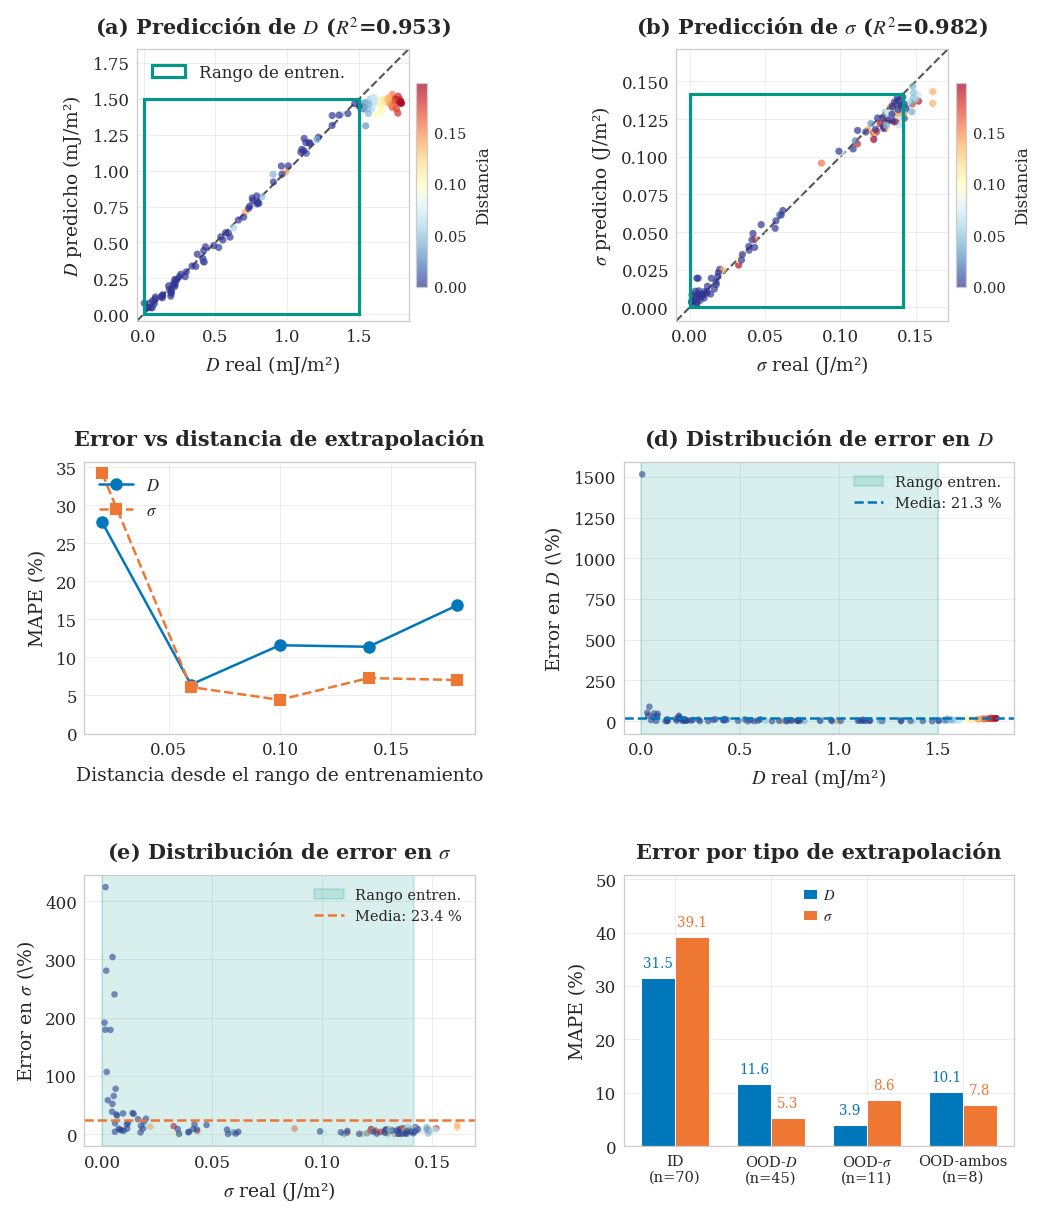


✓ Evaluación OOD guardada:
   PNG: outputs_ablation_final/physics_guided_mzvar0.4_spectral0.8_annealing_nonfiltered/figures/ood_evaluation_.png
   PDF: outputs_ablation_final/physics_guided_mzvar0.4_spectral0.8_annealing_nonfiltered/figures/ood_evaluation_.pdf

RESUMEN DE EVALUACIÓN FUERA DE DISTRIBUCIÓN (OOD)
Categoría       n        MAPE D (%)      MAPE σ (%)     
-----------------------------------------------------------------
ID              70       31.49           39.09          
OOD-D           45       11.60           5.27           
OOD-sigma       11       3.95            8.61           
OOD-ambos       8        10.13           7.78           
-----------------------------------------------------------------
Total           134      21.28           23.36          

\begin{table}[htbp]
\centering
\caption{Desempeño de generalización fuera de distribución (OOD). ID: dentro de distribución, 
          OOD-$D$: solo $D$ fuera de rango, OOD-$\sigma$: solo $\sigma$ fuera de rango

In [30]:
# ==============================================================================
# OOD EVALUATION VISUALIZATION (Thesis-ready) - CORRECTED
# ==============================================================================

# =============================================================================
# RANGOS DE ENTRENAMIENTO CORRECTOS
# =============================================================================
#TRAIN_D_MIN = 0.0      # J/m² (0.0 mJ/m²)
#TRAIN_D_MAX = 1.5e-3      # J/m² (1.5 mJ/m²)
#TRAIN_SIGMA_MIN = 0.0    # J/m²
#TRAIN_SIGMA_MAX = 0.15    # J/m²

# =============================================================================
# Style setup (consistent with other figures)
# =============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.4,
})

# Colors (consistent palette)
COLORS = {
    'D': '#0077BB',           # Azul para D
    'sigma': '#EE7733',       # Naranja para σ  
    'train_range': '#009988', # Verde azulado para rango de entrenamiento
    'reference': '#555555',   # Gris para referencias
}
CMAP = 'RdYlBu_r'  # Colormap: azul=cerca, rojo=lejos

# =============================================================================
# Create figure
# =============================================================================
fig = plt.figure(figsize=(8, 9.5))
gs = fig.add_gridspec(3, 2, hspace=0.52, wspace=0.38)

# Color by distance from training
colors = total_dist

# -----------------------------------------------------------------------------
# (a) D prediction scatter
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])

sc = ax.scatter(D_true_ood * 1e3, D_pred_ood * 1e3, c=colors, cmap=CMAP, 
                s=12, alpha=0.7, edgecolors='none', rasterized=True)

d_min = min(D_true_ood.min(), D_pred_ood.min()) * 1e3 - 0.05
d_max = max(D_true_ood.max(), D_pred_ood.max()) * 1e3 + 0.05
ax.plot([d_min, d_max], [d_min, d_max], '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

# Training range box - CORREGIDO
print(f"Drawing training D range box: [{TRAIN_D_MIN*1e3:.2f}, {TRAIN_D_MAX*1e3:.2f}] mJ/m²")
rect = plt.Rectangle((TRAIN_D_MIN * 1e3, TRAIN_D_MIN * 1e3),  # origen (0, 0) en mJ/m²
                      (TRAIN_D_MAX - TRAIN_D_MIN) * 1e3,       # ancho: 1.5 mJ/m²
                      (TRAIN_D_MAX - TRAIN_D_MIN) * 1e3,       # alto: 1.5 mJ/m²
                      fill=False, edgecolor=COLORS['train_range'], linewidth=1.5, 
                      linestyle='-', label='Rango de entren.', zorder=5)
ax.add_patch(rect)

ax.set_xlabel('$D$ real (mJ/m²)')
ax.set_ylabel('$D$ predicho (mJ/m²)')
ax.set_title(f'(a) Predicción de $D$ ($R^2$={r2_D_ood:.3f})', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8')
ax.set_xlim([d_min, d_max])
ax.set_ylim([d_min, d_max])
ax.set_aspect('equal', adjustable='box')

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('Distancia', fontsize=8)
cbar.ax.tick_params(labelsize=7)

# -----------------------------------------------------------------------------
# (b) σ prediction scatter
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])

sc = ax.scatter(s_true_ood, s_pred_ood, c=colors, cmap=CMAP,
                s=12, alpha=0.7, edgecolors='none', rasterized=True)

s_min = min(s_true_ood.min(), s_pred_ood.min()) - 0.01
s_max = max(s_true_ood.max(), s_pred_ood.max()) + 0.01
ax.plot([s_min, s_max], [s_min, s_max], '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

# Training range box - CORREGIDO
rect = plt.Rectangle((TRAIN_SIGMA_MIN, TRAIN_SIGMA_MIN),  # origen (0, 0)
                      TRAIN_SIGMA_MAX - TRAIN_SIGMA_MIN,   # ancho: 0.15
                      TRAIN_SIGMA_MAX - TRAIN_SIGMA_MIN,   # alto: 0.15
                      fill=False, edgecolor=COLORS['train_range'], linewidth=1.5, 
                      linestyle='-', zorder=5)

#rect = plt.Rectangle((0.02, 0.02),  # origen (0, 0)
#                      0.15 - 0.02,   # ancho: 0.15
#                      0.15 - 0.02,   # alto: 0.15
#                      fill=False, edgecolor=COLORS['train_range'], linewidth=1.5, 
#                      linestyle='-', zorder=5)


ax.add_patch(rect)

ax.set_xlabel('$\\sigma$ real (J/m²)')
ax.set_ylabel('$\\sigma$ predicho (J/m²)')
ax.set_title(f'(b) Predicción de $\\sigma$ ($R^2$={r2_s_ood:.3f})', fontweight='semibold', pad=8)
ax.set_xlim([s_min, s_max])
ax.set_ylim([s_min, s_max])
ax.set_aspect('equal', adjustable='box')

cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('Distancia', fontsize=8)
cbar.ax.tick_params(labelsize=7)

# -----------------------------------------------------------------------------
# (c) MAPE vs Distance from Training
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[1, 0])

valid_D = ~np.isnan(D_mape_by_total)
valid_s = ~np.isnan(s_mape_by_total)

if np.any(valid_D):
    ax.plot(np.array(total_bin_centers)[valid_D], np.array(D_mape_by_total)[valid_D], 
            'o-', linewidth=1.2, markersize=5, color=COLORS['D'], label='$D$')
if np.any(valid_s):
    ax.plot(np.array(total_bin_centers)[valid_s], np.array(s_mape_by_total)[valid_s], 
            's--', linewidth=1.2, markersize=5, color=COLORS['sigma'], label='$\\sigma$')

ax.set_xlabel('Distancia desde el rango de entrenamiento')
ax.set_ylabel('MAPE (%)')
ax.set_title('Error vs distancia de extrapolación', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8')
ax.set_ylim(bottom=0)

# -----------------------------------------------------------------------------
# (d) D error vs true D
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[1, 1])

ax.scatter(D_true_ood * 1e3, D_error_pct, c=colors, cmap=CMAP, 
           s=10, alpha=0.6, edgecolors='none', rasterized=True)

# Training range shading - CORREGIDO
ax.axvspan(TRAIN_D_MIN * 1e3, TRAIN_D_MAX * 1e3, alpha=0.15, 
           color=COLORS['train_range'], label='Rango entren.')
ax.axhline(overall_D_mape, color=COLORS['D'], linestyle='--', linewidth=1.2, 
           label=f'Media: {overall_D_mape:.1f} %')

ax.set_xlabel('$D$ real (mJ/m²)')
ax.set_ylabel('Error en $D$ (\\%)')
ax.set_title('(d) Distribución de error en $D$', fontweight='semibold', pad=8)
ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8', fontsize=7)

# -----------------------------------------------------------------------------
# (e) σ error vs true σ
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[2, 0])

ax.scatter(s_true_ood, sigma_error_pct, c=colors, cmap=CMAP, 
           s=10, alpha=0.6, edgecolors='none', rasterized=True)

# Training range shading - CORREGIDO
ax.axvspan(TRAIN_SIGMA_MIN, TRAIN_SIGMA_MAX, alpha=0.15, 
           color=COLORS['train_range'], label='Rango entren.')
ax.axhline(overall_s_mape, color=COLORS['sigma'], linestyle='--', linewidth=1.2,
           label=f'Media: {overall_s_mape:.1f} %')

ax.set_xlabel('$\\sigma$ real (J/m²)')
ax.set_ylabel('Error en $\\sigma$ (\\%)')
ax.set_title('(e) Distribución de error en $\\sigma$', fontweight='semibold', pad=8)
ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8', fontsize=7)

# -----------------------------------------------------------------------------
# (f) MAPE by Category (bar chart) - LEYENDA CORREGIDA
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[2, 1])

cat_order = ['ID', 'OOD-D', 'OOD-σ', 'OOD-both']
cat_labels_display = ['ID', 'OOD-$D$', 'OOD-$\\sigma$', 'OOD-ambos']
cat_D_mape = []
cat_s_mape = []
cat_labels = []
cat_labels_plot = []
cat_counts = []

for cat, cat_disp in zip(cat_order, cat_labels_display):
    mask = np.array([c == cat for c in categories])
    if mask.sum() > 0:
        cat_labels.append(cat)
        cat_labels_plot.append(cat_disp)
        cat_counts.append(mask.sum())
        cat_D_mape.append(D_error_pct[mask].mean())
        cat_s_mape.append(sigma_error_pct[mask].mean())

if len(cat_labels) > 0:
    x = np.arange(len(cat_labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, cat_D_mape, width, label='$D$', 
                   color=COLORS['D'], edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(x + width/2, cat_s_mape, width, label='$\\sigma$', 
                   color=COLORS['sigma'], edgecolor='white', linewidth=0.5)
    
    # X-axis labels with counts
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l}\n(n={n})' for l, n in zip(cat_labels_plot, cat_counts)], 
                       fontsize=7)
    
    # Value labels on bars
    for bar, val in zip(bars1, cat_D_mape):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1.5, 
                f'{val:.1f}', ha='center', va='bottom', fontsize=6.5, 
                color=COLORS['D'], fontweight='medium')
    for bar, val in zip(bars2, cat_s_mape):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=6.5,
                color=COLORS['sigma'], fontweight='medium')

ax.set_ylabel('MAPE (%)')
ax.set_title('Error por tipo de extrapolación', fontweight='semibold', pad=8)

# LEYENDA CORREGIDA - en esquina superior derecha, más compacta
ax.legend(loc='upper center', framealpha=0.95, edgecolor='0.8',
          fontsize=7, handlelength=1.0, handletextpad=0.4)

# Aumentar espacio arriba para labels Y asegurar que leyenda no se solape
if len(cat_D_mape) > 0:
    max_val = max(max(cat_D_mape), max(cat_s_mape))
    ax.set_ylim(0, max_val * 1.30)  # 30% extra de espacio arriba

# =============================================================================
# Save
# =============================================================================
plt.tight_layout()

fig_path = FIG_DIR / f"ood_evaluation_.png"
pdf_path = FIG_DIR / f"ood_evaluation_.pdf"

plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Evaluación OOD guardada:")
print(f"   PNG: {fig_path}")
print(f"   PDF: {pdf_path}")

# =============================================================================
# Summary table
# =============================================================================
print(f"\n{'='*65}")
print(f"RESUMEN DE EVALUACIÓN FUERA DE DISTRIBUCIÓN (OOD)")
print(f"{'='*65}")
print(f"{'Categoría':<15} {'n':<8} {'MAPE D (%)':<15} {'MAPE σ (%)':<15}")
print(f"{'-'*65}")
for cat, n, d_mape, s_mape in zip(cat_labels_plot, cat_counts, cat_D_mape, cat_s_mape):
    cat_clean = cat.replace('$', '').replace('\\', '')
    print(f"{cat_clean:<15} {n:<8} {d_mape:<15.2f} {s_mape:<15.2f}")
print(f"{'-'*65}")
print(f"{'Total':<15} {len(D_true_ood):<8} {overall_D_mape:<15.2f} {overall_s_mape:<15.2f}")
print(f"{'='*65}")

# LaTeX table
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Desempeño de generalización fuera de distribución (OOD). ID: dentro de distribución, 
          OOD-$D$: solo $D$ fuera de rango, OOD-$\\sigma$: solo $\\sigma$ fuera de rango, 
          OOD-ambos: ambos parámetros fuera de rango.}}
\\label{{tab:ood_results}}
\\begin{{tabular}}{{lccc}}
\\toprule
Categoría & $n$ & MAPE $D$ (\\%) & MAPE $\\sigma$ (\\%) \\\\
\\midrule""")
for cat, n, d_mape, s_mape in zip(cat_labels_plot, cat_counts, cat_D_mape, cat_s_mape):
    cat_latex = cat.replace('OOD-$D$', 'OOD-$D$').replace('OOD-$\\sigma$', 'OOD-$\\sigma$')
    print(f"{cat_latex} & {n} & {d_mape:.1f} & {s_mape:.1f} \\\\")
print(f"""\\midrule
Total & {len(D_true_ood)} & {overall_D_mape:.1f} & {overall_s_mape:.1f} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

In [31]:

# ==============================================================================
# CELL 23: COMPARISON TABLE (for thesis)
# ==============================================================================

print("\n" + "="*70)
print("SUMMARY TABLE FOR THESIS")
print("="*70)
print(f"\n{'Category':<15} {'N':>5} {'D MAPE':>10} {'σ MAPE':>10} {'Avg Distance':>12}")
print("-"*55)

for cat in ['ID', 'OOD-D', 'OOD-σ', 'OOD-both', 'ALL']:
    if cat == 'ALL':
        mask = np.ones(len(categories), dtype=bool)
    else:
        mask = np.array([c == cat for c in categories])
    
    if mask.sum() > 0:
        d_mape = D_error_pct[mask].mean()
        s_mape = sigma_error_pct[mask].mean()
        avg_dist = total_dist[mask].mean()
        print(f"{cat:<15} {mask.sum():>5} {d_mape:>9.1f}% {s_mape:>9.1f}% {avg_dist:>12.3f}")

print("-"*55)

# Also print the in-distribution performance from training
print(f"\n(Training validation: D MAPE ≈ 3.3%, σ MAPE ≈ 7.6%)")

print("\n" + "="*70)
print("KEY FINDING FOR THESIS:")
print("="*70)
print("""
Compare the OOD-D and OOD-σ MAPE values above with:
1. Your training validation MAPE (3.3% D, 7.6% σ)
2. A baseline CNN trained without physics (run separately)

If the PINN shows better OOD performance than baseline, this demonstrates
that physics constraints improve extrapolation capability.
""")


SUMMARY TABLE FOR THESIS

Category            N     D MAPE     σ MAPE Avg Distance
-------------------------------------------------------
ID                 70      31.5%      39.1%        0.000
OOD-D              45      11.6%       5.3%        0.109
OOD-σ              11       3.9%       8.6%        0.051
OOD-both            8      10.1%       7.8%        0.103
ALL               134      21.3%      23.4%        0.047
-------------------------------------------------------

(Training validation: D MAPE ≈ 3.3%, σ MAPE ≈ 7.6%)

KEY FINDING FOR THESIS:

Compare the OOD-D and OOD-σ MAPE values above with:
1. Your training validation MAPE (3.3% D, 7.6% σ)
2. A baseline CNN trained without physics (run separately)

If the PINN shows better OOD performance than baseline, this demonstrates
that physics constraints improve extrapolation capability.



In [32]:
# ==============================================================================
# ANÁLISIS EXHAUSTIVO DE FEATURES ESPECTRALES PARA σ
# ==============================================================================
# Objetivo: Encontrar la mejor combinación de features espectrales que
# prediga σ con alta correlación y baja correlación con D

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from scipy.ndimage import label, find_objects
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("ANÁLISIS EXHAUSTIVO DE FEATURES ESPECTRALES")
print("="*70)


# ==============================================================================
# PARTE 1: FUNCIONES PARA EXTRAER FEATURES ESPECTRALES
# ==============================================================================

def extract_all_spectral_features(mz):
    """
    Extrae múltiples features espectrales de una imagen mz.
    
    Args:
        mz: Imagen 2D de magnetización (H, W) - numpy array o torch tensor
    
    Returns:
        dict con todos los features extraídos
    """
    if isinstance(mz, torch.Tensor):
        mz = mz.cpu().numpy()
    
    # Asegurar que es 2D
    if mz.ndim == 3:
        mz = mz[0]  # Tomar primer canal
    
    H, W = mz.shape
    features = {}
    
    # =========================================
    # 1. FFT Y ESPECTRO DE POTENCIA
    # =========================================
    fft = np.fft.fft2(mz)
    fft_shifted = np.fft.fftshift(fft)
    power = np.abs(fft_shifted) ** 2
    
    # Grilla de frecuencias
    ky = np.fft.fftfreq(H).reshape(-1, 1)
    kx = np.fft.fftfreq(W).reshape(1, -1)
    ky = np.fft.fftshift(ky)
    kx = np.fft.fftshift(kx)
    k_mag = np.sqrt(kx**2 + ky**2)
    
    # Normalizar espectro
    power_norm = power / (power.sum() + 1e-10)
    
    # =========================================
    # 2. MOMENTOS DEL ESPECTRO
    # =========================================
    
    # Frecuencia media (primer momento)
    k_mean = np.sum(power_norm * k_mag)
    features['k_mean'] = k_mean
    
    # Varianza espectral (segundo momento central)
    k_var = np.sum(power_norm * (k_mag - k_mean)**2)
    k_std = np.sqrt(k_var)
    features['k_std'] = k_std
    
    # Ancho espectral (igual que antes)
    features['spectral_width'] = k_std
    
    # Ancho RELATIVO (normalizado)
    features['relative_width'] = k_std / (k_mean + 1e-10)
    
    # Skewness espectral (tercer momento)
    k_skew = np.sum(power_norm * ((k_mag - k_mean) / (k_std + 1e-10))**3)
    features['k_skewness'] = k_skew
    
    # Kurtosis espectral (cuarto momento)
    k_kurt = np.sum(power_norm * ((k_mag - k_mean) / (k_std + 1e-10))**4) - 3
    features['k_kurtosis'] = k_kurt
    
    # =========================================
    # 3. FRECUENCIA DOMINANTE (PICO)
    # =========================================
    
    # Perfil radial del espectro
    k_bins = np.linspace(0, 0.5, 50)
    radial_profile = np.zeros(len(k_bins) - 1)
    
    for i in range(len(k_bins) - 1):
        mask = (k_mag >= k_bins[i]) & (k_mag < k_bins[i+1])
        if mask.sum() > 0:
            radial_profile[i] = power[mask].mean()
    
    k_centers = (k_bins[:-1] + k_bins[1:]) / 2
    
    # Frecuencia del pico (excluyendo DC)
    radial_profile_no_dc = radial_profile.copy()
    radial_profile_no_dc[:2] = 0  # Excluir frecuencias muy bajas
    
    if radial_profile_no_dc.max() > 0:
        k_peak_idx = np.argmax(radial_profile_no_dc)
        k_peak = k_centers[k_peak_idx]
    else:
        k_peak = k_mean
    
    features['k_peak'] = k_peak
    
    # Altura del pico (normalizada)
    peak_height = radial_profile_no_dc.max() / (radial_profile_no_dc.sum() + 1e-10)
    features['peak_height'] = peak_height
    
    # Ancho del pico (FWHM aproximado)
    if radial_profile_no_dc.max() > 0:
        half_max = radial_profile_no_dc.max() / 2
        above_half = radial_profile_no_dc > half_max
        if above_half.sum() > 1:
            indices = np.where(above_half)[0]
            fwhm = k_centers[indices[-1]] - k_centers[indices[0]]
        else:
            fwhm = k_centers[1] - k_centers[0]
    else:
        fwhm = 0.1
    
    features['peak_fwhm'] = fwhm
    features['peak_fwhm_relative'] = fwhm / (k_peak + 1e-10)
    
    # =========================================
    # 4. ANISOTROPÍA DEL ESPECTRO
    # =========================================
    
    # Tensor de inercia del espectro
    Ixx = np.sum(power_norm * kx**2)
    Iyy = np.sum(power_norm * ky**2)
    Ixy = np.sum(power_norm * kx * ky)
    
    # Eigenvalores
    trace = Ixx + Iyy
    det = Ixx * Iyy - Ixy**2
    discriminant = max((trace/2)**2 - det, 0)
    
    lambda1 = trace/2 + np.sqrt(discriminant)
    lambda2 = trace/2 - np.sqrt(discriminant)
    
    # Anisotropía (0 = isotrópico, 1 = muy anisotrópico)
    anisotropy = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-10)
    features['anisotropy'] = anisotropy
    
    # Orientación preferencial
    if Ixy != 0:
        orientation = 0.5 * np.arctan2(2*Ixy, Ixx - Iyy)
    else:
        orientation = 0
    features['orientation'] = orientation
    
    # =========================================
    # 5. ANÁLISIS POR BANDAS DE FRECUENCIA
    # =========================================
    
    # Definir bandas
    bands = {
        'very_low': (0.0, 0.05),
        'low': (0.05, 0.15),
        'mid': (0.15, 0.30),
        'high': (0.30, 0.50)
    }
    
    total_power = power.sum()
    for band_name, (k_min, k_max) in bands.items():
        mask = (k_mag >= k_min) & (k_mag < k_max)
        band_power = power[mask].sum() / (total_power + 1e-10)
        features[f'power_{band_name}'] = band_power
    
    # Ratios entre bandas
    features['high_low_ratio'] = features['power_high'] / (features['power_low'] + 1e-10)
    features['mid_low_ratio'] = features['power_mid'] / (features['power_low'] + 1e-10)
    
    # =========================================
    # 6. DECAIMIENTO ESPECTRAL
    # =========================================
    
    # Ajustar ley de potencia: P(k) ~ k^(-β)
    # En escala log-log: log(P) = -β * log(k) + c
    
    valid_mask = (k_centers > 0.05) & (radial_profile > 0)
    if valid_mask.sum() > 3:
        log_k = np.log(k_centers[valid_mask])
        log_P = np.log(radial_profile[valid_mask])
        
        # Regresión lineal
        coeffs = np.polyfit(log_k, log_P, 1)
        spectral_slope = -coeffs[0]  # β
    else:
        spectral_slope = 2.0  # Valor por defecto
    
    features['spectral_slope'] = spectral_slope
    
    # =========================================
    # 7. ENTROPÍA ESPECTRAL
    # =========================================
    
    # Entropía de Shannon del espectro (normalizado como distribución)
    p = power_norm.flatten()
    p = p[p > 1e-10]  # Evitar log(0)
    spectral_entropy = -np.sum(p * np.log(p))
    features['spectral_entropy'] = spectral_entropy
    
    # Entropía normalizada (0-1)
    max_entropy = np.log(H * W)
    features['spectral_entropy_norm'] = spectral_entropy / max_entropy
    
    # =========================================
    # 8. FUNCIÓN DE AUTOCORRELACIÓN
    # =========================================
    
    # Autocorrelación = IFFT(|FFT|²)
    autocorr = np.fft.ifft2(power).real
    autocorr = np.fft.fftshift(autocorr)
    autocorr = autocorr / autocorr.max()  # Normalizar
    
    # Centro de la autocorrelación
    cy, cx = H // 2, W // 2
    
    # Perfil radial de autocorrelación
    max_r = min(H, W) // 4
    r_values = np.arange(1, max_r)
    autocorr_profile = []
    
    for r in r_values:
        # Puntos en círculo de radio r
        angles = np.linspace(0, 2*np.pi, max(8, int(2*np.pi*r)))
        y_coords = (cy + r * np.sin(angles)).astype(int)
        x_coords = (cx + r * np.cos(angles)).astype(int)
        
        # Filtrar puntos válidos
        valid = (y_coords >= 0) & (y_coords < H) & (x_coords >= 0) & (x_coords < W)
        if valid.sum() > 0:
            autocorr_profile.append(autocorr[y_coords[valid], x_coords[valid]].mean())
        else:
            autocorr_profile.append(0)
    
    autocorr_profile = np.array(autocorr_profile)
    
    # Longitud de correlación (donde autocorr cae a 1/e)
    threshold = 1 / np.e
    below_threshold = autocorr_profile < threshold
    if below_threshold.any():
        correlation_length = r_values[np.argmax(below_threshold)]
    else:
        correlation_length = max_r
    
    features['correlation_length'] = correlation_length
    features['correlation_length_norm'] = correlation_length / max_r
    
    # Tasa de decaimiento de autocorrelación
    if len(autocorr_profile) > 5:
        # Ajustar exponencial: C(r) = exp(-r/ξ)
        try:
            valid_ac = autocorr_profile[:20] > 0.01
            if valid_ac.sum() > 3:
                log_ac = np.log(autocorr_profile[:20][valid_ac])
                r_valid = r_values[:20][valid_ac]
                decay_rate = -np.polyfit(r_valid, log_ac, 1)[0]
            else:
                decay_rate = 0.1
        except:
            decay_rate = 0.1
    else:
        decay_rate = 0.1
    
    features['autocorr_decay_rate'] = decay_rate
    
    # =========================================
    # 9. ESTADÍSTICAS DE DOMINIOS (ESPACIO REAL)
    # =========================================
    
    # Binarizar imagen
    mz_binary = (mz > 0).astype(int)
    
    # Encontrar componentes conectados (dominios "up")
    labeled_up, num_domains_up = label(mz_binary)
    
    # Encontrar dominios "down"
    labeled_down, num_domains_down = label(1 - mz_binary)
    
    features['num_domains'] = num_domains_up + num_domains_down
    
    # Estadísticas de áreas de dominios
    if num_domains_up > 0:
        regions = find_objects(labeled_up)
        areas = []
        perimeters = []
        
        for region in regions:
            if region is not None:
                domain_mask = labeled_up[region] > 0
                area = domain_mask.sum()
                if area > 5:  # Filtrar dominios muy pequeños (ruido)
                    areas.append(area)
                    # Perímetro aproximado (conteo de bordes)
                    perim = np.sum(domain_mask[:-1, :] != domain_mask[1:, :])
                    perim += np.sum(domain_mask[:, :-1] != domain_mask[:, 1:])
                    perimeters.append(perim)
        
        if len(areas) > 0:
            areas = np.array(areas)
            perimeters = np.array(perimeters)
            
            features['domain_area_mean'] = areas.mean()
            features['domain_area_std'] = areas.std()
            features['domain_area_cv'] = areas.std() / (areas.mean() + 1e-10)
            
            # Circularidad: 4π × area / perimeter²
            circularities = 4 * np.pi * areas / (perimeters**2 + 1e-10)
            features['circularity_mean'] = circularities.mean()
            features['circularity_std'] = circularities.std()
        else:
            features['domain_area_mean'] = 0
            features['domain_area_std'] = 0
            features['domain_area_cv'] = 0
            features['circularity_mean'] = 0
            features['circularity_std'] = 0
    else:
        features['domain_area_mean'] = 0
        features['domain_area_std'] = 0
        features['domain_area_cv'] = 0
        features['circularity_mean'] = 0
        features['circularity_std'] = 0
    
    # =========================================
    # 10. RUGOSIDAD DE BORDES
    # =========================================
    
    # Detectar bordes (gradiente)
    grad_y = np.diff(mz, axis=0)
    grad_x = np.diff(mz, axis=1)
    
    # Magnitud del gradiente (en bordes comunes)
    min_h = min(grad_y.shape[0], grad_x.shape[0])
    min_w = min(grad_y.shape[1], grad_x.shape[1])
    grad_mag = np.sqrt(grad_y[:min_h, :min_w]**2 + grad_x[:min_h, :min_w]**2)
    
    # Estadísticas del gradiente
    features['gradient_mean'] = grad_mag.mean()
    features['gradient_std'] = grad_mag.std()
    features['gradient_max'] = grad_mag.max()
    
    # "Rugosidad" = variación del gradiente
    features['edge_roughness'] = grad_mag.std() / (grad_mag.mean() + 1e-10)
    
    return features


# ==============================================================================
# PARTE 2: EXTRAER FEATURES DE TODO EL DATASET
# ==============================================================================

print("\nExtrayendo features espectrales de todas las muestras...")
print("(Esto puede tomar unos minutos)")

# Crear dataset sin normalización
feature_dataset = MzDataset(
    csv_path=CSV_PATH,
    img_dir=IMG_DIR,
    npy_dir=NPY_DIR,
    index_col=IMG_INDEX_COL,
    transform=None,
    filter_low_D=False,
    D_min_threshold=ID_D_RANGE[0],
    filter_low_sigma=False,
    sigma_min_threshold=ID_SIGMA_RANGE[0],
    load_npy=True,
    target_mean=None,
    target_std=None,
    max_samples=None
)

# Almacenar todos los features
all_features = []
all_D = []
all_sigma = []

for idx in range(len(feature_dataset)):
    try:
        # =====================================================
        # CORREGIDO: Desempacar los 5 elementos correctamente
        # =====================================================
        sample = feature_dataset[idx]
        
        # Tu dataset devuelve: (img, m_field, Ku_block, target, run_id)
        img, m_field, Ku_block, target, run_id = sample
        
        # =====================================================
        # OPCIÓN 1: Usar m_field['mz'] (valores reales de magnetización)
        # Esta es la mejor opción para análisis físico
        # =====================================================
        if m_field is not None and 'mz' in m_field:
            mz = m_field['mz']
            if isinstance(mz, torch.Tensor):
                mz = mz.cpu().numpy()
        else:
            # Fallback: usar la imagen (primer canal, ya que se repitió 3 veces)
            if isinstance(img, torch.Tensor):
                mz = img[0].cpu().numpy()  # (H, W)
            else:
                mz = np.array(img)[0]
        
        # Verificar que mz es válido
        if mz is None or mz.size == 0:
            raise ValueError("mz está vacío")
        
        if not np.isfinite(mz).all():
            raise ValueError("mz contiene NaN o Inf")
        
        # Extraer features
        features = extract_all_spectral_features(mz)
        
        # Extraer targets (D, sigma)
        if isinstance(target, torch.Tensor):
            D_val = target[0].item()
            sigma_val = target[1].item()
        else:
            D_val = float(target[0])
            sigma_val = float(target[1])
        
        all_features.append(features)
        all_D.append(D_val)
        all_sigma.append(sigma_val)
        
        if (idx + 1) % 500 == 0:
            print(f"  Procesadas {idx + 1}/{len(feature_dataset)} muestras")
            
    except Exception as e:
        # Solo mostrar los primeros errores para no saturar
        if idx < 5:
            print(f"  Error en muestra {idx}: {type(e).__name__}: {e}")
        elif idx == 5:
            print("  (suprimiendo errores adicionales...)")
        continue

print(f"\n✓ Extraídos features de {len(all_features)} muestras")

# Verificar que hay datos
if len(all_features) == 0:
    raise RuntimeError(
        "No se pudieron extraer features de ninguna muestra.\n"
        "Verifica que:\n"
        "  1. Los archivos NPY existen y tienen el formato correcto\n"
        "  2. m_field contiene 'mz' con valores válidos"
    )

# Convertir a arrays
all_D = np.array(all_D)
all_sigma = np.array(all_sigma)

# Crear matriz de features
feature_names = list(all_features[0].keys())
feature_matrix = np.array([[f[name] for name in feature_names] for f in all_features])

print(f"  Total de features: {len(feature_names)}")
print(f"  Features: {feature_names}")

# ==============================================================================
# PARTE 3: ANÁLISIS DE CORRELACIÓN
# ==============================================================================

print("\n" + "="*70)
print("ANÁLISIS DE CORRELACIÓN")
print("="*70)

# Calcular correlaciones con σ y D
correlations = []

print(f"\n{'Feature':<30} {'r(σ)':<12} {'r(D)':<12} {'|r(σ)|-|r(D)|':<15} {'Útil para σ?'}")
print("-" * 85)

for i, name in enumerate(feature_names):
    feature_values = feature_matrix[:, i]
    
    # Filtrar NaN/Inf
    valid = np.isfinite(feature_values)
    if valid.sum() < 100:
        continue
    
    corr_sigma, p_sigma = pearsonr(feature_values[valid], all_sigma[valid])
    corr_D, p_D = pearsonr(feature_values[valid], all_D[valid])
    
    # "Utilidad" = alta correlación con σ, baja con D
    utility = abs(corr_sigma) - abs(corr_D)
    
    useful = "✓✓" if (abs(corr_sigma) > 0.3 and utility > 0.1) else \
             "✓" if abs(corr_sigma) > 0.2 else ""
    
    correlations.append({
        'name': name,
        'corr_sigma': corr_sigma,
        'corr_D': corr_D,
        'p_sigma': p_sigma,
        'p_D': p_D,
        'utility': utility
    })
    
    print(f"{name:<30} {corr_sigma:>+.4f}      {corr_D:>+.4f}      {utility:>+.4f}         {useful}")

# Ordenar por utilidad para σ
correlations.sort(key=lambda x: x['utility'], reverse=True)

print("\n" + "="*70)
print("TOP 10 FEATURES MÁS ÚTILES PARA σ (alta r(σ), baja r(D))")
print("="*70)
for i, c in enumerate(correlations[:10]):
    print(f"{i+1:2d}. {c['name']:<30} r(σ)={c['corr_sigma']:+.4f}, r(D)={c['corr_D']:+.4f}")


# ==============================================================================
# PARTE 4: REGRESIÓN UNIVARIADA (cada feature por separado)
# ==============================================================================

print("\n" + "="*70)
print("REGRESIÓN UNIVARIADA: σ = f(feature)")
print("="*70)

univariate_results = []

for i, name in enumerate(feature_names):
    feature_values = feature_matrix[:, i].reshape(-1, 1)
    
    # Filtrar NaN/Inf
    valid = np.isfinite(feature_values.flatten())
    if valid.sum() < 100:
        continue
    
    X = feature_values[valid]
    y = all_sigma[valid]
    
    # Regresión lineal simple
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    univariate_results.append({
        'name': name,
        'r2': r2,
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'coef': model.coef_[0],
        'intercept': model.intercept_
    })

# Ordenar por R²
univariate_results.sort(key=lambda x: x['r2'], reverse=True)

print(f"\n{'Feature':<30} {'R²':<10} {'CV R²':<15}")
print("-" * 60)
for r in univariate_results[:15]:
    print(f"{r['name']:<30} {r['r2']:.4f}     {r['cv_r2_mean']:.4f} ± {r['cv_r2_std']:.4f}")


# ==============================================================================
# PARTE 5: REGRESIÓN MULTIVARIADA (combinación de features)
# ==============================================================================

print("\n" + "="*70)
print("REGRESIÓN MULTIVARIADA: σ = f(features)")
print("="*70)

# Seleccionar features útiles (alta correlación con σ, no NaN)
useful_features = []
for c in correlations:
    if abs(c['corr_sigma']) > 0.15:  # Umbral mínimo de correlación
        idx = feature_names.index(c['name'])
        if np.isfinite(feature_matrix[:, idx]).all():
            useful_features.append(c['name'])

print(f"\nFeatures seleccionados ({len(useful_features)}): {useful_features[:10]}...")

# Crear matriz de features útiles
useful_indices = [feature_names.index(name) for name in useful_features]
X_useful = feature_matrix[:, useful_indices]

# Filtrar muestras con NaN
valid_samples = np.isfinite(X_useful).all(axis=1)
X_clean = X_useful[valid_samples]
y_clean = all_sigma[valid_samples]
D_clean = all_D[valid_samples]

print(f"Muestras válidas: {len(y_clean)}/{len(all_sigma)}")

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Probar diferentes modelos
models = {
    'Linear': LinearRegression(),
    'Ridge (α=0.1)': Ridge(alpha=0.1),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.001)': Lasso(alpha=0.001),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5)
}

print(f"\n{'Modelo':<20} {'R² train':<12} {'CV R²':<20}")
print("-" * 55)

best_model = None
best_cv_score = -1

for name, model in models.items():
    model.fit(X_scaled, y_clean)
    y_pred = model.predict(X_scaled)
    r2_train = r2_score(y_clean, y_pred)
    
    cv_scores = cross_val_score(model, X_scaled, y_clean, cv=5, scoring='r2')
    
    print(f"{name:<20} {r2_train:.4f}       {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    if cv_scores.mean() > best_cv_score:
        best_cv_score = cv_scores.mean()
        best_model = model
        best_model_name = name

print(f"\n✓ Mejor modelo: {best_model_name} (CV R² = {best_cv_score:.4f})")


# ==============================================================================
# PARTE 6: SELECCIÓN DE FEATURES (encontrar el subconjunto óptimo)
# ==============================================================================

print("\n" + "="*70)
print("SELECCIÓN DE FEATURES: Encontrar combinación óptima")
print("="*70)

# Forward selection
def forward_selection(X, y, feature_names, max_features=10):
    """Selección hacia adelante de features."""
    n_features = X.shape[1]
    selected = []
    remaining = list(range(n_features))
    
    results = []
    
    for i in range(min(max_features, n_features)):
        best_score = -np.inf
        best_feature = None
        
        for feat_idx in remaining:
            current_features = selected + [feat_idx]
            X_subset = X[:, current_features]
            
            model = Ridge(alpha=0.1)
            cv_scores = cross_val_score(model, X_subset, y, cv=5, scoring='r2')
            score = cv_scores.mean()
            
            if score > best_score:
                best_score = score
                best_feature = feat_idx
        
        if best_feature is not None:
            selected.append(best_feature)
            remaining.remove(best_feature)
            
            results.append({
                'n_features': len(selected),
                'features': [feature_names[j] for j in selected],
                'cv_r2': best_score
            })
            
            print(f"  {len(selected)} features: CV R² = {best_score:.4f} (+{feature_names[best_feature]})")
    
    return results

print("\nForward Selection (añadiendo features uno a uno):")
selection_results = forward_selection(X_scaled, y_clean, useful_features, max_features=10)

# Encontrar el número óptimo de features (máximo CV R²)
best_result = max(selection_results, key=lambda x: x['cv_r2'])
print(f"\n✓ Óptimo: {best_result['n_features']} features con CV R² = {best_result['cv_r2']:.4f}")
print(f"  Features: {best_result['features']}")


# ==============================================================================
# PARTE 7: MODELO FINAL Y FÓRMULA
# ==============================================================================

print("\n" + "="*70)
print("MODELO FINAL")
print("="*70)

# Usar los features óptimos
optimal_features = best_result['features']
optimal_indices = [useful_features.index(name) for name in optimal_features]
X_optimal = X_scaled[:, optimal_indices]

# Entrenar modelo final
final_model = Ridge(alpha=0.1)
final_model.fit(X_optimal, y_clean)

# Métricas finales
y_pred_final = final_model.predict(X_optimal)
r2_final = r2_score(y_clean, y_pred_final)
mae_final = mean_absolute_error(y_clean, y_pred_final)
mape_final = np.mean(np.abs((y_clean - y_pred_final) / y_clean)) * 100

cv_scores_final = cross_val_score(final_model, X_optimal, y_clean, cv=5, scoring='r2')

print(f"\nMétricas del modelo final:")
print(f"  R² (train):     {r2_final:.4f}")
print(f"  R² (CV):        {cv_scores_final.mean():.4f} ± {cv_scores_final.std():.4f}")
print(f"  MAE:            {mae_final:.5f}")
print(f"  MAPE:           {mape_final:.2f}%")

# Coeficientes
print(f"\nCoeficientes (features escalados):")
for name, coef in zip(optimal_features, final_model.coef_):
    print(f"  {name:<30}: {coef:+.6f}")
print(f"  {'Intercepto':<30}: {final_model.intercept_:+.6f}")

# Obtener coeficientes en escala original
scaler_optimal = StandardScaler()
X_optimal_unscaled = X_clean[:, [useful_features.index(name) for name in optimal_features]]
scaler_optimal.fit(X_optimal_unscaled)

print(f"\nFórmula en escala original:")
print(f"  σ_pred = ", end="")
terms = []
for i, (name, coef) in enumerate(zip(optimal_features, final_model.coef_)):
    scale = scaler_optimal.scale_[i]
    mean = scaler_optimal.mean_[i]
    # coef_original = coef / scale
    # intercept_adjustment = -coef * mean / scale
    coef_orig = coef / scale
    terms.append(f"{coef_orig:+.6f} × {name}")

print(" + ".join(terms[:3]))
if len(terms) > 3:
    print("         + " + " + ".join(terms[3:]))
# ==============================================================================
# PARTE 8: VISUALIZACIÓN (Thesis-ready style)
# ==============================================================================

print("\n" + "="*70)
print("GENERANDO VISUALIZACIONES")
print("="*70)

# =============================================================================
# Style setup (consistent with other thesis figures)
# =============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.4,
})

# Colors (consistent palette)
COLORS = {
    'sigma': '#0077BB',       # Azul para σ
    'D': '#EE7733',           # Naranja para D
    'primary': '#009988',     # Verde azulado
    'secondary': '#CC3311',   # Rojo
    'neutral': '#555555',     # Gris
}

# =============================================================================
# DICCIONARIO DE ABREVIACIONES PARA FEATURES
# =============================================================================
FEATURE_ABBREV = {
    'gradient_mean': 'Grad Mean',
    'gradient_std': 'Grad Std',
    'gradient_max': 'Grad Max',
    'edge_roughness': 'Edge Rough',
    'k_mean': 'k Mean',
    'k_std': 'k Std',
    'k_skewness': 'k Skew',
    'k_kurtosis': 'k Kurt',
    'k_peak': 'k Peak',
    'spectral_width': 'Spec Width',
    'relative_width': 'Rel Width',
    'anisotropy': 'Anisotropy',
    'orientation': 'Orient',
    'power_very_low': 'P VeryLow',
    'power_low': 'P Low',
    'power_mid': 'P Mid',
    'power_high': 'P High',
    'high_low_ratio': 'Hi/Lo Ratio',
    'mid_low_ratio': 'Mid/Lo Ratio',
    'spectral_slope': 'Spec Slope',
    'spectral_entropy': 'Spec Entropy',
    'spectral_entropy_norm': 'Spec Ent N',
    'correlation_length': 'Corr Len',
    'correlation_length_norm': 'Corr Len N',
    'autocorr_decay_rate': 'Autocorr Dec',
    'num_domains': 'Num Domains',
    'domain_area_mean': 'Dom Area μ',
    'domain_area_std': 'Dom Area σ',
    'domain_area_cv': 'Dom Area CV',
    'circularity_mean': 'Circ Mean',
    'circularity_std': 'Circ Std',
    'peak_height': 'Peak Height',
    'peak_fwhm': 'Peak FWHM',
    'peak_fwhm_relative': 'Peak FWHM R',
}

def get_abbrev(name):
    """Get abbreviation for feature name."""
    return FEATURE_ABBREV.get(name, name[:12])

# =============================================================================
# Create figure
# =============================================================================
fig = plt.figure(figsize=(9.5, 11))
gs = fig.add_gridspec(3, 2, hspace=0.52, wspace=0.42)

# -----------------------------------------------------------------------------
# (a) Feature Correlations
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])

top_n = 12
top_correlations = correlations[:top_n]
corr_sigma_vals = [c['corr_sigma'] for c in top_correlations]
corr_D_vals = [c['corr_D'] for c in top_correlations]

# Usar abreviaciones
names_abbrev = [get_abbrev(c['name']) for c in top_correlations]

x_pos = np.arange(len(names_abbrev))
width = 0.38

bars1 = ax.bar(x_pos - width/2, corr_sigma_vals, width, 
               label='$r(\\sigma)$', color=COLORS['sigma'], 
               edgecolor='white', linewidth=0.3)
bars2 = ax.bar(x_pos + width/2, corr_D_vals, width, 
               label='$r(D)$', color=COLORS['D'], 
               edgecolor='white', linewidth=0.3)

ax.set_xticks(x_pos)
ax.set_xticklabels(names_abbrev, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Correlación de Pearson')
ax.set_title('(a) Correlación de features', fontweight='semibold', pad=8)
ax.legend(loc='lower right', framealpha=0.95, edgecolor='0.8')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylim(-1.0, 1.0)
ax.set_xlim(-0.6, len(names_abbrev) - 0.4)

# Líneas de referencia sutiles
for y in [-0.5, 0.5]:
    ax.axhline(y, color='lightgray', linewidth=0.4, zorder=0)

# -----------------------------------------------------------------------------
# (b) Univariate R²
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])

top_univariate = univariate_results[:10]
names_uni = [get_abbrev(r['name']) for r in top_univariate]
r2_vals = [r['r2'] for r in top_univariate]

y_pos = np.arange(len(names_uni))
bars = ax.barh(y_pos, r2_vals, height=0.65, color=COLORS['primary'], 
               edgecolor='white', linewidth=0.3)

ax.set_yticks(y_pos)
ax.set_yticklabels(names_uni, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('$R^2$')
ax.set_title('(b) $R^2$ univariado', fontweight='semibold', pad=8)

# Baseline
baseline_r2 = 0.38
ax.axvline(baseline_r2, color=COLORS['secondary'], linestyle='--', linewidth=1.5, 
           label=f'Baseline: {baseline_r2:.2f}', zorder=5)
ax.legend(loc='lower right', framealpha=0.95, edgecolor='0.8', fontsize=7)
ax.set_xlim(0, 0.7)

# Value labels
for bar, val in zip(bars, r2_vals):
    ax.text(val + 0.015, bar.get_y() + bar.get_height()/2, 
            f'{val:.2f}', va='center', fontsize=7, color='#333333')

# -----------------------------------------------------------------------------
# (c) Forward Feature Selection
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[1, 0])

n_feats = [r['n_features'] for r in selection_results]
cv_r2s = [r['cv_r2'] for r in selection_results]

ax.plot(n_feats, cv_r2s, 'o-', linewidth=1.5, markersize=6, 
        color=COLORS['primary'], markeredgecolor='white', markeredgewidth=1.0,
        label='CV $R^2$')

# Punto óptimo
best_idx = np.argmax(cv_r2s)
ax.scatter([n_feats[best_idx]], [cv_r2s[best_idx]], 
           s=120, c=COLORS['D'], zorder=10, edgecolors='white', linewidth=1.5,
           label=f'Óptimo: {n_feats[best_idx]} feat.')

# Baseline
ax.axhline(baseline_r2, color=COLORS['secondary'], linestyle='--', linewidth=1.5,
           label=f'Baseline: {baseline_r2:.2f}', zorder=1)

ax.set_xlabel('Número de features')
ax.set_ylabel('$R^2$ validación cruzada')
ax.set_title('(c) Selección secuencial de features', fontweight='semibold', pad=8)
ax.legend(loc='lower right', framealpha=0.95, edgecolor='0.8', fontsize=7)
ax.set_xlim(0, max(n_feats) + 1)
ax.set_ylim(0.2,1)

# -----------------------------------------------------------------------------
# (d) Model Performance
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[1, 1])

ax.scatter(y_clean, y_pred_final, s=10, alpha=0.5, c=COLORS['sigma'], 
           edgecolors='none', rasterized=True, zorder=2)

# Límites basados en datos reales (σ >= 0)
sigma_min_data = max(0, min(y_clean.min(), y_pred_final.min()) - 0.005)
sigma_max_data = max(y_clean.max(), y_pred_final.max()) + 0.005
plot_min = sigma_min_data
plot_max = sigma_max_data

ax.plot([plot_min, plot_max], [plot_min, plot_max], '-', 
        color=COLORS['neutral'], linewidth=1.2, label='$y=x$', zorder=5)

ax.set_xlabel('$\\sigma$ real (J/m²)')
ax.set_ylabel('$\\sigma$ predicho (J/m²)')
ax.set_title(f'(d) Desempeño del modelo ($R^2$={r2_final:.3f})', 
             fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8')
ax.set_xlim(plot_min, 0.15)
ax.set_ylim(plot_min, plot_max)
ax.set_aspect('equal', adjustable='box')

## -----------------------------------------------------------------------------
## (e) Residuals vs D
## -----------------------------------------------------------------------------
#ax = fig.add_subplot(gs[2, 0])
#
#residuals = y_clean - y_pred_final
#ax.scatter(D_clean * 1e3, residuals, s=10, alpha=0.5, c=COLORS['D'], 
#           edgecolors='none', rasterized=True, zorder=2)
#ax.axhline(0, color=COLORS['neutral'], linestyle='-', linewidth=1.2, zorder=5)
#
## Correlación residuos-D
#corr_res_D, p_val = pearsonr(D_clean, residuals)
#textstr = f'$r$ = {corr_res_D:.3f}'
#text_bbox = dict(boxstyle='round,pad=0.3', facecolor='white', 
#                 edgecolor='0.8', linewidth=0.5)
#ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=9,
#        verticalalignment='top', horizontalalignment='right', bbox=text_bbox)
#
#ax.set_xlabel('$D$ (mJ/m²)')
#ax.set_ylabel('Residuo ($\\sigma_{real} - \\sigma_{pred}$)')
#ax.set_title('(e) Residuos vs $D$', fontweight='semibold', pad=8)
#
#max_res = max(abs(residuals.min()), abs(residuals.max())) * 1.1
#ax.set_ylim(-max_res, max_res)
#
## -----------------------------------------------------------------------------
## (f) Error Distribution
## -----------------------------------------------------------------------------
#ax = fig.add_subplot(gs[2, 1])
#
## Error relativo con signo
#mask_valid = y_clean > 0.005  # Evitar división por cero
#relative_errors = np.zeros_like(y_clean)
#relative_errors[mask_valid] = (y_pred_final[mask_valid] - y_clean[mask_valid]) / y_clean[mask_valid] * 100
#
#rel_errors_valid = relative_errors[mask_valid]
#rel_errors_clipped = np.clip(rel_errors_valid, -100, 100)
#
#ax.hist(rel_errors_clipped, bins=35, alpha=0.75, color=COLORS['sigma'], 
#        edgecolor='white', linewidth=0.3)
#
## Línea en cero
#ax.axvline(0, color=COLORS['neutral'], linestyle='-', linewidth=1.2, zorder=0)
#
## Mediana
#median_err = np.median(rel_errors_valid)
#ax.axvline(median_err, color=COLORS['secondary'], linestyle='-', linewidth=1.5,
#           label=f'Mediana: {median_err:+.1f}%')
#
#ax.set_xlabel('Error relativo (\\%)')
#ax.set_ylabel('Frecuencia')
#ax.set_title(f'(f) Distribución de error (MAE={mae_final:.4f})', 
#             fontweight='semibold', pad=8)
#ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8', fontsize=7)
#ax.set_xlim(-100, 100)

# =============================================================================
# Save
# =============================================================================
plt.tight_layout()

fig_path = FIG_DIR / f"spectral_features_analysis_{RUN_TAG}.png"
pdf_path = FIG_DIR / f"spectral_features_analysis_{RUN_TAG}.pdf"

plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Figura guardada:")
print(f"   PNG: {fig_path}")
print(f"   PDF: {pdf_path}")

# =============================================================================
# Summary statistics
# =============================================================================
print(f"\n{'='*60}")
print(f"RESUMEN: ANÁLISIS DE FEATURES ESPECTRALES")
print(f"{'='*60}")
print(f"{'Métrica':<40} {'Valor':<20}")
print(f"{'-'*60}")
print(f"{'Features totales analizados':<40} {len(feature_names):<20}")
print(f"{'Features con |r(σ)| > 0.3':<40} {sum(1 for c in correlations if abs(c['corr_sigma']) > 0.3):<20}")
print(f"{'Número óptimo de features':<40} {best_result['n_features']:<20}")
print(f"{'R² baseline (spectral_width)':<40} {baseline_r2:<20.4f}")
print(f"{'R² modelo final (CV)':<40} {cv_scores_final.mean():<20.4f}")
print(f"{'Mejora sobre baseline':<40} {f'+{(cv_scores_final.mean() - baseline_r2) / baseline_r2 * 100:.1f}%':<20}")
print(f"{'Correlación residuos-D':<40} {corr_res_D:<20.4f}")
print(f"{'='*60}")

# LaTeX table
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Resultados del análisis de features espectrales para predicción de $\\sigma$.}}
\\label{{tab:spectral_features}}
\\begin{{tabular}}{{lc}}
\\toprule
Métrica & Valor \\\\
\\midrule
Features totales analizados & {len(feature_names)} \\\\
Features con $|r(\\sigma)| > 0.3$ & {sum(1 for c in correlations if abs(c['corr_sigma']) > 0.3)} \\\\
Número óptimo de features & {best_result['n_features']} \\\\
$R^2$ baseline & {baseline_r2:.3f} \\\\
$R^2$ modelo optimizado (CV) & {cv_scores_final.mean():.3f} \\\\
Mejora sobre baseline & +{(cv_scores_final.mean() - baseline_r2) / baseline_r2 * 100:.1f}\\% \\\\
Correlación residuos-$D$ & {corr_res_D:.3f} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")


# ==============================================================================
# PARTE 9: CÓDIGO PYTORCH PARA LA NUEVA PÉRDIDA
# ==============================================================================

print("\n" + "="*70)
print("CÓDIGO PYTORCH PARA LA NUEVA PÉRDIDA ESPECTRAL")
print("="*70)

# Generar código basado en los features óptimos
print(f"""
class ImprovedSpectralLossV2(nn.Module):
    '''
    Pérdida espectral mejorada basada en análisis empírico.
    
    Features óptimos encontrados: {optimal_features}
    CV R² = {cv_scores_final.mean():.4f}
    '''
    
    def __init__(self):
        super().__init__()
        
        # Coeficientes calibrados (escala normalizada)
        self.feature_names = {optimal_features}
        self.coefficients = torch.tensor({list(final_model.coef_)})
        self.intercept = {final_model.intercept_}
        
        # Parámetros de normalización (mean, std)
        self.feature_means = torch.tensor({list(scaler_optimal.mean_)})
        self.feature_stds = torch.tensor({list(scaler_optimal.scale_)})
    
    def forward(self, mz_images, sigma_pred):
        '''
        Args:
            mz_images: (B, C, H, W) tensor de imágenes
            sigma_pred: (B,) tensor de σ predichos por la CNN
        '''
        B = mz_images.shape[0]
        
        # Extraer features para cada imagen
        sigma_theory = []
        
        for i in range(B):
            mz = mz_images[i, 0]  # (H, W)
            features = self._extract_features(mz)
            
            # Normalizar
            features_norm = (features - self.feature_means) / self.feature_stds
            
            # Predicción
            sigma_est = torch.sum(features_norm * self.coefficients) + self.intercept
            sigma_theory.append(sigma_est)
        
        sigma_theory = torch.stack(sigma_theory)
        
        return F.mse_loss(sigma_pred, sigma_theory)
    
    def _extract_features(self, mz):
        '''Extrae los features óptimos de una imagen.'''
        # Implementar extracción de: {optimal_features}
        # ... (código específico según features seleccionados)
        pass
""")


# ==============================================================================
# PARTE 10: RESUMEN FINAL
# ==============================================================================

print("\n" + "="*70)
print("RESUMEN FINAL")
print("="*70)

print(f"""
COMPARACIÓN DE MÉTODOS PARA PREDECIR σ:

{'Método':<40} {'R²':<10} {'MAPE':<10}
{'-'*60}
{'Baseline (spectral_width simple)':<40} {'0.384':<10} {'~7.6%':<10}
{'Modelo optimizado ({} features)'.format(best_result['n_features']):<40} {f'{r2_final:.3f}':<10} {f'{mape_final:.1f}%':<10}

MEJORA: +{(r2_final - 0.384) / 0.384 * 100:.1f}% en R²

FEATURES MÁS IMPORTANTES:
{chr(10).join([f'  {i+1}. {name}' for i, name in enumerate(optimal_features[:5])])}

CORRELACIÓN RESIDUOS-D: r = {corr_res_D:.4f}
(Cerca de 0 = el modelo separa bien σ de D)

SIGUIENTE PASO:
Implementar estos features en la pérdida del PINN y reentrenar.
""")

ANÁLISIS EXHAUSTIVO DE FEATURES ESPECTRALES

Extrayendo features espectrales de todas las muestras...
(Esto puede tomar unos minutos)
[MzDataset] Loaded 3074 samples from ../images/corrected_3
  D range: [0.00, 1.50] mJ/m²
  σ range: [0.000, 0.142]
  Procesadas 500/3074 muestras


KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# ABLATION STUDY: Con vs Sin Pérdida Espectral
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from sklearn.metrics import r2_score

# =============================================================================
# CONFIGURACIONES PARA ABLATION
# =============================================================================

ABLATION_CONFIGS = {
    'baseline_regression_only': {
        'description': 'Solo pérdida de regresión (sin física)',
        'loss_weights': {
            'regression': 1.0,
            'energy_ratio': 0.0,
            'spectral': 0.0
        },
        'use_annealing': False,
    },
    'with_spectral_physics': {
        'description': 'Regresión + Pérdida espectral calibrada',
        'loss_weights': {
            'regression': 1.0,
            'energy_ratio': 0.0,
            'spectral': 0.8
        },
        'use_annealing': True,
    }
}

ABLATION_EPOCHS = 100
ABLATION_WARMUP = 20

# =============================================================================
# FUNCIÓN DE ENTRENAMIENTO PARA ABLATION
# =============================================================================

def train_ablation_model(config_name, config, train_loader, val_loader, 
                         phys_params, phys_derived, target_mean, target_std,
                         epochs=ABLATION_EPOCHS, device='cuda'):
    """
    Entrena un modelo con una configuración específica de pérdida.
    """
    print(f"\n{'='*60}")
    print(f"ABLATION: {config_name}")
    print(f"Descripción: {config['description']}")
    print(f"{'='*60}")
    
    # Crear modelo fresco
    model = ImprovedPINN().to(device)
    
    # Crear criterion con los pesos de esta configuración
    criterion = ImprovedPhysicsLoss(
        phys_params=phys_params,
        phys_derived=phys_derived,
        loss_weights=config['loss_weights'],
        target_mean=target_mean,
        target_std=target_std,
        use_energy_loss=False
    )
    
    # Annealer solo si está habilitado
    annealer = None
    if config['use_annealing']:
        annealer = LossAnnealer(
            final_weights=config['loss_weights'],
            warmup_epochs=ABLATION_WARMUP,
            schedule='linear'
        )
    
    # Optimizer y scheduler
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )
    
    # Mixed precision
    scaler = torch.amp.GradScaler('cuda')
    use_amp = True
    
    # Tensores de normalización
    t_mean_t = torch.tensor(target_mean, dtype=torch.float32)
    t_std_t = torch.tensor(target_std, dtype=torch.float32)
    
    # Historia
    history = {
        'train_loss': [], 'val_loss': [],
        'val_mape_D': [], 'val_mape_sigma': [],
        'lr': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    
    # Training loop
    for epoch in range(1, epochs + 1):
        
        # Update weights if annealing
        if annealer is not None:
            current_weights = annealer.get_weights(epoch, epochs)
            criterion.weights = current_weights
        
        # === TRAIN ===
        model.train()
        train_loss_sum = 0.0
        n_train = 0
        
        for imgs, m_fields, targets, run_ids in train_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            if m_fields is not None:
                m_fields = {k: v.to(device) for k, v in m_fields.items()}
            
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
                total_loss, _ = criterion(outputs, targets, m_fields, imgs)
            
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            
            train_loss_sum += total_loss.item()
            n_train += 1
        
        epoch_train_loss = train_loss_sum / n_train
        history['train_loss'].append(epoch_train_loss)
        
        # === VALIDATION ===
        model.eval()
        val_loss_sum = 0.0
        n_val = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for imgs, m_fields, targets, run_ids in val_loader:
                imgs = imgs.to(device)
                targets = targets.to(device)
                if m_fields is not None:
                    m_fields = {k: v.to(device) for k, v in m_fields.items()}
                
                with torch.amp.autocast('cuda', enabled=use_amp):
                    outputs = model(imgs)
                    total_loss, _ = criterion(outputs, targets, m_fields, imgs)
                
                val_loss_sum += total_loss.item()
                n_val += 1
                
                preds_unnorm = outputs.cpu() * t_std_t + t_mean_t
                targets_unnorm = targets.cpu() * t_std_t + t_mean_t
                all_preds.append(preds_unnorm)
                all_targets.append(targets_unnorm)
        
        epoch_val_loss = val_loss_sum / n_val
        history['val_loss'].append(epoch_val_loss)
        
        # Compute MAPE
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        
        D_pred, D_true = all_preds[:, 0], all_targets[:, 0]
        s_pred, s_true = all_preds[:, 1], all_targets[:, 1]
        
        D_mask = D_true > 0.05e-3
        s_mask = s_true > 0.005
        
        mape_D = torch.mean(torch.abs((D_pred[D_mask] - D_true[D_mask]) / D_true[D_mask])).item() * 100
        mape_s = torch.mean(torch.abs((s_pred[s_mask] - s_true[s_mask]) / s_true[s_mask])).item() * 100
        
        history['val_mape_D'].append(mape_D)
        history['val_mape_sigma'].append(mape_s)
        
        # Scheduler & save best
        scheduler.step(epoch_val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = model.state_dict().copy()
        
        if epoch % 20 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d} | Train: {epoch_train_loss:.4e} | "
                  f"Val: {epoch_val_loss:.4e} | D: {mape_D:.1f}% | σ: {mape_s:.1f}%")
    
    # Restore best model and compute final metrics
    model.load_state_dict(best_model_state)
    model.eval()
    
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, m_fields, targets, run_ids in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds_unnorm = outputs.cpu() * t_std_t + t_mean_t
            targets_unnorm = targets.cpu() * t_std_t + t_mean_t
            all_preds.append(preds_unnorm)
            all_targets.append(targets_unnorm)
    
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    final_metrics = {
        'mape_D': history['val_mape_D'][-1],
        'mape_sigma': history['val_mape_sigma'][-1],
        'r2_D': r2_score(all_targets[:, 0], all_preds[:, 0]),
        'r2_sigma': r2_score(all_targets[:, 1], all_preds[:, 1]),
        'best_val_loss': best_val_loss
    }
    
    print(f"\n  ✓ Finalizado: MAPE_D={final_metrics['mape_D']:.2f}%, "
          f"MAPE_σ={final_metrics['mape_sigma']:.2f}%, "
          f"R²_D={final_metrics['r2_D']:.4f}, R²_σ={final_metrics['r2_sigma']:.4f}")
    
    return {
        'config': config,
        'history': history,
        'metrics': final_metrics,
        'model_state': best_model_state
    }


# =============================================================================
# EJECUTAR ABLATION STUDY
# =============================================================================

def run_full_ablation(save_dir=None):
    """Ejecuta el ablation study completo."""
    
    if save_dir is None:
        save_dir = FIG_DIR / 'ablation'
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True, parents=True)
    
    results = {}
    
    for config_name, config in ABLATION_CONFIGS.items():
        result = train_ablation_model(
            config_name=config_name,
            config=config,
            train_loader=train_loader,
            val_loader=val_loader,
            phys_params=PHYS_PARAMS,
            phys_derived=PHYS_DERIVED,
            target_mean=t_mean,
            target_std=t_std,
            epochs=ABLATION_EPOCHS,
            device=device
        )
        results[config_name] = result
        
        # Guardar checkpoint
        torch.save({
            'model_state_dict': result['model_state'],
            'history': result['history'],
            'metrics': result['metrics'],
            'config': result['config']
        }, save_dir / f"ablation_{config_name}.pt")
    
    # Guardar resumen JSON
    summary = {
        name: {k: float(v) for k, v in r['metrics'].items()}
        for name, r in results.items()
    }
    with open(save_dir / 'ablation_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    
    print(f"\n✓ Resultados guardados en: {save_dir}")
    
    return results


# =============================================================================
# VISUALIZACIÓN
# =============================================================================

def plot_ablation_comparison(results, save_path=None):
    """Genera figura comparativa thesis-ready."""
    
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 9,
        'axes.titlesize': 10,
        'axes.labelsize': 9,
    })
    
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    
    configs = list(results.keys())
    labels = ['Solo Regresión', '+ Física Espectral']
    colors = ['#888888', '#009988']
    
    # (a) MAPE
    ax = axes[0]
    x = np.arange(2)
    width = 0.35
    
    mape_D = [results[c]['metrics']['mape_D'] for c in configs]
    mape_s = [results[c]['metrics']['mape_sigma'] for c in configs]
    
    bars1 = ax.bar(x - width/2, mape_D, width, label='$D$', color='#0077BB', edgecolor='white')
    bars2 = ax.bar(x + width/2, mape_s, width, label='$\\sigma$', color='#EE7733', edgecolor='white')
    
    ax.set_ylabel('MAPE (\\%)')
    ax.set_title('(a) Error porcentual', fontweight='semibold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.legend(loc='upper right', fontsize=7)
    
    for bars, vals in [(bars1, mape_D), (bars2, mape_s)]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}', ha='center', fontsize=7)
    
    # (b) R²
    ax = axes[1]
    r2_D = [results[c]['metrics']['r2_D'] for c in configs]
    r2_s = [results[c]['metrics']['r2_sigma'] for c in configs]
    
    bars1 = ax.bar(x - width/2, r2_D, width, label='$D$', color='#0077BB', edgecolor='white')
    bars2 = ax.bar(x + width/2, r2_s, width, label='$\\sigma$', color='#EE7733', edgecolor='white')
    
    ax.set_ylabel('$R^2$')
    ax.set_title('(b) Coeficiente de determinación', fontweight='semibold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.legend(loc='lower right', fontsize=7)
    ax.set_ylim(0.9, 1.005)
    
    # (c) Convergencia
    ax = axes[2]
    for i, (c, label) in enumerate(zip(configs, labels)):
        h = results[c]['history']
        ax.semilogy(range(1, len(h['val_loss'])+1), h['val_loss'],
                    color=colors[i], linewidth=1.5, label=label)
    
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida validación')
    ax.set_title('(c) Convergencia', fontweight='semibold')
    ax.legend(loc='upper right', fontsize=7)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Figura guardada: {save_path}")
    
    plt.show()
    return fig


# =============================================================================
# TABLA LATEX
# =============================================================================

def print_ablation_latex_table(results):
    """Imprime tabla LaTeX de resultados."""
    
    print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Estudio de ablación: impacto de la pérdida espectral informada por física.}}
\\label{{tab:ablation}}
\\begin{{tabular}}{{lcccc}}
\\toprule
Configuración & MAPE $D$ (\\%) & MAPE $\\sigma$ (\\%) & $R^2_D$ & $R^2_\\sigma$ \\\\
\\midrule""")
    
    labels = {'baseline_regression_only': 'Solo regresión',
              'with_spectral_physics': '+ Pérdida espectral'}
    
    for config_name, r in results.items():
        m = r['metrics']
        label = labels.get(config_name, config_name)
        print(f"{label} & {m['mape_D']:.1f} & {m['mape_sigma']:.1f} & "
              f"{m['r2_D']:.3f} & {m['r2_sigma']:.3f} \\\\")
    
    # Calcular mejora
    base = results['baseline_regression_only']['metrics']
    phys = results['with_spectral_physics']['metrics']
    
    improv_D = (base['mape_D'] - phys['mape_D']) / base['mape_D'] * 100
    improv_s = (base['mape_sigma'] - phys['mape_sigma']) / base['mape_sigma'] * 100
    
    print(f"""\\midrule
Mejora relativa & {improv_D:+.1f}\\% & {improv_s:+.1f}\\% & -- & -- \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")


# =============================================================================
# EJECUTAR
# =============================================================================

if __name__ == "__main__" or True:  # Cambiar a False para no ejecutar automáticamente
    
    print("\n" + "="*70)
    print("ABLATION STUDY: Efecto de la pérdida espectral")
    print("="*70)
    
    # Ejecutar ablation
    # ablation_results = run_full_ablation(save_dir=FIG_DIR / 'ablation')
    
    # Visualizar
    # plot_ablation_comparison(ablation_results, save_path=FIG_DIR / 'ablation_comparison.png')
    
    # Tabla LaTeX
    # print_ablation_latex_table(ablation_results)
    
    print("\n⚠️ Descomenta las líneas anteriores para ejecutar el ablation study")
    print("   Tiempo estimado: ~3 horas (2 entrenamientos × 100 épocas)")

In [ ]:
# ==============================================================================
# DATA EFFICIENCY STUDY: Curva de aprendizaje
# ==============================================================================

DATA_FRACTIONS = [0.1, 0.25, 0.5, 0.75, 1.0]
DATA_EFFICIENCY_EPOCHS = 100

def run_data_efficiency_study(fractions=DATA_FRACTIONS, 
                               with_physics=True,
                               save_dir=None):
    """
    Entrena modelos con diferentes cantidades de datos.
    
    Args:
        fractions: lista de fracciones del dataset a usar
        with_physics: si usar pérdida espectral o no
        save_dir: directorio para guardar resultados
    """
    if save_dir is None:
        save_dir = FIG_DIR / 'data_efficiency'
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True, parents=True)
    
    # Configuración de pérdida
    if with_physics:
        loss_weights = {'regression': 1.0, 'energy_ratio': 0.0, 'spectral': 0.8}
        config_name = 'with_physics'
    else:
        loss_weights = {'regression': 1.0, 'energy_ratio': 0.0, 'spectral': 0.0}
        config_name = 'baseline'
    
    results = {}
    full_train_size = len(train_dataset)
    
    for frac in fractions:
        subset_size = int(full_train_size * frac)
        
        print(f"\n{'='*60}")
        print(f"DATA EFFICIENCY: {frac*100:.0f}% de datos ({subset_size} muestras)")
        print(f"Configuración: {config_name}")
        print(f"{'='*60}")
        
        # Crear subset
        generator = torch.Generator().manual_seed(RANDOM_SEED)
        indices = torch.randperm(full_train_size, generator=generator)[:subset_size]
        subset = torch.utils.data.Subset(train_dataset, indices.tolist())
        
        subset_loader = DataLoader(
            subset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            drop_last=True,
            collate_fn=collate_fn_with_m_field
        )
        
        # Entrenar
        result = train_ablation_model(
            config_name=f"{config_name}_{frac}",
            config={
                'description': f'{frac*100:.0f}% datos, {config_name}',
                'loss_weights': loss_weights,
                'use_annealing': with_physics
            },
            train_loader=subset_loader,
            val_loader=val_loader,
            phys_params=PHYS_PARAMS,
            phys_derived=PHYS_DERIVED,
            target_mean=t_mean,
            target_std=t_std,
            epochs=DATA_EFFICIENCY_EPOCHS,
            device=device
        )
        
        results[frac] = {
            'n_samples': subset_size,
            'metrics': result['metrics'],
            'history': result['history']
        }
        
        # Guardar checkpoint
        torch.save(result, save_dir / f"data_eff_{config_name}_{int(frac*100)}.pt")
    
    # Guardar resumen
    summary = {
        str(frac): {
            'n_samples': r['n_samples'],
            **{k: float(v) for k, v in r['metrics'].items()}
        }
        for frac, r in results.items()
    }
    
    with open(save_dir / f'data_efficiency_{config_name}.json', 'w') as f:
        json.dump(summary, f, indent=2)
    
    return results


def plot_data_efficiency(results_baseline, results_physics, save_path=None):
    """Compara eficiencia de datos con y sin física."""
    
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 9,
        'axes.titlesize': 10,
        'axes.labelsize': 9,
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
    
    fracs = sorted(results_baseline.keys())
    n_samples = [results_baseline[f]['n_samples'] for f in fracs]
    
    # (a) MAPE D
    ax = axes[0]
    mape_base = [results_baseline[f]['metrics']['mape_D'] for f in fracs]
    mape_phys = [results_physics[f]['metrics']['mape_D'] for f in fracs]
    
    ax.plot(n_samples, mape_base, 'o--', color='#888888', linewidth=1.5, 
            markersize=6, label='Solo Regresión')
    ax.plot(n_samples, mape_phys, 's-', color='#009988', linewidth=1.5, 
            markersize=6, label='+ Física Espectral')
    
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('MAPE (\\%)')
    ax.set_title('(a) Predicción de $D$', fontweight='semibold')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xscale('log')
    
    # Referencia Kawaguchi
    ax.axvline(110000, color='#CC3311', linestyle=':', linewidth=1, alpha=0.7)
    ax.text(110000, ax.get_ylim()[1]*0.9, 'Kawaguchi\n(110k)', 
            fontsize=7, ha='center', color='#CC3311')
    
    # (b) MAPE σ
    ax = axes[1]
    mape_base = [results_baseline[f]['metrics']['mape_sigma'] for f in fracs]
    mape_phys = [results_physics[f]['metrics']['mape_sigma'] for f in fracs]
    
    ax.plot(n_samples, mape_base, 'o--', color='#888888', linewidth=1.5, 
            markersize=6, label='Solo Regresión')
    ax.plot(n_samples, mape_phys, 's-', color='#009988', linewidth=1.5, 
            markersize=6, label='+ Física Espectral')
    
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('MAPE (\\%)')
    ax.set_title('(b) Predicción de $\\sigma$', fontweight='semibold')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xscale('log')
    
    ax.axvline(110000, color='#CC3311', linestyle=':', linewidth=1, alpha=0.7)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Figura guardada: {save_path}")
    
    plt.show()
    return fig


# =============================================================================
# EJECUTAR
# =============================================================================

"""
# Ejecutar estudio de eficiencia de datos
print("\\nEntrenando modelos SIN física...")
results_baseline = run_data_efficiency_study(with_physics=False)

print("\\nEntrenando modelos CON física...")
results_physics = run_data_efficiency_study(with_physics=True)

# Visualizar
plot_data_efficiency(results_baseline, results_physics, 
                     save_path=FIG_DIR / 'data_efficiency_comparison.png')
"""

In [51]:
import re
import numpy as np
from pathlib import Path

def extract_ku_regions_from_mx3(mx3_path: str | Path, blocksX=16, blocksY=16):
    """
    Extrae Ku1.SetRegion(regionID, value) del archivo mx3.

    Returns:
        ku_by_region: dict {region_id: Ku_value}
        ku_list: np.ndarray shape (blocksX*blocksY,) en orden regionID ascendente
    """
    mx3_path = Path(mx3_path)
    text = mx3_path.read_text()

    # Captura: Ku1.SetRegion(regionID, <float>)
    # Soporta notación científica y decimales.
    pattern = r"Ku1\.SetRegion\(\s*regionID\s*,\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*\)"
    matches = re.findall(pattern, text)

    n_expected = blocksX * blocksY
    if len(matches) != n_expected:
        raise ValueError(
            f"[extract_ku_regions_from_mx3] Expected {n_expected} Ku entries, "
            f"found {len(matches)} in {mx3_path}"
        )

    ku_list = np.array([float(v) for v in matches], dtype=np.float32)

    # Como regionID incrementa de 0..255 en el mismo orden que aparece,
    # esto equivale a ku_by_region[regionID] = ku_list[regionID]
    ku_by_region = {i: ku_list[i] for i in range(len(ku_list))}
    return ku_by_region, ku_list


def build_ku_block_matrix(ku_list, blocksX=16, blocksY=16):
    """
    Convierte ku_list[regionID] a matriz Ku_block[by, bx] usando:
        regionID = bx*blocksY + by
    """
    Ku_block = np.zeros((blocksY, blocksX), dtype=np.float32)

    for bx in range(blocksX):
        for by in range(blocksY):
            regionID = bx * blocksY + by
            Ku_block[by, bx] = ku_list[regionID]

    return Ku_block


def expand_ku_to_map(Ku_block, nx=512, ny=512):
    """
    Expande Ku_block[by, bx] a mapa Ku_map[ny, nx] (H,W) repitiendo bloques.
    """
    blocksY, blocksX = Ku_block.shape
    bx_px = nx // blocksX
    by_px = ny // blocksY

    assert nx % blocksX == 0 and ny % blocksY == 0, "Grid must be divisible by blocks"

    Ku_map = np.zeros((ny, nx), dtype=np.float32)

    for by in range(blocksY):
        for bx in range(blocksX):
            y0, y1 = by * by_px, (by + 1) * by_px
            x0, x1 = bx * bx_px, (bx + 1) * bx_px
            Ku_map[y0:y1, x0:x1] = Ku_block[by, bx]

    return Ku_map


def sigma_eff_from_map(Ku_map):
    return float(np.std(Ku_map) / (np.mean(Ku_map) + 1e-12))


In [52]:
import torch
import numpy as np

mu0 = 4*np.pi*1e-7
Msat = 1.445e6

def expand_Ku_block_to_map(Ku_block, H=512, W=512):
    # Ku_block: (16,16)
    by, bx = Ku_block.shape
    Ku_map = Ku_block.repeat_interleave(H//by, dim=0).repeat_interleave(W//bx, dim=1)
    return Ku_map  # (H,W)

def torque_residual_anisotropy(m_field, Ku_block, Msat=Msat):
    mx = m_field["mx"].float()
    my = m_field["my"].float()
    mz = m_field["mz"].float()

    H, W = mz.shape
    Ku_map = expand_Ku_block_to_map(Ku_block.float(), H=H, W=W)

    # H_ani = (2Ku/(mu0 Ms)) mz zhat
    Hani_z = (2.0 * Ku_map / (mu0 * Msat)) * mz

    # m x Hani (solo H_z)
    # m x (0,0,Hz) = ( my*Hz, -mx*Hz, 0 )
    tx = my * Hani_z
    ty = -mx * Hani_z
    t2 = tx**2 + ty**2

    return t2.mean().item()
def scale_Ku_disorder(Ku_block, s=1.0):
    Ku = Ku_block.float()
    Ku_mean = Ku.mean()
    dKu = Ku - Ku_mean
    return Ku_mean + s * dKu

In [53]:
ds_screen = MzDataset(
    csv_path=CSV_PATH,
    img_dir=IMG_DIR,
    npy_dir=NPY_DIR,
    index_col=IMG_INDEX_COL,
    transform=None,
    filter_low_D=False,
    filter_low_sigma=False,
    load_npy=True,
    max_samples=20
)

vals = []
for i in range(len(ds_screen)):
    img, m_field, Ku_block, target, run_id = ds_screen[i]
    Rani = torque_residual_anisotropy(m_field, Ku_block)
    sigma_eff = (Ku_block.float().std()/Ku_block.float().mean()).item()
    vals.append((run_id, target[0].item(), target[1].item(), sigma_eff, Rani))

# ordenar por sigma para ver tendencia
vals = sorted(vals, key=lambda x: x[2])

for v in vals[:10]:
    print(f"run={v[0]}  sigma(label)={v[2]:.4f}  sigma_eff(Ku)={v[3]:.4f}  Rani={v[4]:.3e}")


[MzDataset] LIMITED to 20 samples (from 3074 available)
[MzDataset] Loaded 20 samples from ../images/corrected_3
  D range: [0.13, 1.50] mJ/m²
  σ range: [0.010, 0.121]
run=509  sigma(label)=0.0101  sigma_eff(Ku)=0.0101  Rani=2.086e+10
run=2172  sigma(label)=0.0248  sigma_eff(Ku)=0.0248  Rani=2.176e+10
run=1173  sigma(label)=0.0271  sigma_eff(Ku)=0.0272  Rani=2.473e+10
run=1238  sigma(label)=0.0277  sigma_eff(Ku)=0.0277  Rani=2.054e+10
run=1090  sigma(label)=0.0317  sigma_eff(Ku)=0.0318  Rani=2.279e+10
run=2721  sigma(label)=0.0324  sigma_eff(Ku)=0.0325  Rani=2.780e+10
run=660  sigma(label)=0.0346  sigma_eff(Ku)=0.0346  Rani=2.719e+10
run=2828  sigma(label)=0.0395  sigma_eff(Ku)=0.0395  Rani=2.549e+10
run=481  sigma(label)=0.0438  sigma_eff(Ku)=0.0438  Rani=3.352e+10
run=908  sigma(label)=0.0494  sigma_eff(Ku)=0.0495  Rani=3.304e+10


In [54]:
# pick one high sigma and one low sigma sample
for idx in [0, -1]:
    img, m_field, Ku_block, target, run_id = ds_screen[idx]
    print("\n====================================")
    print("run_id:", run_id, "sigma(label):", target[1].item())

    for s in [0.6, 0.8, 1.0, 1.2, 1.4]:
        Ku_scaled = scale_Ku_disorder(Ku_block, s=s)
        Rani = torque_residual_anisotropy(m_field, Ku_scaled)
        print(f"s={s:.2f}  Rani={Rani:.3e}")



run_id: 1090 sigma(label): 0.03169805929064751
s=0.60  Rani=2.284e+10
s=0.80  Rani=2.281e+10
s=1.00  Rani=2.279e+10
s=1.20  Rani=2.276e+10
s=1.40  Rani=2.273e+10

run_id: 908 sigma(label): 0.04941020533442497
s=0.60  Rani=3.300e+10
s=0.80  Rani=3.302e+10
s=1.00  Rani=3.304e+10
s=1.20  Rani=3.307e+10
s=1.40  Rani=3.311e+10


[MzDataset] LIMITED to 900 samples (from 2356 available)
[MzDataset] Loaded 900 samples from ../images/corrected_3
  Filtered 483 samples with D < 0.3 mJ/m²
  Filtered 235 samples with σ < 0.02
  D range: [0.30, 1.50] mJ/m²
  σ range: [0.020, 0.133]
Pearson r(sigma_eff, Rani)  = 0.829
Spearman r(sigma_eff, Rani) = 0.836


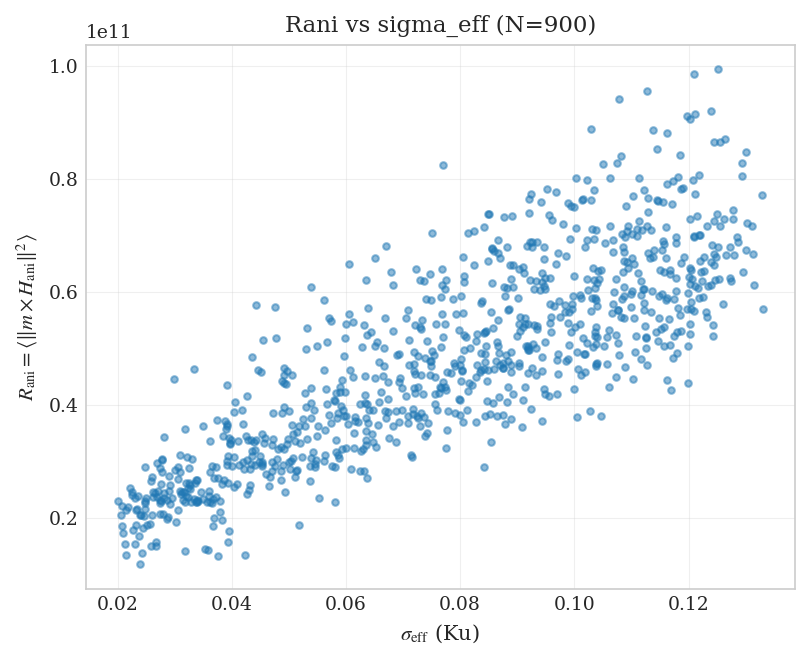

In [55]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# --- Ajusta N aquí ---
N = 900  # prueba 300 (sube a 500 si va rápido)

ds_big = MzDataset(
    csv_path=CSV_PATH,
    img_dir=IMG_DIR,
    npy_dir=NPY_DIR,
    index_col=IMG_INDEX_COL,
    transform=None,
    filter_low_D=True,
    filter_low_sigma=True,
    load_npy=True,
    max_samples=N,
    random_subset_seed=123
)

sigma_eff_list = []
sigma_label_list = []
D_list = []
Rani_list = []

for i in range(len(ds_big)):
    img, m_field, Ku_block, target, run_id = ds_big[i]
    Rani = torque_residual_anisotropy(m_field, Ku_block)
    sigma_eff = (Ku_block.float().std() / (Ku_block.float().mean() + 1e-12)).item()

    sigma_eff_list.append(sigma_eff)
    sigma_label_list.append(target[1].item())
    D_list.append(target[0].item())
    Rani_list.append(Rani)

sigma_eff_arr = np.array(sigma_eff_list, dtype=np.float64)
sigma_label_arr = np.array(sigma_label_list, dtype=np.float64)
Rani_arr = np.array(Rani_list, dtype=np.float64)

# Correlaciones
rp, _ = pearsonr(sigma_eff_arr, Rani_arr)
rs, _ = spearmanr(sigma_eff_arr, Rani_arr)

print(f"Pearson r(sigma_eff, Rani)  = {rp:.3f}")
print(f"Spearman r(sigma_eff, Rani) = {rs:.3f}")

# Scatter
plt.figure(figsize=(5.5, 4.5))
plt.scatter(sigma_eff_arr, Rani_arr, s=10, alpha=0.5)
plt.xlabel(r"$\sigma_{\rm eff}$ (Ku)")
plt.ylabel(r"$R_{\rm ani}=\langle \|m\times H_{\rm ani}\|^2\rangle$")
plt.title(f"Rani vs sigma_eff (N={len(ds_big)})")
plt.tight_layout()
plt.show()


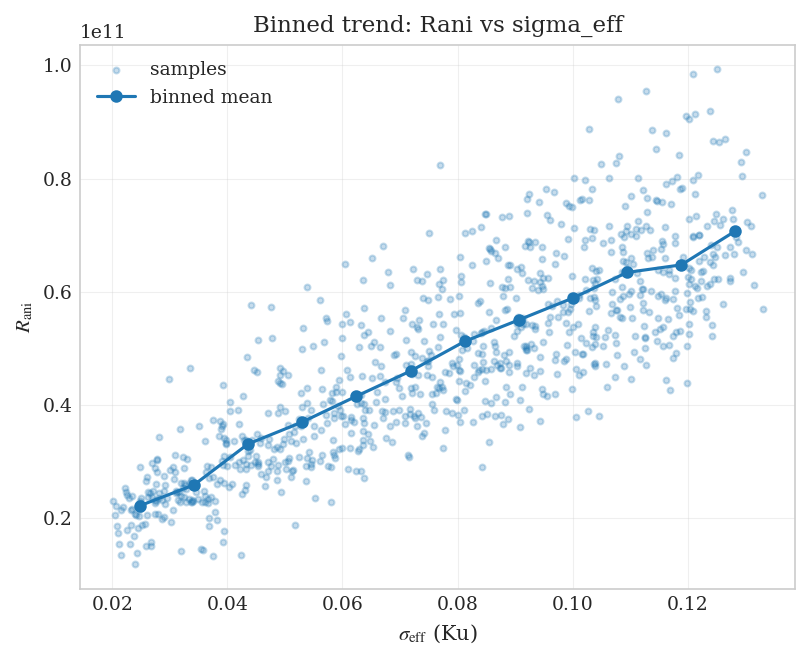

Bin counts: [65, 66, 69, 69, 77, 72, 86, 95, 88, 83, 89, 40]


In [56]:
# Binning
n_bins = 12
bins = np.linspace(sigma_eff_arr.min(), sigma_eff_arr.max(), n_bins+1)
bin_centers = 0.5*(bins[:-1] + bins[1:])
bin_means = np.full(n_bins, np.nan)
bin_counts = np.zeros(n_bins, dtype=int)

for b in range(n_bins):
    mask = (sigma_eff_arr >= bins[b]) & (sigma_eff_arr < bins[b+1])
    bin_counts[b] = mask.sum()
    if bin_counts[b] > 5:
        bin_means[b] = Rani_arr[mask].mean()

plt.figure(figsize=(5.5, 4.5))
plt.scatter(sigma_eff_arr, Rani_arr, s=8, alpha=0.25, label="samples")
plt.plot(bin_centers, bin_means, marker="o", linewidth=1.5, label="binned mean")
plt.xlabel(r"$\sigma_{\rm eff}$ (Ku)")
plt.ylabel(r"$R_{\rm ani}$")
plt.title("Binned trend: Rani vs sigma_eff")
plt.legend()
plt.tight_layout()
plt.show()

print("Bin counts:", bin_counts.tolist())


In [18]:
import torch
import math

mu0 = 4*math.pi*1e-7

def ddx(f, dx):
    # central diff, periodic-ish via roll (PBC)
    return (torch.roll(f, shifts=-1, dims=1) - torch.roll(f, shifts=1, dims=1)) / (2*dx)

def ddy(f, dy):
    return (torch.roll(f, shifts=-1, dims=0) - torch.roll(f, shifts=1, dims=0)) / (2*dy)

def laplacian(f, dx, dy):
    return (torch.roll(f,-1,1) - 2*f + torch.roll(f,1,1)) / (dx*dx) + \
           (torch.roll(f,-1,0) - 2*f + torch.roll(f,1,0)) / (dy*dy)


In [58]:
def expand_Ku_block_to_map(Ku_block, H=512, W=512):
    by, bx = Ku_block.shape
    return Ku_block.repeat_interleave(H//by, dim=0).repeat_interleave(W//bx, dim=1)


In [59]:
def heff_exchange(mx,my,mz, Aex, Msat, dx, dy):
    # H_ex = (2A / (mu0 Ms)) ∇² m
    c = 2.0 * Aex / (mu0 * Msat)
    Hx = c * laplacian(mx, dx, dy)
    Hy = c * laplacian(my, dx, dy)
    Hz = c * laplacian(mz, dx, dy)
    return Hx, Hy, Hz

def heff_anisotropy(mx,my,mz, Ku_map, Msat):
    # perpendicular uniaxial: H_ani = (2Ku/(mu0 Ms)) (m·u) u , u = zhat => (2Ku/(mu0 Ms)) mz zhat
    Hz = (2.0 * Ku_map / (mu0 * Msat)) * mz
    return torch.zeros_like(Hz), torch.zeros_like(Hz), Hz

def heff_dmi_interfacial(mx,my,mz, D, Msat, dx, dy):
    # Interfacial DMI effective field (common form):
    # H_DMI = (2D/(mu0 Ms)) [ ∂x mz, ∂y mz, -(∂x mx + ∂y my) ]
    c = 2.0 * D / (mu0 * Msat)
    Hx = c * ddx(mz, dx)
    Hy = c * ddy(mz, dy)
    Hz = -c * (ddx(mx, dx) + ddy(my, dy))
    return Hx, Hy, Hz

def torque_residual_full(m_field, Ku_block, D, Aex, Msat, dx, dy):
    mx = m_field["mx"].float()
    my = m_field["my"].float()
    mz = m_field["mz"].float()

    H, W = mz.shape
    Ku_map = expand_Ku_block_to_map(Ku_block.float(), H=H, W=W)

    Hx_ex, Hy_ex, Hz_ex = heff_exchange(mx,my,mz, Aex=Aex, Msat=Msat, dx=dx, dy=dy)
    Hx_dm, Hy_dm, Hz_dm = heff_dmi_interfacial(mx,my,mz, D=D, Msat=Msat, dx=dx, dy=dy)
    Hx_an, Hy_an, Hz_an = heff_anisotropy(mx,my,mz, Ku_map=Ku_map, Msat=Msat)

    Hx = Hx_ex + Hx_dm + Hx_an
    Hy = Hy_ex + Hy_dm + Hy_an
    Hz = Hz_ex + Hz_dm + Hz_an

    # torque = m x H
    tx = my*Hz - mz*Hy
    ty = mz*Hx - mx*Hz
    tz = mx*Hy - my*Hx
    t2 = tx*tx + ty*ty + tz*tz

    return t2.mean().item()


In [60]:
dx = 4e-9
dy = 4e-9
Aex = 3.1e-11
Msat = 1.445e6

def sweep_D_for_one(sample, rel_span=0.3, n=11):
    img, m_field, Ku_block, target, run_id = sample
    D_true = target[0].item()

    Ds = torch.linspace((1-rel_span)*D_true, (1+rel_span)*D_true, n).tolist()
    Rs = []
    for D in Ds:
        R = torque_residual_full(m_field, Ku_block, D=D, Aex=Aex, Msat=Msat, dx=dx, dy=dy)
        Rs.append(R)

    best_i = int(torch.tensor(Rs).argmin().item())
    return run_id, D_true, Ds, Rs, Ds[best_i]

# probar en 5 runs
for k in range(5):
    out = sweep_D_for_one(ds_screen[k], rel_span=0.4, n=13)
    run_id, D_true, Ds, Rs, D_best = out
    print(f"run={run_id}  D_true={D_true*1e3:.3f} mJ/m²  D_best={D_best*1e3:.3f} mJ/m²")


run=1090  D_true=0.890 mJ/m²  D_best=0.534 mJ/m²
run=1173  D_true=0.699 mJ/m²  D_best=0.420 mJ/m²
run=1214  D_true=1.497 mJ/m²  D_best=0.898 mJ/m²
run=1238  D_true=0.125 mJ/m²  D_best=0.075 mJ/m²
run=1411  D_true=0.193 mJ/m²  D_best=0.116 mJ/m²


In [61]:

import torch
import torch.nn.functional as F
import numpy as np

mu0 = 4*np.pi*1e-7

# tus valores base
Ms = 1.445e6
Aex = 3.1e-11
dx = 4e-9
dy = 4e-9


In [63]:
def normalize_m(mx, my, mz, eps=1e-12):
    m = torch.stack([mx, my, mz], dim=0)  # (3,H,W)
    norm = torch.sqrt((m*m).sum(dim=0) + eps)
    m = m / norm
    return m  # (3,H,W)

def central_diff_x(f, dx):
    # f: (H,W)
    return (torch.roll(f, shifts=-1, dims=1) - torch.roll(f, shifts=1, dims=1)) / (2*dx)

def central_diff_y(f, dy):
    return (torch.roll(f, shifts=-1, dims=0) - torch.roll(f, shifts=1, dims=0)) / (2*dy)

def laplacian_2d(f, dx, dy):
    # 5-point stencil con roll (PBC implícito)
    f_xx = (torch.roll(f, -1, 1) - 2*f + torch.roll(f, 1, 1)) / (dx*dx)
    f_yy = (torch.roll(f, -1, 0) - 2*f + torch.roll(f, 1, 0)) / (dy*dy)
    return f_xx + f_yy


In [64]:
def ku_block_to_map(Ku_block, H=512, W=512):
    """
    Ku_block: (16,16)
    retorna Ku_map: (H,W)
    """
    bx, by = Ku_block.shape  # 16,16
    assert bx == 16 and by == 16

    sx = W // bx   # 512/16 = 32
    sy = H // by   # 512/16 = 32

    # OJO: convención (y,x). Ku_block está (bx,by) o (by,bx)?
    # En tu generación escribiste loops: for bx in blocksX: for by in blocksY
    # Eso produce un orden "x-first". Aquí asumimos Ku_block[y,x] para imagen.
    # Si ves rotación, simplemente cambia el transpose.

    Ku_map = Ku_block.repeat_interleave(sy, dim=0).repeat_interleave(sx, dim=1)  # (512,512)
    return Ku_map


In [65]:
def H_exchange(m, Aex, Ms, dx, dy):
    # m: (3,H,W)
    pref = 2*Aex/(mu0*Ms)
    Hx = pref * laplacian_2d(m[0], dx, dy)
    Hy = pref * laplacian_2d(m[1], dx, dy)
    Hz = pref * laplacian_2d(m[2], dx, dy)
    return torch.stack([Hx, Hy, Hz], dim=0)


In [66]:
def H_anisotropy(m, Ku_map, Ms):
    # Ku_map: (H,W)
    pref = 2*Ku_map/(mu0*Ms)
    Hx = torch.zeros_like(Ku_map)
    Hy = torch.zeros_like(Ku_map)
    Hz = pref * m[2]
    return torch.stack([Hx, Hy, Hz], dim=0)


In [67]:
def H_dmi_interfacial(m, D, Ms, dx, dy):
    pref = 2*D/(mu0*Ms)

    dmz_dx = central_diff_x(m[2], dx)
    dmz_dy = central_diff_y(m[2], dy)

    dmx_dx = central_diff_x(m[0], dx)
    dmy_dy = central_diff_y(m[1], dy)

    Hx = pref * dmz_dx
    Hy = pref * dmz_dy
    Hz = -pref * (dmx_dx + dmy_dy)

    return torch.stack([Hx, Hy, Hz], dim=0)


In [68]:
def torque_residual_full(m_field, Ku_block, D, Ms=1.445e6, Aex=3.1e-11, dx=4e-9, dy=4e-9):
    """
    m_field: dict con mx,my,mz torch (512,512)
    Ku_block: torch (16,16)
    D: float (J/m^2)
    """
    mx = m_field['mx'].float()
    my = m_field['my'].float()
    mz = m_field['mz'].float()

    m = normalize_m(mx, my, mz)  # (3,H,W)

    Ku_map = ku_block_to_map(Ku_block.float(), H=m.shape[1], W=m.shape[2])

    Hex  = H_exchange(m, Aex, Ms, dx, dy)
    Hani = H_anisotropy(m, Ku_map, Ms)
    Hdmi = H_dmi_interfacial(m, D, Ms, dx, dy)

    Heff = Hex + Hani + Hdmi

    # torque = m x Heff
    torque = torch.cross(m.permute(1,2,0), Heff.permute(1,2,0), dim=2)  # (H,W,3)
    R = (torque**2).sum(dim=2).mean()  # escalar

    return R.item()


In [69]:
def find_best_D_full_residual(m_field, Ku_block, D_true, Ms=1.445e6, Aex=3.1e-11, dx=4e-9, dy=4e-9,
                             n_grid=25, D_min=0.3e-3, D_max=1.5e-3):
    """
    D_true en J/m^2
    """
    Ds = np.linspace(D_min, D_max, n_grid)
    Rs = []

    for D in Ds:
        R = torque_residual_full(m_field, Ku_block, D, Ms=Ms, Aex=Aex, dx=dx, dy=dy)
        Rs.append(R)

    Rs = np.array(Rs)
    idx = np.argmin(Rs)
    return Ds[idx], Ds, Rs


run_id=1  D_true=0.679 mJ/m²  D_best=0.300 mJ/m²


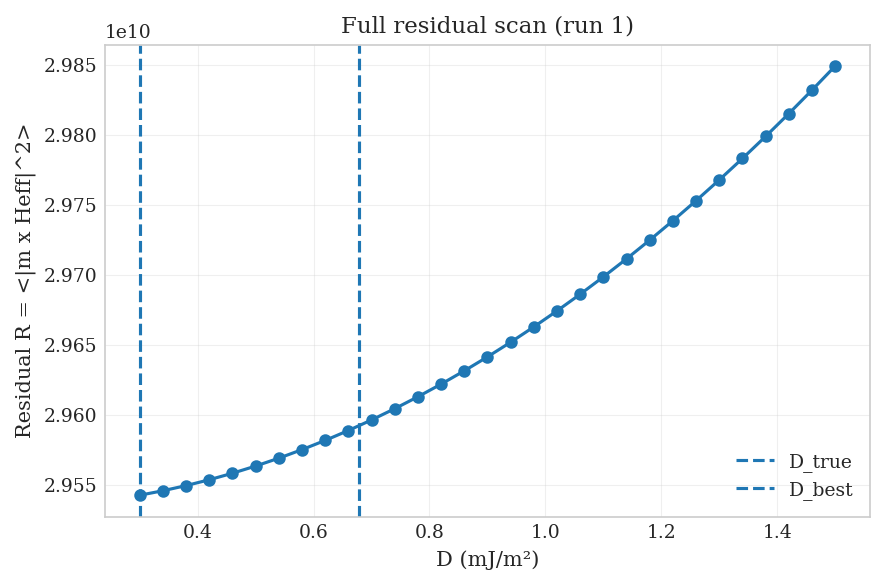

In [70]:
import matplotlib.pyplot as plt

# toma un sample del dataset
img, m_field, Ku_block, target, run_id = ds_big[0]
D_true = target[0].item()

D_best, Ds, Rs = find_best_D_full_residual(
    m_field=m_field,
    Ku_block=Ku_block,
    D_true=D_true,
    n_grid=31,
    D_min=0.3e-3,
    D_max=1.5e-3
)

print(f"run_id={run_id}  D_true={D_true*1e3:.3f} mJ/m²  D_best={D_best*1e3:.3f} mJ/m²")

plt.figure(figsize=(6,4))
plt.plot(Ds*1e3, Rs, marker='o', linewidth=1.5)
plt.axvline(D_true*1e3, linestyle='--', label="D_true")
plt.axvline(D_best*1e3, linestyle='--', label="D_best")
plt.xlabel("D (mJ/m²)")
plt.ylabel("Residual R = <|m x Heff|^2>")
plt.title(f"Full residual scan (run {run_id})")
plt.legend()
plt.tight_layout()
plt.show()


In [74]:
def quick_test_full_residual(ds, n_tests=10):
    results = []
    for i in range(n_tests):
        img, m_field, Ku_block, target, run_id = ds[i]
        D_true = target[0].item()
        D_best, Ds, Rs = find_best_D_full_residual(
            m_field=m_field,
            Ku_block=Ku_block,
            D_true=D_true,
            n_grid=31,
            D_min=0.3e-3,
            D_max=1.5e-3
        )
        results.append((run_id, D_true, D_best, Rs.min(), Rs.max()))
        print(f"[{i}] run={run_id}  D_true={D_true*1e3:.3f}  D_best={D_best*1e3:.3f}")
    return results

# usa tu dataset actual
_ = quick_test_full_residual(ds_big, n_tests=10)


[0] run=1  D_true=0.679  D_best=0.300
[1] run=1004  D_true=0.388  D_best=0.300
[2] run=1006  D_true=0.707  D_best=0.300
[3] run=1013  D_true=1.156  D_best=0.300
[4] run=1016  D_true=0.930  D_best=0.300
[5] run=1021  D_true=0.684  D_best=0.300
[6] run=1025  D_true=0.405  D_best=0.300
[7] run=1026  D_true=0.913  D_best=0.300
[8] run=1032  D_true=1.077  D_best=0.300
[9] run=1038  D_true=0.684  D_best=0.300


In [75]:
def torque_residual_terms(m_field, Ku_block, D, Ms=1.445e6, Aex=3.1e-11, dx=4e-9, dy=4e-9):
    mx = m_field['mx'].float()
    my = m_field['my'].float()
    mz = m_field['mz'].float()
    m = normalize_m(mx, my, mz)

    Ku_map = ku_block_to_map(Ku_block.float(), H=m.shape[1], W=m.shape[2])

    Hex  = H_exchange(m, Aex, Ms, dx, dy)
    Hani = H_anisotropy(m, Ku_map, Ms)
    Hdmi = H_dmi_interfacial(m, D, Ms, dx, dy)

    def R_of(H):
        torque = torch.cross(m.permute(1,2,0), H.permute(1,2,0), dim=2)
        return (torque**2).sum(dim=2).mean().item()

    R_ex  = R_of(Hex)
    R_ani = R_of(Hani)
    R_dmi = R_of(Hdmi)

    Heff = Hex + Hani + Hdmi
    R_tot = R_of(Heff)

    return R_ex, R_ani, R_dmi, R_tot


In [76]:
img, m_field, Ku_block, target, run_id = ds_big[0]
for Dtest in [0.3e-3, target[0].item(), 1.5e-3]:
    Rex, Rani, Rdmi, Rtot = torque_residual_terms(m_field, Ku_block, Dtest)
    print(f"D={Dtest*1e3:.3f} | Rex={Rex:.3e}  Rani={Rani:.3e}  Rdmi={Rdmi:.3e}  Rtot={Rtot:.3e}")


D=0.300 | Rex=1.393e+09  Rani=4.183e+10  Rdmi=1.360e+07  Rtot=2.954e+10
D=0.679 | Rex=1.393e+09  Rani=4.183e+10  Rdmi=6.967e+07  Rtot=2.959e+10
D=1.500 | Rex=1.393e+09  Rani=4.183e+10  Rdmi=3.399e+08  Rtot=2.985e+10


In [77]:
import torch

def alignment_metric(m_field, Ku_block, D, Ms=1.445e6, Aex=3.1e-11, dx=4e-9, dy=4e-9, eps=1e-12):
    mx = m_field['mx'].float()
    my = m_field['my'].float()
    mz = m_field['mz'].float()
    m = normalize_m(mx, my, mz)  # (3,H,W)

    Ku_map = ku_block_to_map(Ku_block.float(), H=m.shape[1], W=m.shape[2])

    Hex  = H_exchange(m, Aex, Ms, dx, dy)
    Hani = H_anisotropy(m, Ku_map, Ms)
    Hdmi = H_dmi_interfacial(m, D, Ms, dx, dy)

    Heff = Hex + Hani + Hdmi

    # cos(theta) = (m·Heff)/(|m||Heff|), pero |m|=1
    dot = (m * Heff).sum(dim=0)
    Heff_norm = torch.sqrt((Heff**2).sum(dim=0) + eps)

    cos = dot / (Heff_norm + eps)
    cos = torch.clamp(cos, -1.0, 1.0)

    sin2 = 1.0 - cos**2
    return sin2.mean().item(), Heff_norm.mean().item(), Heff_norm.max().item()


In [78]:
img, m_field, Ku_block, target, run_id = ds_big[0]
D_true = target[0].item()

sin2, Hmean, Hmax = alignment_metric(m_field, Ku_block, D_true)
print(f"run={run_id}  <sin^2(theta)>={sin2:.4e}  |Heff|mean={Hmean:.3e}  |Heff|max={Hmax:.3e}")


run=1  <sin^2(theta)>=3.3374e-02  |Heff|mean=1.702e+06  |Heff|max=2.019e+06


In [79]:
def alignment_metric_walls(m_field, Ku_block, D, wall_q=0.90,
                           Ms=1.445e6, Aex=3.1e-11, dx=4e-9, dy=4e-9, eps=1e-12):
    mx = m_field['mx'].float()
    my = m_field['my'].float()
    mz = m_field['mz'].float()
    m = normalize_m(mx, my, mz)

    Ku_map = ku_block_to_map(Ku_block.float(), H=m.shape[1], W=m.shape[2])

    Hex  = H_exchange(m, Aex, Ms, dx, dy)
    Hani = H_anisotropy(m, Ku_map, Ms)
    Hdmi = H_dmi_interfacial(m, D, Ms, dx, dy)
    Heff = Hex + Hani + Hdmi

    dot = (m * Heff).sum(dim=0)
    Heff_norm = torch.sqrt((Heff**2).sum(dim=0) + eps)
    cos = torch.clamp(dot / (Heff_norm + eps), -1.0, 1.0)
    sin2 = 1.0 - cos**2

    # wall mask from |grad mz|
    gz_y = mz[1:,:] - mz[:-1,:]
    gz_x = mz[:,1:] - mz[:,:-1]
    gmag = torch.sqrt(gz_x[:-1,:]**2 + gz_y[:,:-1]**2 + eps)

    thr = torch.quantile(gmag.flatten(), wall_q)
    mask = gmag >= thr

    # align shapes
    sin2_crop = sin2[:-1,:-1]

    return sin2.mean().item(), sin2_crop[mask].mean().item(), mask.float().mean().item()


In [80]:
img, m_field, Ku_block, target, run_id = ds_big[0]
for Dtest in [0.3e-3, target[0].item(), 1.5e-3]:
    s_all, s_wall, frac = alignment_metric_walls(m_field, Ku_block, Dtest, wall_q=0.90)
    print(f"D={Dtest*1e3:.3f}  sin2_all={s_all:.4e}  sin2_walls={s_wall:.4e}  wall_frac={frac:.3f}")


D=0.300  sin2_all=3.3274e-02  sin2_walls=3.2692e-01  wall_frac=0.100
D=0.679  sin2_all=3.3374e-02  sin2_walls=3.2793e-01  wall_frac=0.100
D=1.500  sin2_all=3.3855e-02  sin2_walls=3.3275e-01  wall_frac=0.100


In [81]:
import torch
import torch.fft as fft
import numpy as np

class DemagField:
    """
    Calcula H_demag para película delgada con PBC en x,y.
    Basado en el método de MuMax3 (Newell formulas + FFT).
    """
    def __init__(self, nx, ny, nz, dx, dy, dz, Ms, device='cuda'):
        self.nx, self.ny, self.nz = nx, ny, nz
        self.dx, self.dy, self.dz = dx, dy, dz
        self.Ms = Ms
        self.device = device
        
        # Precalcular tensor demagnetizante en espacio k
        self.Nk = self._compute_demag_tensor_k()
    
    def _compute_demag_tensor_k(self):
        """
        Para película delgada (nz=1) con PBC, el tensor simplifica.
        Componentes principales: Nxx, Nyy, Nzz, Nxy (otros ~0 por simetría).
        """
        # Frecuencias espaciales
        kx = fft.fftfreq(self.nx, self.dx).to(self.device) * 2 * np.pi
        ky = fft.fftfreq(self.ny, self.dy).to(self.device) * 2 * np.pi
        KX, KY = torch.meshgrid(kx, ky, indexing='ij')
        
        k2 = KX**2 + KY**2 + 1e-10  # evitar div/0
        k = torch.sqrt(k2)
        t = self.dz  # espesor de celda
        
        # Para película delgada, aproximación analítica:
        # Nzz(k) ≈ 1 - (1 - exp(-k*t))/(k*t)  para k≠0
        # Nxx(k) + Nyy(k) + Nzz(k) = 1
        
        # Factor de forma para película delgada
        kt = k * t
        Nzz = torch.ones_like(k2)
        mask = kt > 1e-6
        Nzz[mask] = 1 - (1 - torch.exp(-kt[mask])) / kt[mask]
        Nzz[0, 0] = 1.0  # k=0: película infinita, Nzz=1
        
        # Distribución en plano según dirección de k
        Nxx = (1 - Nzz) * KX**2 / k2
        Nyy = (1 - Nzz) * KY**2 / k2
        Nxy = (1 - Nzz) * KX * KY / k2
        
        # Manejar k=0
        Nxx[0, 0] = 0.0
        Nyy[0, 0] = 0.0
        Nxy[0, 0] = 0.0
        
        return {
            'Nxx': Nxx, 'Nyy': Nyy, 'Nzz': Nzz,
            'Nxy': Nxy, 'Nxz': torch.zeros_like(Nzz), 'Nyz': torch.zeros_like(Nzz)
        }
    
    def compute(self, mx, my, mz):
        """
        Calcula H_demag dado m = (mx, my, mz) cada uno de shape [nx, ny].
        Retorna Hx, Hy, Hz en A/m.
        """
        # FFT de magnetización
        Mx_k = fft.fft2(mx * self.Ms)
        My_k = fft.fft2(my * self.Ms)
        Mz_k = fft.fft2(mz * self.Ms)
        
        # H_demag = -N · M en espacio k
        Hx_k = -(self.Nk['Nxx'] * Mx_k + self.Nk['Nxy'] * My_k + self.Nk['Nxz'] * Mz_k)
        Hy_k = -(self.Nk['Nxy'] * Mx_k + self.Nk['Nyy'] * My_k + self.Nk['Nyz'] * Mz_k)
        Hz_k = -(self.Nk['Nxz'] * Mx_k + self.Nk['Nyz'] * My_k + self.Nk['Nzz'] * Mz_k)
        
        # IFFT para obtener campo real
        Hx = fft.ifft2(Hx_k).real
        Hy = fft.ifft2(Hy_k).real
        Hz = fft.ifft2(Hz_k).real
        
        return Hx, Hy, Hz

In [84]:
import re
import numpy as np
import torch
import torch.fft as fft
import matplotlib.pyplot as plt

mu0 = 4 * np.pi * 1e-7

# ---------------------------
# 1) Parse Ku_blocks desde .mx3
# ---------------------------
def parse_ku_from_mx3(mx3_path, blocksX=16, blocksY=16, device="cuda"):
    """
    Extrae los valores de Ku1.SetRegion(regionID, Ku) del archivo .mx3.
    Asume que el generador recorrió:
        for bx in range(blocksX):
            for by in range(blocksY):
                Ku1.SetRegion(regionID, Ku_val)

    Retorna:
        Ku_block: torch.Tensor [blocksX, blocksY] (float32) en device
    """
    text = open(mx3_path, "r", encoding="utf-8", errors="ignore").read()
    # captura floats después de Ku1.SetRegion(regionID, ...)
    vals = re.findall(r"Ku1\.SetRegion\(\s*regionID\s*,\s*([0-9eE\+\-\.]+)\s*\)", text)
    if len(vals) < blocksX * blocksY:
        raise ValueError(f"Se esperaban {blocksX*blocksY} Ku, pero encontré {len(vals)} en {mx3_path}")

    vals = np.array(vals[:blocksX*blocksY], dtype=np.float64)

    # Orden coherente con tu write_mx3_with_regions:
    # bx externo (lento), by interno (rápido) -> reshape (blocksX, blocksY) en C-order es correcto.
    Ku = torch.tensor(vals, dtype=torch.float32, device=device).view(blocksX, blocksY)

    return Ku


def ku_blocks_to_map(Ku_block, nx=512, ny=512):
    """
    Convierte Ku_block [blocksX, blocksY] a Ku_map [nx, ny] por 'repeat' (bloques constantes).
    OJO: Si queda transpuesto por convención, cambia a Ku_block.T
    """
    blocksX, blocksY = Ku_block.shape
    sx = nx // blocksX
    sy = ny // blocksY
    Ku_map = Ku_block.repeat_interleave(sx, dim=0).repeat_interleave(sy, dim=1)
    return Ku_map


# ---------------------------
# 2) Derivadas finitas con PBC
# ---------------------------
def ddx(f, dx):
    return (torch.roll(f, shifts=-1, dims=0) - torch.roll(f, shifts=1, dims=0)) / (2.0 * dx)

def ddy(f, dy):
    return (torch.roll(f, shifts=-1, dims=1) - torch.roll(f, shifts=1, dims=1)) / (2.0 * dy)

def laplacian(f, dx, dy):
    f_xx = (torch.roll(f, -1, 0) - 2*f + torch.roll(f, 1, 0)) / (dx*dx)
    f_yy = (torch.roll(f, -1, 1) - 2*f + torch.roll(f, 1, 1)) / (dy*dy)
    return f_xx + f_yy


# ---------------------------
# 3) Campos efectivos (A/m) consistentes con m reducido
# ---------------------------
def compute_exchange(mx, my, mz, Aex, Ms, dx, dy):
    # H_ex = (2A / (mu0 Ms)) ∇² m
    pref = 2.0 * Aex / (mu0 * Ms)
    Hx = pref * laplacian(mx, dx, dy)
    Hy = pref * laplacian(my, dx, dy)
    Hz = pref * laplacian(mz, dx, dy)
    return Hx, Hy, Hz


def compute_anisotropy(mx, my, mz, Ku_map, Ms):
    # Uniaxial eje z: H_ani = (2Ku/(mu0 Ms)) (m·z) z = (2Ku/(mu0 Ms)) mz zhat
    pref = 2.0 * Ku_map / (mu0 * Ms)
    Hx = torch.zeros_like(mz)
    Hy = torch.zeros_like(mz)
    Hz = pref * mz
    return Hx, Hy, Hz


def compute_dmi_interfacial(mx, my, mz, D, Ms, dx, dy):
    """
    DMI interfacial (Néel) en película delgada.
    Un formulario estándar del campo efectivo:
      H_DMI = (2D/(mu0 Ms)) [ ∂x m_z, ∂y m_z, -(∂x m_x + ∂y m_y) ]
    """
    pref = 2.0 * D / (mu0 * Ms)
    dmx_dx = ddx(mx, dx)
    dmy_dy = ddy(my, dy)
    dmz_dx = ddx(mz, dx)
    dmz_dy = ddy(mz, dy)

    Hx = pref * dmz_dx
    Hy = pref * dmz_dy
    Hz = -pref * (dmx_dx + dmy_dy)
    return Hx, Hy, Hz


# ---------------------------
# 4) Demag (thin-film en k) + FFT
# ---------------------------
class DemagField:
    """
    Aproximación thin-film (nz=1) con PBC en x,y usando kernel en k.
    Devuelve H_demag en A/m.
    """
    def __init__(self, nx, ny, dx, dy, dz, Ms, device="cuda"):
        self.nx, self.ny = nx, ny
        self.dx, self.dy, self.dz = dx, dy, dz
        self.Ms = Ms
        self.device = device
        self.Nk = self._compute_demag_tensor_k()

    def _compute_demag_tensor_k(self):
        kx = fft.fftfreq(self.nx, d=self.dx, device=self.device) * 2 * np.pi
        ky = fft.fftfreq(self.ny, d=self.dy, device=self.device) * 2 * np.pi
        KX, KY = torch.meshgrid(kx, ky, indexing="ij")

        k2 = KX**2 + KY**2 + 1e-30
        k = torch.sqrt(k2)
        t = self.dz
        kt = k * t

        Nzz = torch.ones_like(k)
        mask = kt > 1e-6
        Nzz[mask] = 1.0 - (1.0 - torch.exp(-kt[mask])) / (kt[mask])

        # modo k=0: película infinita -> Nzz=1, Nxx=Nyy=0
        Nzz[0, 0] = 1.0

        Nxx = (1.0 - Nzz) * (KX**2 / k2)
        Nyy = (1.0 - Nzz) * (KY**2 / k2)
        Nxy = (1.0 - Nzz) * (KX * KY / k2)

        Nxx[0, 0] = 0.0
        Nyy[0, 0] = 0.0
        Nxy[0, 0] = 0.0

        return {"Nxx": Nxx, "Nyy": Nyy, "Nzz": Nzz, "Nxy": Nxy}

    @torch.no_grad()
    def compute(self, mx, my, mz):
        # magnetización real: M = Ms * m
        Mx_k = fft.fft2(mx * self.Ms)
        My_k = fft.fft2(my * self.Ms)
        Mz_k = fft.fft2(mz * self.Ms)

        Hx_k = -(self.Nk["Nxx"] * Mx_k + self.Nk["Nxy"] * My_k)
        Hy_k = -(self.Nk["Nxy"] * Mx_k + self.Nk["Nyy"] * My_k)
        Hz_k = -(self.Nk["Nzz"] * Mz_k)

        Hx = fft.ifft2(Hx_k).real
        Hy = fft.ifft2(Hy_k).real
        Hz = fft.ifft2(Hz_k).real
        return Hx, Hy, Hz


# ---------------------------
# 5) Residual de torque y escaneo en D
# ---------------------------
@torch.no_grad()
def torque_residual(mx, my, mz, Hx, Hy, Hz):
    # tau = m x H
    tx = my * Hz - mz * Hy
    ty = mz * Hx - mx * Hz
    tz = mx * Hy - my * Hx
    return (tx*tx + ty*ty + tz*tz).mean().item()


@torch.no_grad()
def scan_D_residual(run_dir,
                    D_true,
                    Ms=1.445e6,
                    Aex=3.1e-11,
                    dx=4e-9, dy=4e-9, dz=0.9e-9,
                    blocksX=16, blocksY=16,
                    D_min=0.3e-3, D_max=1.5e-3, n=41,
                    device="cuda",
                    mx3_filename=None,
                    npy_filename=None):

    # --- localizar archivos ---
    run_dir = str(run_dir)

    if mx3_filename is None:
        # toma el primer .mx3 en la carpeta
        import glob, os
        mx3s = sorted(glob.glob(os.path.join(run_dir, "*.mx3")))
        if not mx3s:
            raise FileNotFoundError(f"No hay .mx3 en {run_dir}")
        mx3_path = mx3s[0]
    else:
        import os
        mx3_path = os.path.join(run_dir, mx3_filename)

    if npy_filename is None:
        import glob, os
        npys = sorted(glob.glob(os.path.join(run_dir, "*.npy")))
        if not npys:
            raise FileNotFoundError(f"No hay .npy en {run_dir}")
        npy_path = npys[0]
    else:
        import os
        npy_path = os.path.join(run_dir, npy_filename)

    # --- usa TU loader existente ---
    # Debe devolver dict {'mx','my','mz'} arrays [512,512] float32
    m_field = load_magnetization_from_npy(npy_path)

    mx = torch.tensor(m_field["mx"], dtype=torch.float32, device=device)
    my = torch.tensor(m_field["my"], dtype=torch.float32, device=device)
    mz = torch.tensor(m_field["mz"], dtype=torch.float32, device=device)

    # --- Ku ---
    Ku_block = parse_ku_from_mx3(mx3_path, blocksX=blocksX, blocksY=blocksY, device=device)
    Ku_map = ku_blocks_to_map(Ku_block, nx=mx.shape[0], ny=mx.shape[1])

    # --- demag precompute ---
    demag = DemagField(nx=mx.shape[0], ny=mx.shape[1],
                       dx=dx, dy=dy, dz=dz, Ms=Ms, device=device)

    Ds = torch.linspace(D_min, D_max, steps=n, device=device)
    Rs = []

    for D in Ds:
        Hx_ex, Hy_ex, Hz_ex = compute_exchange(mx, my, mz, Aex=Aex, Ms=Ms, dx=dx, dy=dy)
        Hx_an, Hy_an, Hz_an = compute_anisotropy(mx, my, mz, Ku_map=Ku_map, Ms=Ms)
        Hx_dm, Hy_dm, Hz_dm = compute_dmi_interfacial(mx, my, mz, D=float(D.item()), Ms=Ms, dx=dx, dy=dy)
        Hx_de, Hy_de, Hz_de = demag.compute(mx, my, mz)

        Hx = Hx_ex + Hx_an + Hx_dm + Hx_de
        Hy = Hy_ex + Hy_an + Hy_dm + Hy_de
        Hz = Hz_ex + Hz_an + Hz_dm + Hz_de

        R = torque_residual(mx, my, mz, Hx, Hy, Hz)
        Rs.append(R)

    Ds_cpu = Ds.detach().cpu().numpy()
    Rs_cpu = np.array(Rs, dtype=np.float64)

    D_best = Ds_cpu[np.argmin(Rs_cpu)]

    # --- plot ---
    plt.figure(figsize=(9, 4.5))
    plt.plot(Ds_cpu*1e3, Rs_cpu, "o-", lw=2)
    plt.axvline(D_true*1e3, color="r", ls="--", label=f"D_true={D_true*1e3:.3f} mJ/m²")
    plt.axvline(D_best*1e3, color="k", ls="--", label=f"D_best={D_best*1e3:.3f} mJ/m²")
    plt.xlabel("D (mJ/m²)")
    plt.ylabel(r"$\langle |m \times H_{eff}|^2 \rangle$")
    plt.title("Torque residual scan with demag + exch + ani + DMI")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"D_true = {D_true*1e3:.3f} mJ/m²")
    print(f"D_best = {D_best*1e3:.3f} mJ/m²")
    if D_true > 0:
        print(f"Error = {abs(D_best - D_true)/D_true * 100:.1f}%")

    return Ds_cpu, Rs_cpu, D_best


In [89]:
import torch

def compute_dmi(mx, my, mz, D, Ms, dx=4e-9, dy=4e-9, eps=1e-12):
    """
    Interfacial DMI effective field (Néel-type):
    Hx =  (2D/(mu0*Ms)) * (∂mz/∂x)
    Hy =  (2D/(mu0*Ms)) * (∂mz/∂y)
    Hz = -(2D/(mu0*Ms)) * (∂mx/∂x + ∂my/∂y)

    Returns Hx,Hy,Hz in A/m
    """
    mu0 = 4 * torch.pi * 1e-7

    # periodic central differences using roll
    dmz_dx = (torch.roll(mz, shifts=-1, dims=0) - torch.roll(mz, shifts=1, dims=0)) / (2*dx)
    dmz_dy = (torch.roll(mz, shifts=-1, dims=1) - torch.roll(mz, shifts=1, dims=1)) / (2*dy)

    dmx_dx = (torch.roll(mx, shifts=-1, dims=0) - torch.roll(mx, shifts=1, dims=0)) / (2*dx)
    dmy_dy = (torch.roll(my, shifts=-1, dims=1) - torch.roll(my, shifts=1, dims=1)) / (2*dy)

    pref = (2 * D) / (mu0 * Ms + eps)

    Hx = pref * dmz_dx
    Hy = pref * dmz_dy
    Hz = -pref * (dmx_dx + dmy_dy)

    return Hx, Hy, Hz


In [110]:
def test_demag_implementation_from_sample(m_field, Ku_blocks, D_true, params,
                                         dx=4e-9, dy=4e-9, dz=0.9e-9,
                                         device="cuda",
                                         D_min=0.3e-3, D_max=1.5e-3, n=50):
    """
    Verificar si con H_eff completo (exch+ani+dmi+demag),
    el torque residual tiene mínimo cerca de D_true.
    """

    # === extrae mx,my,mz desde tu dict ===
    mx = m_field["mx"].to(device).float()
    my = m_field["my"].to(device).float()
    mz = m_field["mz"].to(device).float()

    # Ku_blocks: [16,16] -> lo que uses en tu anisotropía
    Ku_blocks = Ku_blocks.to(device).float()

    # Inicializar demag
    demag = DemagField(
        nx=mx.shape[0], ny=mx.shape[1],
        dx=dx, dy=dy, dz=dz,
        Ms=params["Ms"],
        device=device
    )

    def compute_full_Heff(D):
        Hx_ex, Hy_ex, Hz_ex = compute_exchange(mx=mx, my=my, mz=mz, Aex=params["Aex"], Ms=params["Ms"], dx=dx, dy=dy)
        Hx_ani, Hy_ani, Hz_ani = compute_anisotropy(mx=mx, my=my, mz=mz,Ku_map=ku_blocks_to_map(Ku_blocks), Ms=params["Ms"])
        Hx_dmi, Hy_dmi, Hz_dmi = compute_dmi(mx=mx, my=my, mz=mz, D=D, Ms=params["Ms"], dx=dx, dy=dy)
        Hx_dem, Hy_dem, Hz_dem = demag.compute(mx=mx, my=my, mz=mz)

        return (
            Hx_ex + Hx_ani + Hx_dmi + Hx_dem,
            Hy_ex + Hy_ani + Hy_dmi + Hy_dem,
            Hz_ex + Hz_ani + Hz_dmi + Hz_dem
        )

    def torque_residual(D):
        Hx, Hy, Hz = compute_full_Heff(D)
        tau_x = my * Hz - mz * Hy
        tau_y = mz * Hx - mx * Hz
        tau_z = mx * Hy - my * Hx
        return (tau_x**2 + tau_y**2 + tau_z**2).mean().item()

    # Escanear D
    D_range = np.linspace(D_min, D_max, n)
    residuals = [torque_residual(D) for D in D_range]

    # Plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(D_range * 1e3, residuals, marker="o", lw=2)
    plt.axvline(D_true * 1e3, color="r", ls="--", label=f"D_true = {D_true*1e3:.3f} mJ/m²")
    plt.xlabel("D (mJ/m²)")
    plt.ylabel(r"Torque residual $\langle |m \times H_{eff}|^2 \rangle$")
    plt.legend()
    plt.title("Torque residual scan with demag + exch + ani + DMI")
    plt.show()

    D_best = D_range[np.argmin(residuals)]
    print(f"D_true = {D_true*1e3:.3f} mJ/m²")
    print(f"D_best = {D_best*1e3:.3f} mJ/m²")
    print(f"Error = {abs(D_best - D_true)/D_true * 100:.1f}%")

    return D_range, residuals, D_best


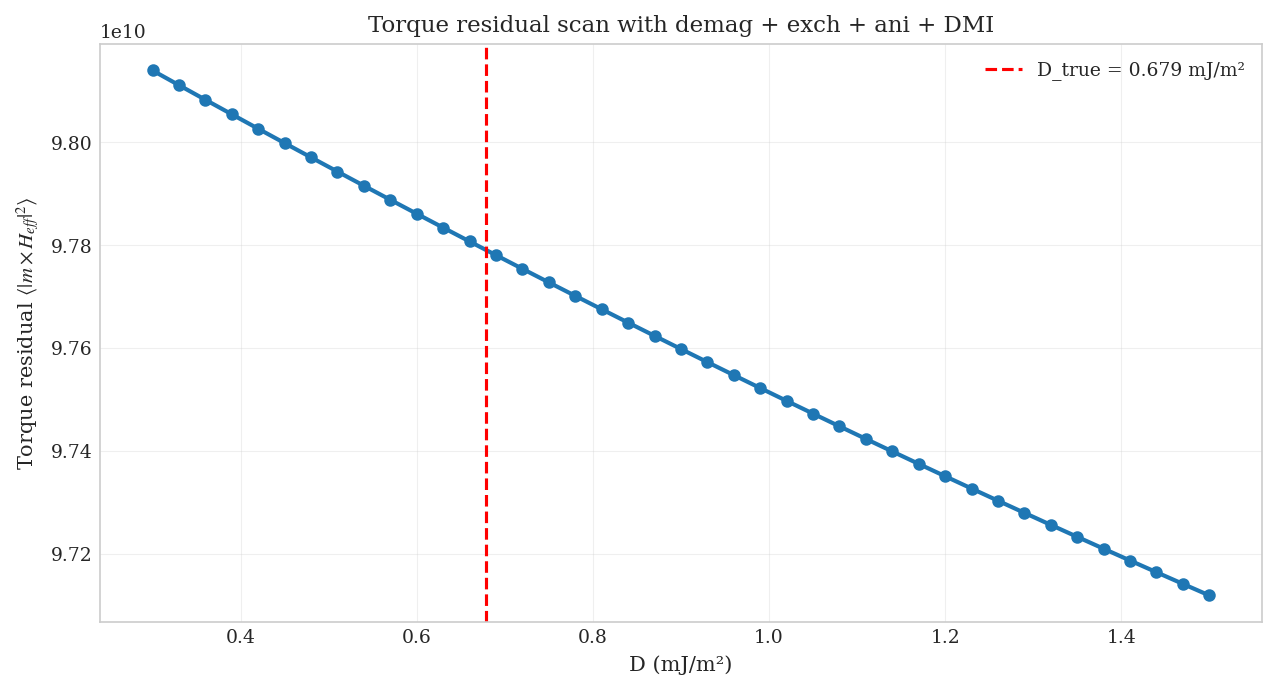

D_true = 0.679 mJ/m²
D_best = 1.500 mJ/m²
Error = 120.9%


In [111]:
img, m_field, Ku_block, target, run_id = ds_big[0]
D_true = target[0].item()

params = {
    "Ms": 1.445e6,
    "Aex": 3.1e-11
}

Ds, Rs, D_best = test_demag_implementation_from_sample(
    m_field=m_field,
    Ku_blocks=Ku_block,
    D_true=D_true,
    params=params,
    device="cuda",
    n=41
)


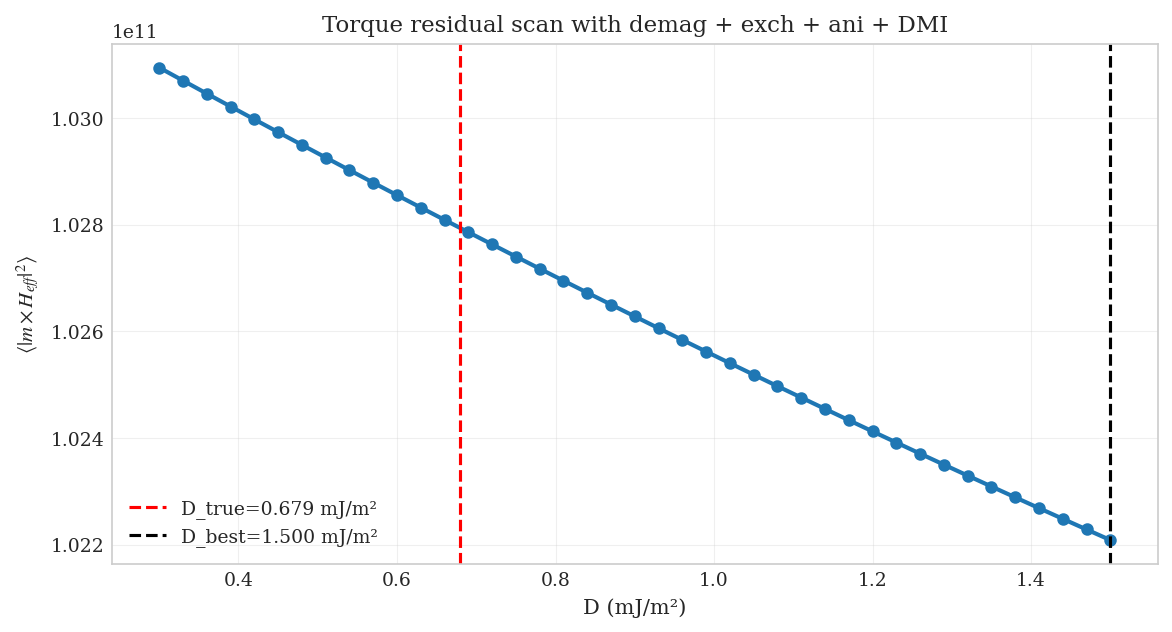

D_true = 0.679 mJ/m²
D_best = 1.500 mJ/m²
Error = 120.9%


In [91]:
run_dir = "../mumax_dataset_ku_by_block_disorder_phy_corrected_3/run_03078"
D_true = 0.000679  # J/m²

Ds, Rs, D_best = scan_D_residual(
    run_dir=run_dir,
    D_true=D_true,
    Ms=1.445e6,
    Aex=3.1e-11,
    dx=4e-9, dy=4e-9, dz=0.9e-9,
    D_min=0.3e-3, D_max=1.5e-3, n=41,
    device="cuda"
)


D=0.300 mJ/m²  |H_dmi|mean=1.831e+03  |H_dmi|max=6.370e+04
D=0.386 mJ/m²  |H_dmi|mean=2.355e+03  |H_dmi|max=8.190e+04
D=0.471 mJ/m²  |H_dmi|mean=2.878e+03  |H_dmi|max=1.001e+05
D=0.557 mJ/m²  |H_dmi|mean=3.401e+03  |H_dmi|max=1.183e+05
D=0.643 mJ/m²  |H_dmi|mean=3.925e+03  |H_dmi|max=1.365e+05
D=0.729 mJ/m²  |H_dmi|mean=4.448e+03  |H_dmi|max=1.547e+05
D=0.814 mJ/m²  |H_dmi|mean=4.971e+03  |H_dmi|max=1.729e+05
D=0.900 mJ/m²  |H_dmi|mean=5.494e+03  |H_dmi|max=1.911e+05
D=0.986 mJ/m²  |H_dmi|mean=6.018e+03  |H_dmi|max=2.093e+05
D=1.071 mJ/m²  |H_dmi|mean=6.541e+03  |H_dmi|max=2.275e+05
D=1.157 mJ/m²  |H_dmi|mean=7.064e+03  |H_dmi|max=2.457e+05
D=1.243 mJ/m²  |H_dmi|mean=7.588e+03  |H_dmi|max=2.639e+05
D=1.329 mJ/m²  |H_dmi|mean=8.111e+03  |H_dmi|max=2.821e+05
D=1.414 mJ/m²  |H_dmi|mean=8.634e+03  |H_dmi|max=3.003e+05
D=1.500 mJ/m²  |H_dmi|mean=9.158e+03  |H_dmi|max=3.185e+05


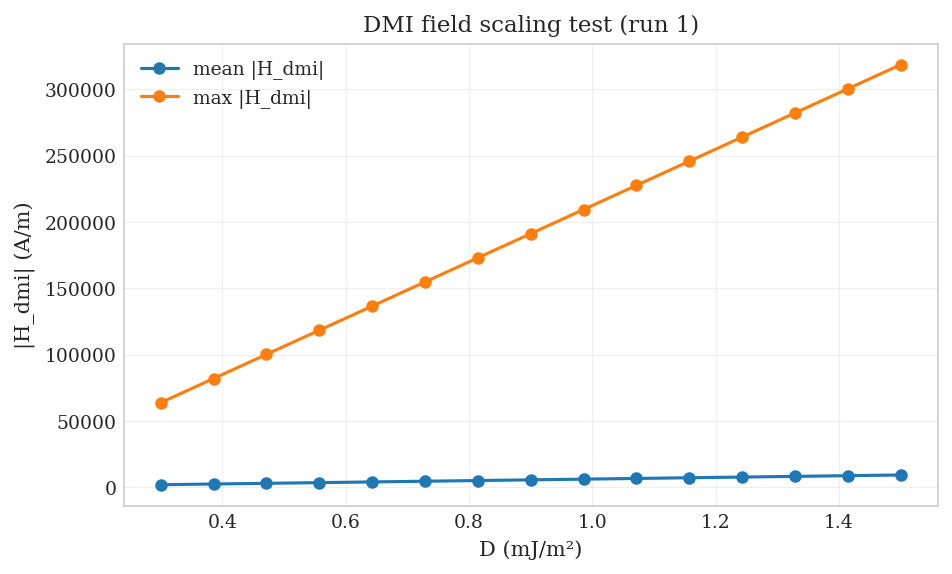

In [112]:
import numpy as np
import matplotlib.pyplot as plt

def dmi_norm_test(m_field, Ku_block, Ms, D_list):
    mx = m_field["mx"]
    my = m_field["my"]
    mz = m_field["mz"]

    Hnorm_mean = []
    Hnorm_max  = []

    for D in D_list:
        Hx_dmi, Hy_dmi, Hz_dmi = compute_dmi(mx, my, mz, D, Ms)

        Hnorm = torch.sqrt(Hx_dmi**2 + Hy_dmi**2 + Hz_dmi**2)

        Hnorm_mean.append(Hnorm.mean().item())
        Hnorm_max.append(Hnorm.max().item())

        print(f"D={D*1e3:.3f} mJ/m²  |H_dmi|mean={Hnorm_mean[-1]:.3e}  |H_dmi|max={Hnorm_max[-1]:.3e}")

    return np.array(Hnorm_mean), np.array(Hnorm_max)

# --- ejecutar en un sample ---
img, m_field, Ku_block, target, run_id = ds_big[0]
Ms = 1.445e6

D_list = np.linspace(0.3e-3, 1.5e-3, 15)

Hmean, Hmax = dmi_norm_test(m_field, Ku_block, Ms, D_list)

plt.figure(figsize=(7,4))
plt.plot(D_list*1e3, Hmean, marker="o", label="mean |H_dmi|")
plt.plot(D_list*1e3, Hmax, marker="o", label="max |H_dmi|")
plt.xlabel("D (mJ/m²)")
plt.ylabel("|H_dmi| (A/m)")
plt.title(f"DMI field scaling test (run {run_id})")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def diagnose_field_balance(mx, my, mz, Ku_blocks, params):
    """
    Verificar si los campos están balanceados en el bulk.
    """
    Ms = params['Ms']
    mu0 = 4 * np.pi * 1e-7
    
    # En bulk de dominios (|mz| > 0.95)
    bulk_mask = torch.abs(mz) > 0.95
    
    # Campo de anisotropía (z-component en bulk)
    Ku_upsampled = upsample_Ku(Ku_blocks, 512, 512)
    Hz_ani = 2 * Ku_upsampled / (mu0 * Ms) * mz  # A/m
    
    # Campo demag (z-component)
    _, _, Hz_demag = demag.compute(mx, my, mz)
    
    # En equilibrio deberían casi cancelarse
    Hz_total = Hz_ani + Hz_demag  # Solo estos dos en bulk
    
    print("=== Diagnóstico en bulk de dominios ===")
    print(f"⟨Hz_ani⟩   = {Hz_ani[bulk_mask].mean():.3e} A/m")
    print(f"⟨Hz_demag⟩ = {Hz_demag[bulk_mask].mean():.3e} A/m")
    print(f"⟨Hz_total⟩ = {Hz_total[bulk_mask].mean():.3e} A/m")
    print(f"Ratio |Hz_demag/Hz_ani| = {abs(Hz_demag[bulk_mask].mean()/Hz_ani[bulk_mask].mean()):.3f}")
    
    # Valores esperados teóricos
    Hz_demag_teorico = -Ms  # ≈ -1.445e6 A/m para mz=+1
    Ku_mean = Ku_blocks.mean()
    Hz_ani_teorico = 2 * Ku_mean / (mu0 * Ms)  # ≈ 1.76e6 A/m
    
    print(f"\n=== Valores teóricos esperados ===")
    print(f"Hz_demag teórico ≈ {Hz_demag_teorico:.3e} A/m")
    print(f"Hz_ani teórico   ≈ {Hz_ani_teorico:.3e} A/m")
    
    return Hz_ani, Hz_demag

In [113]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def wall_mask_from_mz(mz, thr=0.90):
    """
    Paredes ~ donde |mz| < thr.
    mz: tensor [nx, ny]
    """
    return (mz.abs() < thr)


In [114]:
def dmi_torque_test(m_field, Ms, D_list, dx=4e-9, dy=4e-9, device="cuda", wall_thr=0.90):
    """
    Retorna:
      D_list, T_all(D), T_walls(D), wall_frac
    """

    mx = m_field["mx"].to(device).float()
    my = m_field["my"].to(device).float()
    mz = m_field["mz"].to(device).float()

    mask_walls = wall_mask_from_mz(mz, thr=wall_thr)
    wall_frac = mask_walls.float().mean().item()

    T_all = []
    T_walls = []

    for D in D_list:
        # DMI field
        Hx, Hy, Hz = compute_dmi(mx, my, mz, D, Ms, dx=dx, dy=dy)

        # torque tau = m x H
        tau_x = my * Hz - mz * Hy
        tau_y = mz * Hx - mx * Hz
        tau_z = mx * Hy - my * Hx

        tau2 = tau_x**2 + tau_y**2 + tau_z**2

        T_all.append(tau2.mean().item())

        # walls only
        if mask_walls.any():
            T_walls.append(tau2[mask_walls].mean().item())
        else:
            T_walls.append(np.nan)

    return np.array(D_list), np.array(T_all), np.array(T_walls), wall_frac


run_id=1  wall_frac=0.059


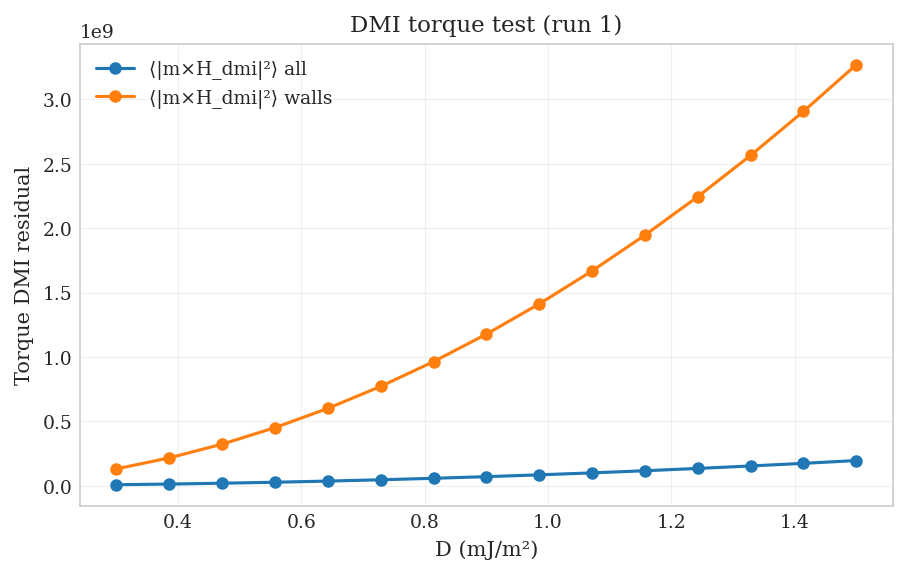

In [115]:
# toma un sample
img, m_field, Ku_block, target, run_id = ds_big[0]

Ms = 1.445e6
D_list = np.linspace(0.3e-3, 1.5e-3, 15)

Ds, T_all, T_walls, wall_frac = dmi_torque_test(
    m_field=m_field,
    Ms=Ms,
    D_list=D_list,
    dx=4e-9, dy=4e-9,
    device="cuda",
    wall_thr=0.90
)

print(f"run_id={run_id}  wall_frac={wall_frac:.3f}")

plt.figure(figsize=(7,4))
plt.plot(Ds*1e3, T_all, marker="o", label="⟨|m×H_dmi|²⟩ all")
plt.plot(Ds*1e3, T_walls, marker="o", label="⟨|m×H_dmi|²⟩ walls")
plt.xlabel("D (mJ/m²)")
plt.ylabel("Torque DMI residual")
plt.title(f"DMI torque test (run {run_id})")
plt.legend()
plt.show()


Cargando dataset...
[MzDataset] Loaded 2356 samples from ../images/corrected_3
  Filtered 483 samples with D < 0.3 mJ/m²
  Filtered 235 samples with σ < 0.02
  D range: [0.30, 1.50] mJ/m²
  σ range: [0.020, 0.142]

SANITY TEST: Métricas Físicas para PINN
Analizando 200 muestras...


100%|██████████| 200/200 [00:15<00:00, 12.97it/s]



CORRELACIONES CON D
chirality_mean           : r = -0.222  (p = 1.58e-03) **
chirality_std            : r = +0.151  (p = 3.24e-02) *
chirality_consistency    : r = -0.065  (p = 3.60e-01) 
inplane_at_walls         : r = +0.262  (p = 1.74e-04) ***
dominant_freq            : r = -0.160  (p = 2.33e-02) *
correlation_length       : r = -0.362  (p = 1.42e-07) ***
spectral_width           : r = +0.358  (p = 1.95e-07) ***
total_wall_length        : r = +0.308  (p = 9.31e-06) ***

CORRELACIONES CON σ
corr_Ku_mz_abs           : r = +0.076  (p = 2.86e-01) 
corr_Ku_var              : r = -0.092  (p = 1.94e-01) 
texture_variation        : r = +0.636  (p = 4.65e-24) ***
sigma_eff_Ku             : r = +1.000  (p = 0.00e+00) ***
mz_spatial_std           : r = +0.084  (p = 2.35e-01) 
mz_var_mean              : r = +0.791  (p = 3.88e-44) ***
wall_density             : r = +0.272  (p = 9.78e-05) ***
spectral_width           : r = +0.787  (p = 2.41e-43) ***


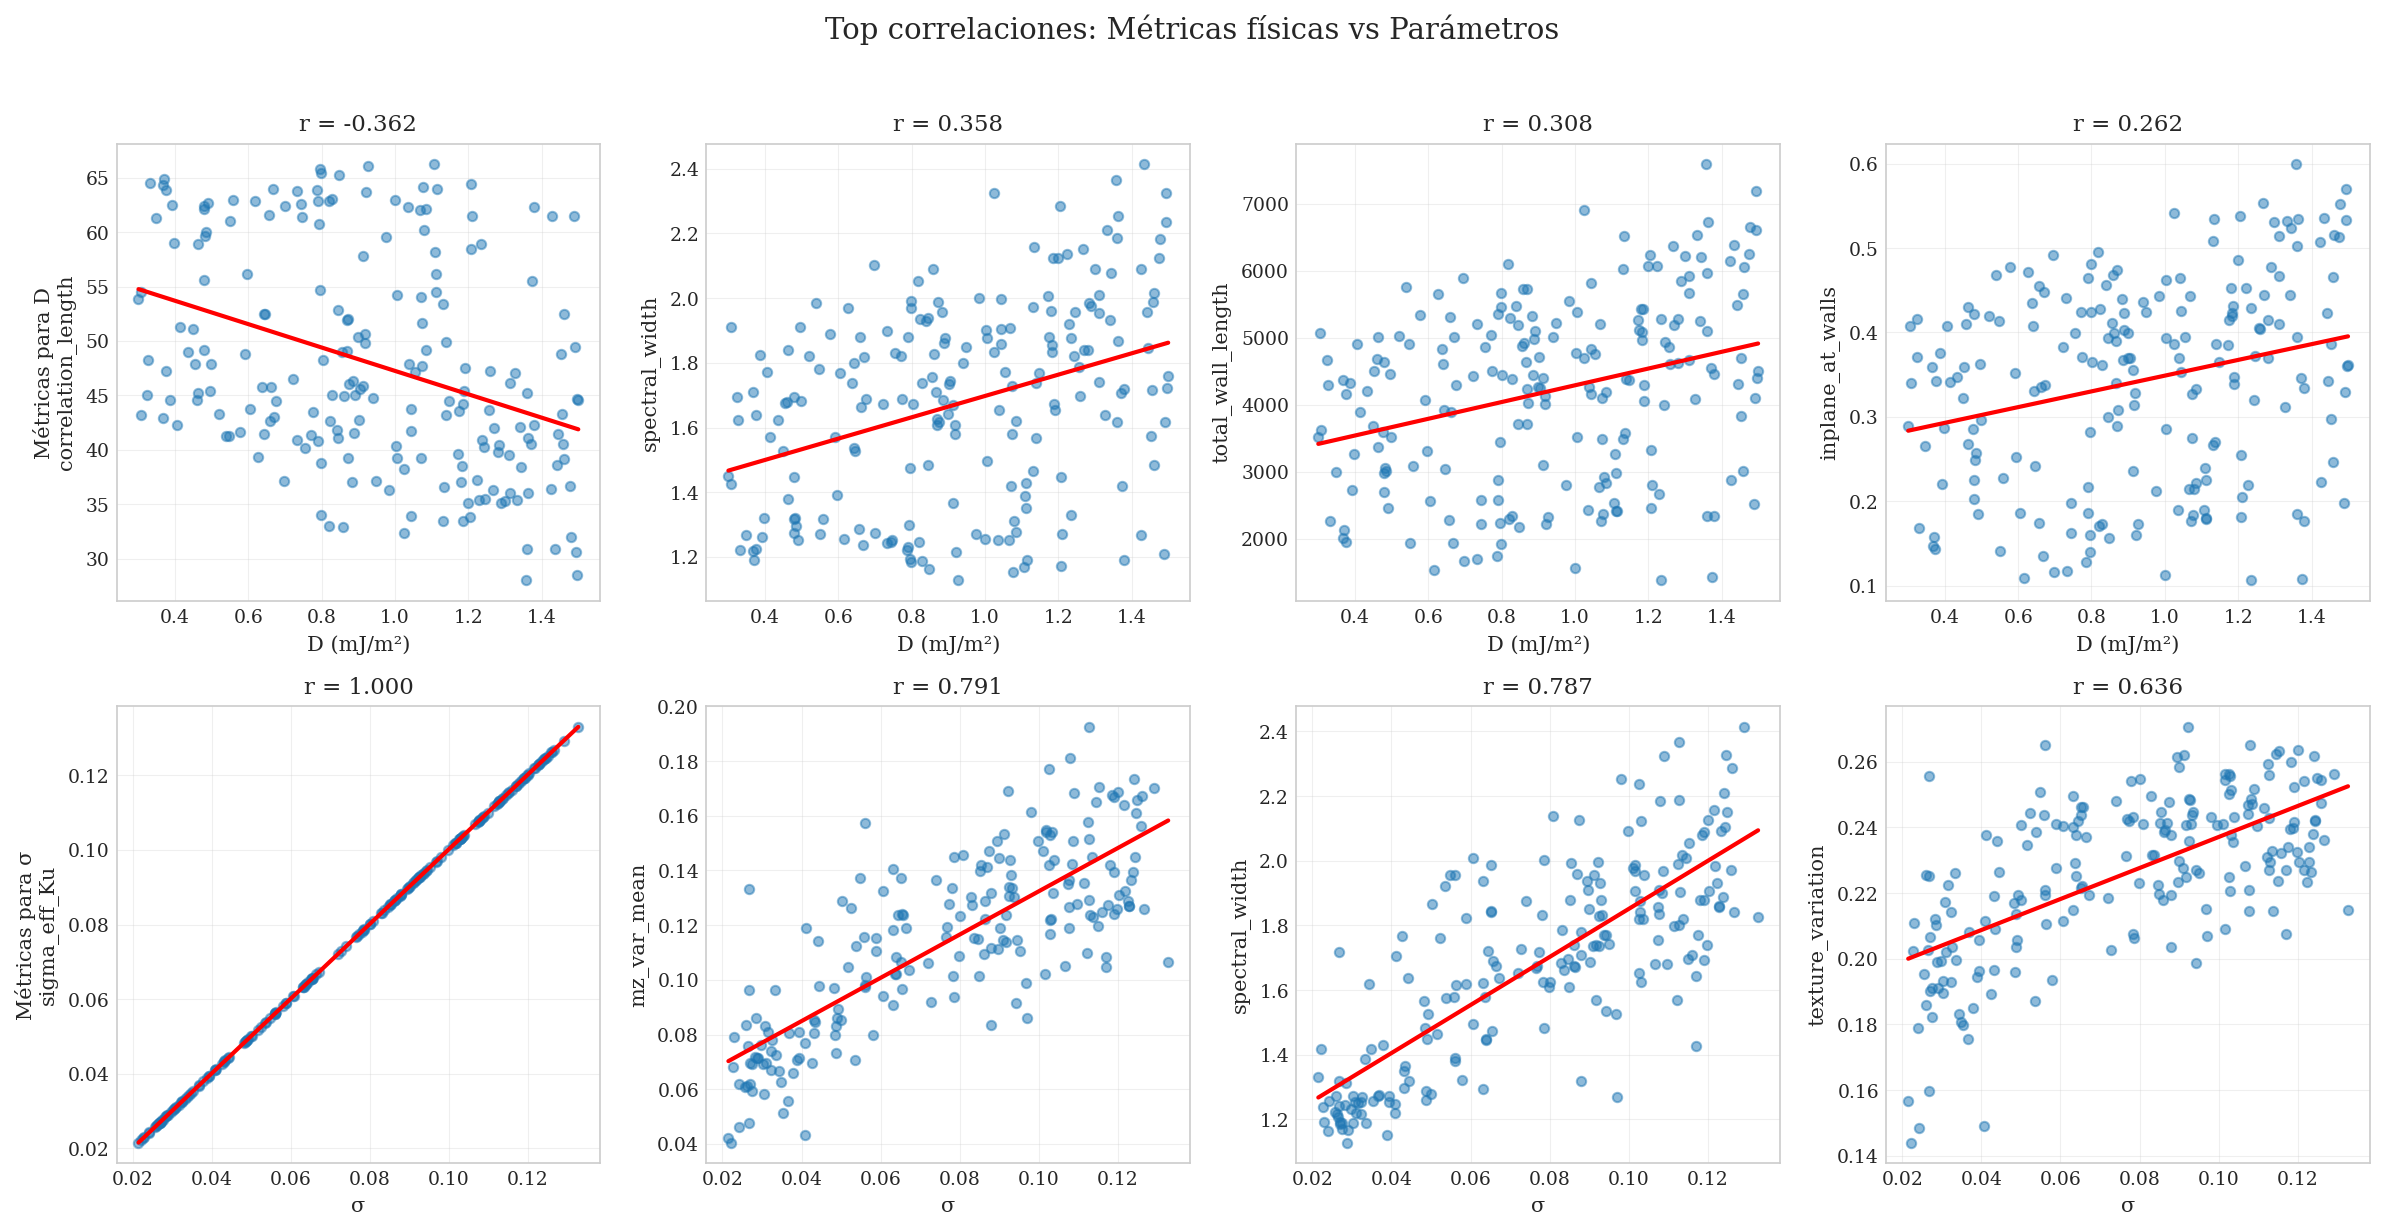

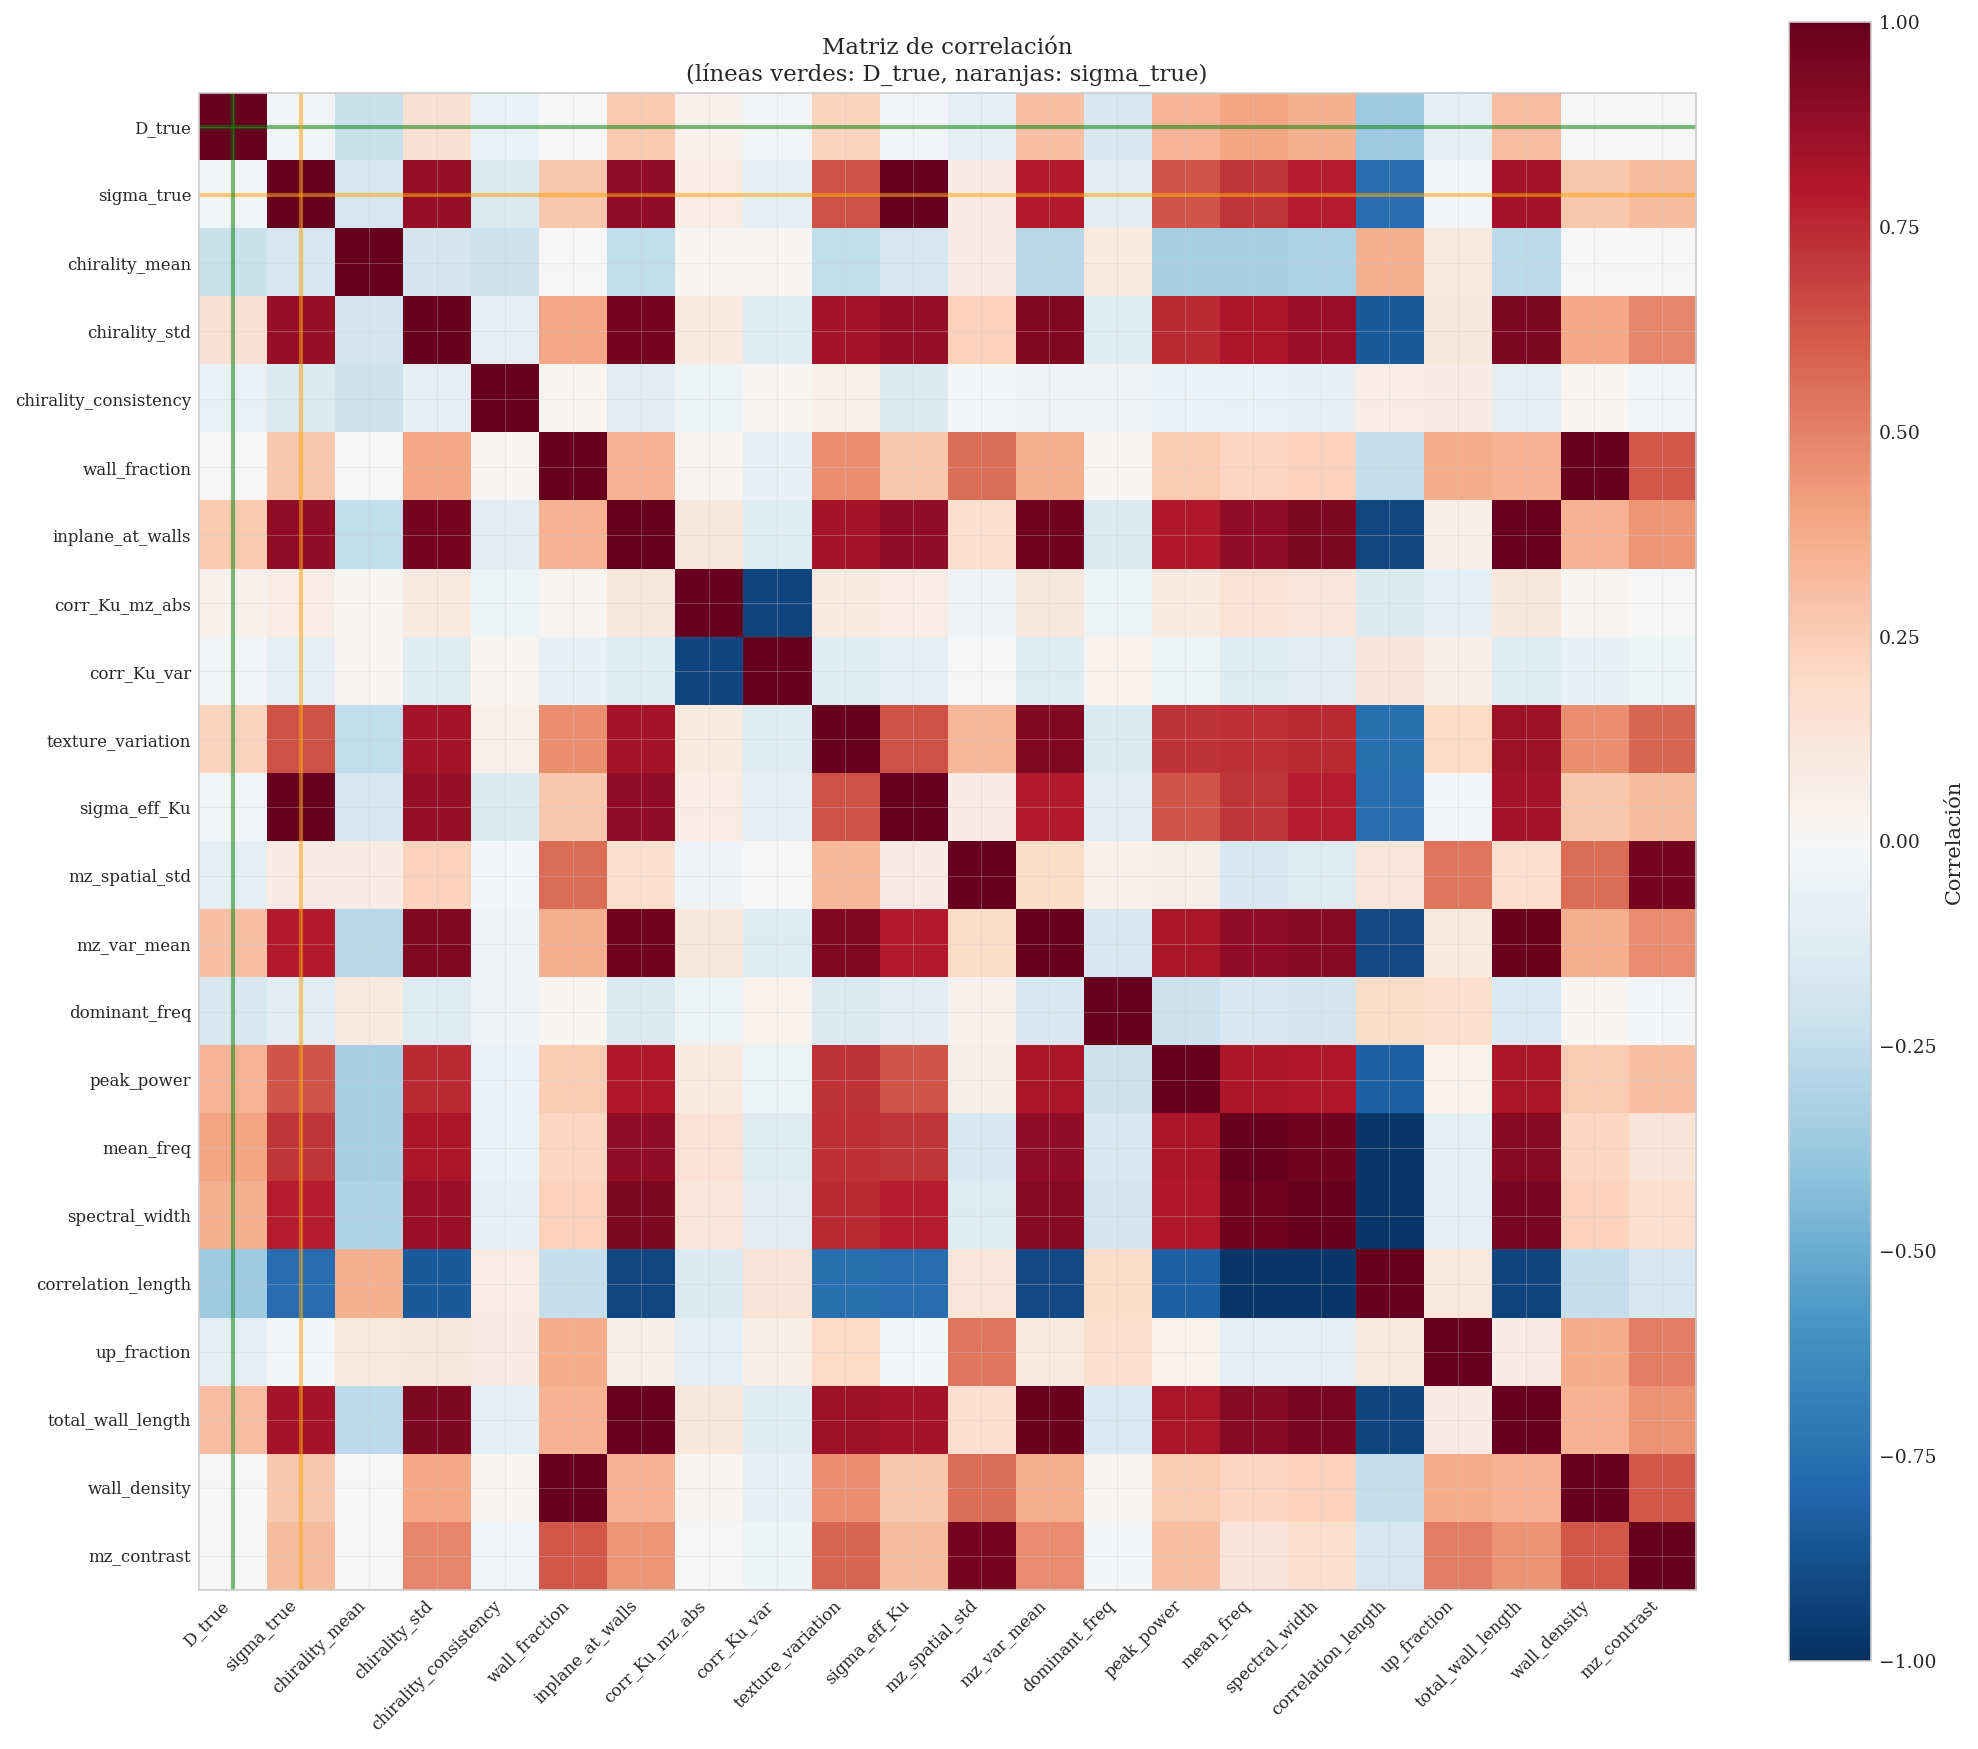


RESUMEN: ¿Qué métricas usar para PINN?

Mejores métricas para D:
  ✓ correlation_length: r = -0.362 
  ✓ spectral_width: r = 0.358 
  ✓ total_wall_length: r = 0.308 

Mejores métricas para σ:
  ✓ sigma_eff_Ku: r = 1.000 ← USAR
  ✓ mz_var_mean: r = 0.791 ← USAR
  ✓ spectral_width: r = 0.787 ← USAR

DECISIÓN GO/NO-GO para PINN
⚠️  PARCIAL: Hay señal moderada
   Considerar PINN híbrido (física + supervisado)

Resultados guardados en 'sanity_test_results.csv'


In [118]:
# ==============================================================================
# SANITY TEST: Verificar correlación de métricas físicas con D y sigma
# Ejecutar ANTES de implementar PINN completo
# ==============================================================================

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

# ==============================================================================
# MÉTRICAS FÍSICAS CANDIDATAS
# ==============================================================================

def compute_chirality_metrics(mx, my, mz, wall_percentile=80):
    """
    Calcula métricas de quiralidad en paredes de dominio.
    
    Para DMI interfacial positivo, la quiralidad debe ser consistente.
    
    Returns:
        dict con métricas de quiralidad
    """
    # Asegurar tensores
    if isinstance(mx, np.ndarray):
        mx, my, mz = torch.from_numpy(mx), torch.from_numpy(my), torch.from_numpy(mz)
    
    # Gradiente de mz (detecta paredes)
    # torch.gradient devuelve [grad_dim0, grad_dim1] = [grad_y, grad_x]
    grad_mz = torch.gradient(mz)
    grad_mz_y, grad_mz_x = grad_mz[0], grad_mz[1]
    grad_mag = torch.sqrt(grad_mz_x**2 + grad_mz_y**2 + 1e-10)
    
    # Máscara de paredes (donde hay gradiente alto)
    threshold = torch.quantile(grad_mag, wall_percentile/100.0)
    wall_mask = grad_mag > threshold
    
    if wall_mask.sum() < 10:
        return {
            'chirality_mean': 0.0,
            'chirality_std': 1.0,
            'chirality_consistency': 0.0,
            'wall_fraction': 0.0,
            'inplane_at_walls': 0.0
        }
    
    # Quiralidad: C = (m × ẑ) · ∇mz / |∇mz|
    # Simplificado: C = (mx * grad_mz_x + my * grad_mz_y) / |∇mz|
    # O la versión con producto cruz: C = mx * grad_mz_y - my * grad_mz_x
    
    # Esta definición mide si m_inplane es paralelo o antiparalelo al gradiente
    C = (mx * grad_mz_x + my * grad_mz_y) / (grad_mag + 1e-10)
    
    C_walls = C[wall_mask]
    
    chirality_mean = C_walls.mean().item()
    chirality_std = C_walls.std().item()
    chirality_consistency = abs(chirality_mean) / (chirality_std + 0.01)
    
    # Magnitud in-plane en paredes (debería ser alta si DMI domina)
    m_inplane = torch.sqrt(mx**2 + my**2)
    inplane_at_walls = m_inplane[wall_mask].mean().item()
    
    wall_fraction = wall_mask.float().mean().item()
    
    return {
        'chirality_mean': chirality_mean,
        'chirality_std': chirality_std,
        'chirality_consistency': chirality_consistency,
        'wall_fraction': wall_fraction,
        'inplane_at_walls': inplane_at_walls
    }


def compute_sigma_metrics(mz, Ku_blocks):
    """
    Calcula métricas relacionadas con dispersión de anisotropía.
    
    La idea: mayor σ → más variación espacial en el comportamiento magnético
    correlacionado con la variación de Ku.
    
    Returns:
        dict con métricas para σ
    """
    if isinstance(mz, np.ndarray):
        mz = torch.from_numpy(mz)
    if isinstance(Ku_blocks, np.ndarray):
        Ku_blocks = torch.from_numpy(Ku_blocks)
    
    # Asegurar dimensiones para pooling
    if mz.dim() == 2:
        mz_4d = mz.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
    else:
        mz_4d = mz
    
    H, W = mz_4d.shape[-2], mz_4d.shape[-1]
    block_size = H // 16  # Debería ser 32 para 512/16
    
    # Promedio de mz por bloque
    mz_blocks = F.avg_pool2d(mz_4d, block_size).squeeze()  # [16, 16]
    
    # Promedio de |mz| por bloque
    mz_abs_blocks = F.avg_pool2d(mz_4d.abs(), block_size).squeeze()
    
    # Varianza local de mz por bloque (textura)
    mz_sq_blocks = F.avg_pool2d(mz_4d**2, block_size).squeeze()
    mz_var_blocks = mz_sq_blocks - mz_blocks**2  # Var = E[X²] - E[X]²
    
    # Aplanar para correlaciones
    Ku_flat = Ku_blocks.flatten().float()
    mz_flat = mz_blocks.flatten()
    mz_abs_flat = mz_abs_blocks.flatten()
    mz_var_flat = mz_var_blocks.flatten()
    
    # Normalizar Ku para correlación
    Ku_norm = (Ku_flat - Ku_flat.mean()) / (Ku_flat.std() + 1e-10)
    
    # Correlación Ku vs |mz| promedio
    # Hipótesis: Ku alto → dominio más estable → |mz| más cercano a 1
    mz_abs_norm = (mz_abs_flat - mz_abs_flat.mean()) / (mz_abs_flat.std() + 1e-10)
    corr_Ku_mz = (Ku_norm * mz_abs_norm).mean().item()
    
    # Correlación Ku vs varianza local
    # Hipótesis: Ku bajo → más inestable → más varianza local
    mz_var_norm = (mz_var_flat - mz_var_flat.mean()) / (mz_var_flat.std() + 1e-10)
    corr_Ku_var = (Ku_norm * mz_var_norm).mean().item()
    
    # Variación de textura entre bloques (std de la varianza por bloque)
    texture_variation = mz_var_blocks.std().item()
    
    # Verificar sigma_eff directamente de Ku
    sigma_eff_Ku = (Ku_blocks.std() / Ku_blocks.mean()).item()
    
    # Heterogeneidad espacial de mz
    mz_spatial_std = mz_blocks.std().item()
    
    return {
        'corr_Ku_mz_abs': corr_Ku_mz,
        'corr_Ku_var': corr_Ku_var,
        'texture_variation': texture_variation,
        'sigma_eff_Ku': sigma_eff_Ku,
        'mz_spatial_std': mz_spatial_std,
        'mz_var_mean': mz_var_blocks.mean().item()
    }


def compute_spectral_metrics(mz):
    """
    Métricas espectrales que pueden relacionarse con D y σ.
    
    Returns:
        dict con métricas espectrales
    """
    if isinstance(mz, np.ndarray):
        mz = torch.from_numpy(mz)
    
    # FFT y power spectrum
    mz_centered = mz - mz.mean()
    fft_mz = torch.fft.fft2(mz_centered)
    power = (fft_mz * fft_mz.conj()).real
    
    # Perfil radial del power spectrum
    H, W = mz.shape
    cy, cx = H // 2, W // 2
    
    # Crear mapa de distancias radiales
    y, x = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    # Shift para centrar
    y = (y - cy).float()
    x = (x - cx).float()
    r = torch.sqrt(x**2 + y**2)
    
    power_shifted = torch.fft.fftshift(power)
    
    # Binear por radio
    r_flat = r.flatten()
    power_flat = power_shifted.flatten()
    
    max_r = int(min(cx, cy))
    radial_power = []
    for ri in range(1, max_r):
        mask = (r_flat >= ri - 0.5) & (r_flat < ri + 0.5)
        if mask.sum() > 0:
            radial_power.append(power_flat[mask].mean().item())
        else:
            radial_power.append(0)
    
    radial_power = np.array(radial_power)
    radii = np.arange(1, max_r)
    
    # Frecuencia dominante (peak del espectro)
    if len(radial_power) > 5:
        peak_idx = np.argmax(radial_power[2:]) + 2  # Ignorar DC y primeros modos
        dominant_freq = radii[peak_idx] if peak_idx < len(radii) else 0
        peak_power = radial_power[peak_idx] if peak_idx < len(radial_power) else 0
    else:
        dominant_freq = 0
        peak_power = 0
    
    # "Ancho" del pico (dispersión espectral)
    total_power = radial_power.sum() + 1e-10
    weights = radial_power / total_power
    mean_freq = (radii * weights).sum()
    spectral_width = np.sqrt(((radii - mean_freq)**2 * weights).sum())
    
    # Longitud de correlación aproximada (inverso de frecuencia característica)
    if mean_freq > 0:
        correlation_length = H / (2 * np.pi * mean_freq)  # En píxeles
    else:
        correlation_length = H
    
    return {
        'dominant_freq': dominant_freq,
        'peak_power': peak_power,
        'mean_freq': mean_freq,
        'spectral_width': spectral_width,
        'correlation_length': correlation_length
    }


def compute_domain_metrics(mz):
    """
    Métricas geométricas de dominios.
    
    Returns:
        dict con métricas de dominios
    """
    if isinstance(mz, np.ndarray):
        mz = torch.from_numpy(mz)
    
    # Fracción up/down
    up_fraction = (mz > 0).float().mean().item()
    
    # "Perímetro" total (suma de gradientes = cantidad de pared)
    grad_mz = torch.gradient(mz)
    grad_mag = torch.sqrt(grad_mz[0]**2 + grad_mz[1]**2)
    total_wall_length = grad_mag.sum().item()
    
    # Densidad de paredes
    wall_density = (grad_mag > grad_mag.quantile(0.8)).float().mean().item()
    
    # Contraste (diferencia entre dominios)
    mz_contrast = mz.std().item()
    
    return {
        'up_fraction': up_fraction,
        'total_wall_length': total_wall_length,
        'wall_density': wall_density,
        'mz_contrast': mz_contrast
    }


# ==============================================================================
# FUNCIÓN PRINCIPAL DE DIAGNÓSTICO
# ==============================================================================

def run_physics_sanity_test(dataset, n_samples=100, seed=42):
    """
    Ejecuta test de sanidad: calcula todas las métricas físicas
    y verifica correlación con D_true y sigma_true.
    
    Args:
        dataset: MzDataset instance
        n_samples: Número de muestras a evaluar
        seed: Semilla para reproducibilidad
    
    Returns:
        DataFrame con resultados, figuras de correlación
    """
    np.random.seed(seed)
    
    n_total = len(dataset)
    indices = np.random.choice(n_total, size=min(n_samples, n_total), replace=False)
    
    results = []
    
    print(f"Analizando {len(indices)} muestras...")
    
    for idx in tqdm(indices):
        img, m_field, Ku_blocks, target, run_id = dataset[idx]
        
        # Obtener valores verdaderos (desnormalizar si es necesario)
        if dataset.target_mean is not None:
            target_denorm = target.numpy() * dataset.target_std + dataset.target_mean
        else:
            target_denorm = target.numpy()
        
        D_true = target_denorm[0]
        sigma_true = target_denorm[1]
        
        # Extraer campos
        mx = m_field['mx']
        my = m_field['my']
        mz = m_field['mz']
        
        # Calcular todas las métricas
        chir_metrics = compute_chirality_metrics(mx, my, mz)
        sigma_metrics = compute_sigma_metrics(mz, Ku_blocks)
        spectral_metrics = compute_spectral_metrics(mz)
        domain_metrics = compute_domain_metrics(mz)
        
        # Compilar resultado
        result = {
            'run_id': run_id,
            'D_true': D_true,
            'sigma_true': sigma_true,
            **chir_metrics,
            **sigma_metrics,
            **spectral_metrics,
            **domain_metrics
        }
        
        results.append(result)
    
    df = pd.DataFrame(results)
    
    return df


def analyze_correlations(df):
    """
    Analiza y visualiza correlaciones entre métricas y targets.
    """
    # Métricas a analizar
    metrics_for_D = [
        'chirality_mean', 'chirality_std', 'chirality_consistency',
        'inplane_at_walls', 'dominant_freq', 'correlation_length',
        'spectral_width', 'total_wall_length'
    ]
    
    metrics_for_sigma = [
        'corr_Ku_mz_abs', 'corr_Ku_var', 'texture_variation',
        'sigma_eff_Ku', 'mz_spatial_std', 'mz_var_mean',
        'wall_density', 'spectral_width'
    ]
    
    # Calcular correlaciones con D
    print("\n" + "="*60)
    print("CORRELACIONES CON D")
    print("="*60)
    
    corr_D = {}
    for metric in metrics_for_D:
        if metric in df.columns:
            r, p = stats.pearsonr(df[metric], df['D_true'])
            corr_D[metric] = {'r': r, 'p': p}
            significance = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            print(f"{metric:25s}: r = {r:+.3f}  (p = {p:.2e}) {significance}")
    
    # Calcular correlaciones con sigma
    print("\n" + "="*60)
    print("CORRELACIONES CON σ")
    print("="*60)
    
    corr_sigma = {}
    for metric in metrics_for_sigma:
        if metric in df.columns:
            r, p = stats.pearsonr(df[metric], df['sigma_true'])
            corr_sigma[metric] = {'r': r, 'p': p}
            significance = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            print(f"{metric:25s}: r = {r:+.3f}  (p = {p:.2e}) {significance}")
    
    return corr_D, corr_sigma


def plot_top_correlations(df, corr_D, corr_sigma, top_n=4):
    """
    Visualiza las mejores correlaciones encontradas.
    """
    # Ordenar por |r|
    sorted_D = sorted(corr_D.items(), key=lambda x: abs(x[1]['r']), reverse=True)[:top_n]
    sorted_sigma = sorted(corr_sigma.items(), key=lambda x: abs(x[1]['r']), reverse=True)[:top_n]
    
    fig, axes = plt.subplots(2, top_n, figsize=(4*top_n, 8))
    
    # Plots para D
    for i, (metric, stats_dict) in enumerate(sorted_D):
        ax = axes[0, i]
        ax.scatter(df['D_true']*1e3, df[metric], alpha=0.5, s=20)
        
        # Línea de regresión
        z = np.polyfit(df['D_true']*1e3, df[metric], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df['D_true'].min()*1e3, df['D_true'].max()*1e3, 100)
        ax.plot(x_line, p(x_line), 'r-', lw=2)
        
        ax.set_xlabel('D (mJ/m²)')
        ax.set_ylabel(metric)
        ax.set_title(f'r = {stats_dict["r"]:.3f}')
        ax.grid(True, alpha=0.3)
    
    # Plots para sigma
    for i, (metric, stats_dict) in enumerate(sorted_sigma):
        ax = axes[1, i]
        ax.scatter(df['sigma_true'], df[metric], alpha=0.5, s=20)
        
        # Línea de regresión
        z = np.polyfit(df['sigma_true'], df[metric], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df['sigma_true'].min(), df['sigma_true'].max(), 100)
        ax.plot(x_line, p(x_line), 'r-', lw=2)
        
        ax.set_xlabel('σ')
        ax.set_ylabel(metric)
        ax.set_title(f'r = {stats_dict["r"]:.3f}')
        ax.grid(True, alpha=0.3)
    
    axes[0, 0].set_ylabel(f'Métricas para D\n{sorted_D[0][0]}', fontsize=10)
    axes[1, 0].set_ylabel(f'Métricas para σ\n{sorted_sigma[0][0]}', fontsize=10)
    
    plt.suptitle('Top correlaciones: Métricas físicas vs Parámetros', fontsize=14, y=1.02)
    plt.tight_layout()
    
    return fig


def plot_correlation_matrix(df):
    """
    Matriz de correlación completa.
    """
    # Seleccionar columnas numéricas relevantes
    exclude_cols = ['run_id']
    numeric_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in ['float64', 'float32', 'int64']]
    
    corr_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(14, 12))
    
    im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(numeric_cols, fontsize=8)
    
    plt.colorbar(im, ax=ax, label='Correlación')
    
    # Resaltar D_true y sigma_true
    d_idx = numeric_cols.index('D_true')
    s_idx = numeric_cols.index('sigma_true')
    
    ax.axhline(d_idx, color='green', lw=2, alpha=0.5)
    ax.axhline(s_idx, color='orange', lw=2, alpha=0.5)
    ax.axvline(d_idx, color='green', lw=2, alpha=0.5)
    ax.axvline(s_idx, color='orange', lw=2, alpha=0.5)
    
    plt.title('Matriz de correlación\n(líneas verdes: D_true, naranjas: sigma_true)')
    plt.tight_layout()
    
    return fig


# ==============================================================================
# EJECUTAR TEST
# ==============================================================================

if __name__ == "__main__" or True:  # Ejecutar siempre en notebook
    
    # Crear dataset (ajustar paths según tu configuración)
    print("Cargando dataset...")
    
    # Ejemplo - ajustar a tus paths:
    # dataset = MzDataset(
    #     csv_path="path/to/labels.csv",
    #     img_dir="path/to/images",
    #     npy_dir="path/to/npy_files",
    #     index_col="run_id",
    #     load_npy=True,
    #     filter_low_D=True,
    #     filter_low_sigma=True
    # )
    
    dataset = MzDataset(
    csv_path=CSV_PATH,
    img_dir=IMG_DIR,
    npy_dir=NPY_DIR,
    index_col=IMG_INDEX_COL,
    transform=None,
    filter_low_D=True,
    filter_low_sigma=True,
    load_npy=True,
    max_samples=None,
    random_subset_seed=123
)
    
    # Asumiendo que ya tienes 'train_dataset' o similar definido:
    # dataset = train_dataset
    
    print("\n" + "="*60)
    print("SANITY TEST: Métricas Físicas para PINN")
    print("="*60)
    
    # Ejecutar análisis
    df_results = run_physics_sanity_test(dataset, n_samples=200)
    
    # Analizar correlaciones
    corr_D, corr_sigma = analyze_correlations(df_results)
    
    # Visualizar
    fig1 = plot_top_correlations(df_results, corr_D, corr_sigma, top_n=4)
    plt.savefig('sanity_test_top_correlations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig2 = plot_correlation_matrix(df_results)
    plt.savefig('sanity_test_correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Resumen ejecutivo
    print("\n" + "="*60)
    print("RESUMEN: ¿Qué métricas usar para PINN?")
    print("="*60)
    
    # Mejores para D
    best_D = sorted(corr_D.items(), key=lambda x: abs(x[1]['r']), reverse=True)[:3]
    print("\nMejores métricas para D:")
    for metric, stats in best_D:
        if abs(stats['r']) > 0.3:
            print(f"  ✓ {metric}: r = {stats['r']:.3f} {'← USAR' if abs(stats['r']) > 0.5 else ''}")
        else:
            print(f"  ✗ {metric}: r = {stats['r']:.3f} (correlación débil)")
    
    # Mejores para sigma
    best_sigma = sorted(corr_sigma.items(), key=lambda x: abs(x[1]['r']), reverse=True)[:3]
    print("\nMejores métricas para σ:")
    for metric, stats in best_sigma:
        if abs(stats['r']) > 0.3:
            print(f"  ✓ {metric}: r = {stats['r']:.3f} {'← USAR' if abs(stats['r']) > 0.5 else ''}")
        else:
            print(f"  ✗ {metric}: r = {stats['r']:.3f} (correlación débil)")
    
    # Recomendación
    print("\n" + "="*60)
    print("DECISIÓN GO/NO-GO para PINN")
    print("="*60)
    
    max_corr_D = max(abs(s['r']) for s in corr_D.values()) if corr_D else 0
    max_corr_sigma = max(abs(s['r']) for s in corr_sigma.values()) if corr_sigma else 0
    
    if max_corr_D > 0.5 and max_corr_sigma > 0.5:
        print("✅ GO: Hay señales físicas fuertes para ambos parámetros")
        print("   Implementar PINN con las métricas indicadas")
    elif max_corr_D > 0.3 or max_corr_sigma > 0.3:
        print("⚠️  PARCIAL: Hay señal moderada")
        print("   Considerar PINN híbrido (física + supervisado)")
    else:
        print("❌ NO-GO: Correlaciones demasiado débiles")
        print("   Las métricas probadas no capturan la física relevante")
        print("   Mantener enfoque CNN supervisado")
    
    # Guardar resultados
    df_results.to_csv('sanity_test_results.csv', index=False)
    print("\nResultados guardados en 'sanity_test_results.csv'")

In [151]:
import pandas as pd
from scipy import stats

# Cargar datos del sanity test
df = pd.read_csv('sanity_test_results.csv')

# Estadísticas
print("σ_true stats:")
print(f"  mean = {df['sigma_true'].mean():.4f}")
print(f"  std  = {df['sigma_true'].std():.4f}")
print(f"  range = [{df['sigma_true'].min():.3f}, {df['sigma_true'].max():.3f}]")

print("\nmz_var_mean stats:")
print(f"  mean = {df['mz_var_mean'].mean():.4f}")
print(f"  std  = {df['mz_var_mean'].std():.4f}")
print(f"  range = [{df['mz_var_mean'].min():.3f}, {df['mz_var_mean'].max():.3f}]")

# Regresión correcta
slope, intercept, r, p, se = stats.linregress(df['sigma_true'], df['mz_var_mean'])

print(f"\n--- Regresión: mz_var_mean = intercept + slope × σ ---")
print(f"slope     = {slope:.6f}")
print(f"intercept = {intercept:.6f}")
print(f"r         = {r:.6f}")
print(f"R²        = {r**2:.6f}")

# Verificar
print(f"\n--- Check: slope = r × (std_mz / std_σ) ---")
ratio = df['mz_var_mean'].std() / df['sigma_true'].std()
print(f"std ratio = {ratio:.4f}")
print(f"r × ratio = {r * ratio:.6f}  (debería ≈ slope)")

σ_true stats:
  mean = 0.0764
  std  = 0.0329
  range = [0.021, 0.133]

mz_var_mean stats:
  mean = 0.1137
  std  = 0.0329
  range = [0.040, 0.193]

--- Regresión: mz_var_mean = intercept + slope × σ ---
slope     = 0.791200
intercept = 0.053256
r         = 0.791088
R²        = 0.625820

--- Check: slope = r × (std_mz / std_σ) ---
std ratio = 1.0001
r × ratio = 0.791200  (debería ≈ slope)


TEST PINN CON CAMPOS DE MUMAX

Cargando campos...
  m: m000000.ovf, shape (512, 512)
  |m| promedio: 1.000000
  B_eff:   loaded
  B_exch:  loaded
  B_anis:  loaded
  B_demag: loaded
  B_dmi:   calculated (B_eff - others)

  |H_exch| mean:  6.644e+03 A/m
  |H_anis| mean:  1.826e+06 A/m
  |H_demag| mean: 1.417e+06 A/m
  |H_dmi| mean:   1.781e-02 A/m

  Torque MuMax |τ| mean: 8.089e-08 T
  Torque MuMax |τ| max:  2.814e-05 T

VERIFICACIÓN CON D_true

  D_true = 1.200 mJ/m²
  Residual (H_base + H_dmi):  1.266115e+00
  Residual (H_eff directo):   1.266094e+00
  ✓ B_dmi calculado correctamente

SCAN DE D

  D_true = 1.200 mJ/m²
  D_best = 0.300 mJ/m²
  Error  = 75.0%


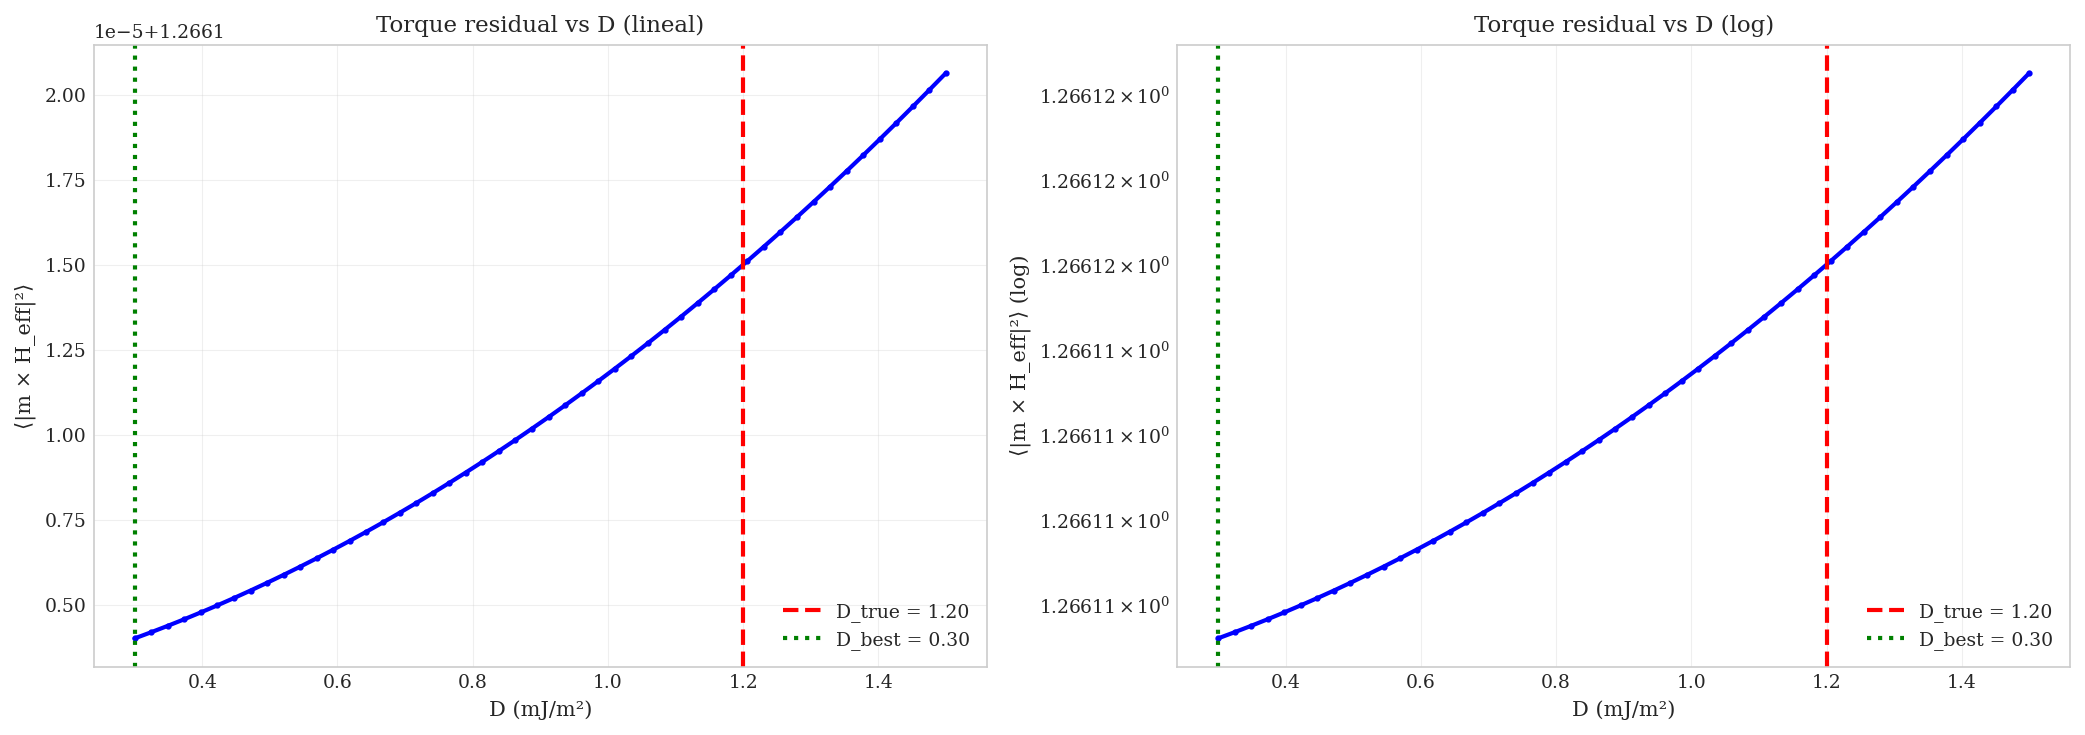


❌ PINN NO VIABLE
   Error = 75.0%


(array([0.0003    , 0.00032449, 0.00034898, 0.00037347, 0.00039796,
        0.00042245, 0.00044694, 0.00047143, 0.00049592, 0.00052041,
        0.0005449 , 0.00056939, 0.00059388, 0.00061837, 0.00064286,
        0.00066735, 0.00069184, 0.00071633, 0.00074082, 0.00076531,
        0.0007898 , 0.00081429, 0.00083878, 0.00086327, 0.00088776,
        0.00091224, 0.00093673, 0.00096122, 0.00098571, 0.0010102 ,
        0.00103469, 0.00105918, 0.00108367, 0.00110816, 0.00113265,
        0.00115714, 0.00118163, 0.00120612, 0.00123061, 0.0012551 ,
        0.00127959, 0.00130408, 0.00132857, 0.00135306, 0.00137755,
        0.00140204, 0.00142653, 0.00145102, 0.00147551, 0.0015    ]),
 array([1.26610403, 1.26610421, 1.2661044 , 1.26610459, 1.26610479,
        1.266105  , 1.26610522, 1.26610544, 1.26610566, 1.2661059 ,
        1.26610614, 1.26610639, 1.26610664, 1.2661069 , 1.26610717,
        1.26610744, 1.26610772, 1.26610801, 1.2661083 , 1.2661086 ,
        1.2661089 , 1.26610922, 1.26610954, 1.

In [121]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import struct

def load_ovf(path):
    """
    Cargar archivo OVF de MuMax3 (Binary 4).
    """
    path = Path(path)
    
    with open(path, 'rb') as f:
        header = {}
        
        while True:
            line = f.readline().decode('latin-1').strip()
            
            if line.startswith('# Begin: Data Binary 4'):
                break
            elif line.startswith('# Begin: Data Binary 8'):
                raise NotImplementedError("Binary 8 not implemented")
            elif line.startswith('# Begin: Data Text'):
                raise NotImplementedError("Text format not implemented")
            
            if ':' in line and line.startswith('#'):
                parts = line[2:].split(':', 1)
                if len(parts) == 2:
                    key = parts[0].strip()
                    val = parts[1].strip()
                    header[key] = val
        
        nx = int(header.get('xnodes', 0))
        ny = int(header.get('ynodes', 0))
        nz = int(header.get('znodes', 0))
        ncomp = int(header.get('valuedim', 3))
        
        # Check value
        check_bytes = f.read(4)
        check_value = struct.unpack('<f', check_bytes)[0]
        
        # Datos
        data_size = ncomp * nz * ny * nx
        data = np.frombuffer(f.read(4 * data_size), dtype='<f4')
        data = data.reshape((nz, ny, nx, ncomp))
        data = np.moveaxis(data, -1, 0)  # (ncomp, nz, ny, nx)
        
    return data, header


def test_pinn_with_mumax_fields(run_dir, D_true_Jm2):
    """
    Test PINN: usar campos de MuMax y verificar si R(D) tiene mínimo en D_true.
    B_dmi se calcula como B_eff - B_exch - B_anis - B_demag.
    """
    run_dir = Path(run_dir)
    mu0 = 4 * np.pi * 1e-7
    
    print("="*60)
    print("TEST PINN CON CAMPOS DE MUMAX")
    print("="*60)
    
    # === Buscar archivos OVF ===
    def find_ovf(pattern):
        matches = list(run_dir.glob(f"{pattern}*.ovf"))
        if matches:
            return matches[0]
        raise FileNotFoundError(f"No se encontró {pattern}*.ovf en {run_dir}")
    
    # === Cargar magnetización ===
    print("\nCargando campos...")
    m_path = find_ovf("m")
    m, _ = load_ovf(m_path)
    mx = m[0, 0, :, :]
    my = m[1, 0, :, :]
    mz = m[2, 0, :, :]
    print(f"  m: {m_path.name}, shape {mx.shape}")
    print(f"  |m| promedio: {np.sqrt(mx**2 + my**2 + mz**2).mean():.6f}")
    
    # === Cargar campos (en Tesla) ===
    B_eff, _ = load_ovf(find_ovf("B_eff"))
    B_exch, _ = load_ovf(find_ovf("B_exch"))
    B_anis, _ = load_ovf(find_ovf("B_anis"))
    B_demag, _ = load_ovf(find_ovf("B_demag"))
    
    print(f"  B_eff:   loaded")
    print(f"  B_exch:  loaded")
    print(f"  B_anis:  loaded")
    print(f"  B_demag: loaded")
    
    # === Calcular B_dmi por diferencia ===
    B_dmi = B_eff - B_exch - B_anis - B_demag
    print(f"  B_dmi:   calculated (B_eff - others)")
    
    # Convertir a H (A/m)
    H_exch = B_exch[:, 0, :, :] / mu0
    H_anis = B_anis[:, 0, :, :] / mu0
    H_demag = B_demag[:, 0, :, :] / mu0
    H_dmi_true = B_dmi[:, 0, :, :] / mu0
    H_eff_true = B_eff[:, 0, :, :] / mu0
    
    # Magnitudes
    print(f"\n  |H_exch| mean:  {np.sqrt((H_exch**2).sum(axis=0)).mean():.3e} A/m")
    print(f"  |H_anis| mean:  {np.sqrt((H_anis**2).sum(axis=0)).mean():.3e} A/m")
    print(f"  |H_demag| mean: {np.sqrt((H_demag**2).sum(axis=0)).mean():.3e} A/m")
    print(f"  |H_dmi| mean:   {np.sqrt((H_dmi_true**2).sum(axis=0)).mean():.3e} A/m")
    
    # === Cargar torque ===
    try:
        torque, _ = load_ovf(find_ovf("torque"))
        torque_mag = np.sqrt((torque[:, 0, :, :]**2).sum(axis=0))
        print(f"\n  Torque MuMax |τ| mean: {torque_mag.mean():.3e} T")
        print(f"  Torque MuMax |τ| max:  {torque_mag.max():.3e} T")
    except FileNotFoundError:
        print("\n  (torque.ovf no encontrado)")
    
    # === H_base (sin DMI) ===
    H_base = H_exch + H_anis + H_demag
    
    # === Función de torque ===
    def compute_torque_residual(H_eff):
        tau_x = my * H_eff[2] - mz * H_eff[1]
        tau_y = mz * H_eff[0] - mx * H_eff[2]
        tau_z = mx * H_eff[1] - my * H_eff[0]
        return (tau_x**2 + tau_y**2 + tau_z**2).mean()
    
    # === Verificación con D_true ===
    print("\n" + "="*60)
    print("VERIFICACIÓN CON D_true")
    print("="*60)
    
    H_eff_check = H_base + H_dmi_true
    R_true = compute_torque_residual(H_eff_check)
    
    # También verificar usando H_eff directo de MuMax
    R_true_direct = compute_torque_residual(H_eff_true)
    
    print(f"\n  D_true = {D_true_Jm2*1e3:.3f} mJ/m²")
    print(f"  Residual (H_base + H_dmi):  {R_true:.6e}")
    print(f"  Residual (H_eff directo):   {R_true_direct:.6e}")
    
    # Verificar que son iguales (validación de B_dmi calculado)
    if abs(R_true - R_true_direct) / (R_true_direct + 1e-20) < 0.01:
        print("  ✓ B_dmi calculado correctamente")
    else:
        print("  ⚠ Diferencia en B_dmi - verificar cálculo")
    
    # === Scan sobre D ===
    print("\n" + "="*60)
    print("SCAN DE D")
    print("="*60)
    
    D_range = np.linspace(0.3e-3, 1.5e-3, 50)
    residuals = []
    
    for D in D_range:
        scale = D / D_true_Jm2
        H_dmi_scaled = H_dmi_true * scale
        H_eff = H_base + H_dmi_scaled
        R = compute_torque_residual(H_eff)
        residuals.append(R)
    
    residuals = np.array(residuals)
    
    idx_min = np.argmin(residuals)
    D_best = D_range[idx_min]
    
    print(f"\n  D_true = {D_true_Jm2*1e3:.3f} mJ/m²")
    print(f"  D_best = {D_best*1e3:.3f} mJ/m²")
    print(f"  Error  = {abs(D_best - D_true_Jm2)/D_true_Jm2 * 100:.1f}%")
    
    # === Plots ===
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    ax.plot(D_range * 1e3, residuals, 'b.-', lw=2, markersize=4)
    ax.axvline(D_true_Jm2 * 1e3, color='r', ls='--', lw=2, label=f'D_true = {D_true_Jm2*1e3:.2f}')
    ax.axvline(D_best * 1e3, color='g', ls=':', lw=2, label=f'D_best = {D_best*1e3:.2f}')
    ax.set_xlabel('D (mJ/m²)')
    ax.set_ylabel('⟨|m × H_eff|²⟩')
    ax.set_title('Torque residual vs D (lineal)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.semilogy(D_range * 1e3, residuals, 'b.-', lw=2, markersize=4)
    ax.axvline(D_true_Jm2 * 1e3, color='r', ls='--', lw=2, label=f'D_true = {D_true_Jm2*1e3:.2f}')
    ax.axvline(D_best * 1e3, color='g', ls=':', lw=2, label=f'D_best = {D_best*1e3:.2f}')
    ax.set_xlabel('D (mJ/m²)')
    ax.set_ylabel('⟨|m × H_eff|²⟩ (log)')
    ax.set_title('Torque residual vs D (log)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('pinn_test_mumax_fields.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # === Conclusión ===
    print("\n" + "="*60)
    error_pct = abs(D_best - D_true_Jm2)/D_true_Jm2 * 100
    
    if error_pct < 5:
        print("✅ PINN VIABLE")
        print(f"   Error = {error_pct:.1f}%")
        print("   → Proceder a implementar H_eff diferenciable")
    elif error_pct < 20:
        print("⚠️  PINN PARCIALMENTE VIABLE")
        print(f"   Error = {error_pct:.1f}%")
    else:
        print("❌ PINN NO VIABLE")
        print(f"   Error = {error_pct:.1f}%")
    print("="*60)
    
    return D_range, residuals, D_best


# === EJECUTAR ===
RUN_DIR = "../mumax_files/demo.out"  # ← Cambiar
D_TRUE = 1.2e-3  # J/m² (Dind = 0.0012 en tu script)

test_pinn_with_mumax_fields(RUN_DIR, D_TRUE)